In [26]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import pickle
import glob 
import timeit
from itertools import product
import matplotlib.colors as mcolors
import matplotlib.cm as cm

plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.size'] = 10
cmap_models = cm.get_cmap('Set2')  # Replace 'viridis' with your desired colormap

import warnings
warnings.filterwarnings("ignore")

# Use BADS
import concurrent.futures
from pybads import BADS

import json
import pandas
from collections import Counter

from scipy.stats import binomtest, ttest_rel

data_path = os.path.join("data")
fits_path = os.path.join("modelfits")
figpath = os.path.join("fig")

import sys
print(sys.version)

alpha_val = 0.3
n_folds = 5

3.9.5 (tags/v3.9.5:0a7dcbd, May  3 2021, 17:27:52) [MSC v.1928 64 bit (AMD64)]


# Figure 1

In [27]:
nu = 0.1
beta = 5
logistic_growth = lambda t, theta: theta[:,0] + theta[:,1]/(1+np.exp(-theta[:,2]*(3*t-theta[:,3])))

def log_normpdf(x, mean, std):
    log_normpdf_unnorm = -np.log(std)-0.5*np.log(2*np.pi)-0.5*((x-mean)/std)**2
    return log_normpdf_unnorm

def traj_r_T_estimation(rs_traj, t_now=10, T_end=20, dt=1, thetas_support=None, nu=nu, thetas_traj=None, is_plot=False):
    '''Assume that ts is a vector from t=0 to t=t_now, with spacing of 1 unit. 
       Hence, the length of rs_traj should be at least t_now.
       Also, T_end must be larger than t_now.
    '''
    if(t_now<0): # Prior; no evidence r observed so far.
        ts_train = []
    else:
        ts_train = np.arange(0,t_now,dt)[:,None]
    (num_thetas, thetas_dim) = thetas_support.shape
    
    
    # Grid of integration. Needs to be more finer. 
    r_T_grid = np.linspace(-3,5,400)
    
    # 1) Find p(theta|r) as a function of theta.
    log_p_thetaj_given_rj = np.zeros((num_thetas))
    for theta_val_idx in range(num_thetas):
            # Current theta value
            theta_val = thetas_support[theta_val_idx][None,:]
            # Instantiate the flat prior p(theta). 
            log_p_thetaj_given_rj[theta_val_idx] = -np.log(num_thetas)
            for t0_idx in range(len(ts_train)):
                t0 = ts_train[t0_idx]
                r_t0_traj = rs_traj[t0_idx]
                rho_t_given_thetaj = logistic_growth(t0, theta_val)
                log_p_thetaj_given_rj[theta_val_idx] += log_normpdf(rho_t_given_thetaj, r_t0_traj, nu)
    log_p_thetaj_given_rj_normalized =  log_p_thetaj_given_rj - scipy.special.logsumexp(log_p_thetaj_given_rj)    

    # 2) Find p(r_T | rho(T; theta))
    log_r_T_given_thetaj = np.zeros((len(r_T_grid), num_thetas))
    for theta_val_idx in range(num_thetas):
        # Current theta value
        theta_val = thetas_support[theta_val_idx][None,:]
        rho_T_given_thetaj = logistic_growth(T_end, theta_val)
        log_r_T_given_thetaj[:, theta_val_idx] = log_normpdf(r_T_grid, rho_T_given_thetaj, nu)

    # 3) Find p(r_T | r)
    log_p_r_T_and_theta_given_r = log_r_T_given_thetaj + log_p_thetaj_given_rj_normalized[None,:]
    p_r_T_given_r = np.sum(np.exp(log_p_r_T_and_theta_given_r), axis=-1) # Integrate over possible theta values
    p_r_T_given_r = p_r_T_given_r/np.trapz(p_r_T_given_r, x=r_T_grid)
    post_mean = np.trapz(r_T_grid*p_r_T_given_r, x=r_T_grid)
    post_mode = r_T_grid[np.argmax(p_r_T_given_r)]  
    
    
    # Sanity check:
    if(is_plot):
        print("Posterior mean for r_T: ",  post_mean)
        print("Posterior mode for r_T: ",  post_mode)
        
        sorted_array = -np.sort(-log_p_thetaj_given_rj_normalized.reshape(-1))
        print("theta_true:", thetas_traj)
        
        fig, ax = plt.subplots(1,2,figsize=(8,4))
        ax[0].plot(ts, logistic_growth(ts, thetas_traj[None,:]), "k-", label="true traj")
        ax[0].plot(np.squeeze(ts[ts_train]), np.squeeze(rs_traj[ts_train]), "r.", label="training data")
        theta_postmean = np.sum(np.exp(log_p_thetaj_given_rj_normalized)[:,None]*thetas_support, axis=0)[None,:]
        ax[0].plot(ts, logistic_growth(np.squeeze(ts), theta_postmean), "C0--", label="rho(t; E[theta|r])")
        for traj_idx in range(1):
            theta_map_idx = np.where(log_p_thetaj_given_rj_normalized == sorted_array[traj_idx])
            theta_map = thetas_support[theta_map_idx]
            print("theta_map: ",np.squeeze(theta_map))
            ax[0].plot(ts, logistic_growth(np.squeeze(ts), theta_map), "C1--", label="rho(t; Mode[theta|r])")
        ax[0].plot(ts, trajs, "k-", alpha=0.1)
        ax[0].set_ylim([0,1])
        ax[0].set_ylabel("Performance")
        ax[0].set_xlabel("Time")
        ax[0].legend()
        
        ax[1].plot(p_r_T_given_r, r_T_grid, "k-", label="p(r_T | r)")
        ax[1].plot([0,5],[rs_traj[T_end], rs_traj[T_end]], "k--", label="true r_T")
        ax[1].plot([0,5],[post_mean, post_mean], "C0--", label="E[r_T|r]")
        ax[1].plot([0,5],[post_mode, post_mode], "C1--", label="Mode[r_T|r]")
        ax[1].set_ylabel("r_T")
        ax[1].set_xlabel("p(r_T | r)")
        ax[1].set_ylim([0,1])
        ax[1].legend()
        
        plt.suptitle("theta_true="+str(np.round(thetas_traj,2))+", t_now="+str(t_now)+", T_end="+str(T_end))
        plt.tight_layout()
    
    if(is_plot):
        return post_mean, post_mode, fig
    else:
        return post_mean, post_mode


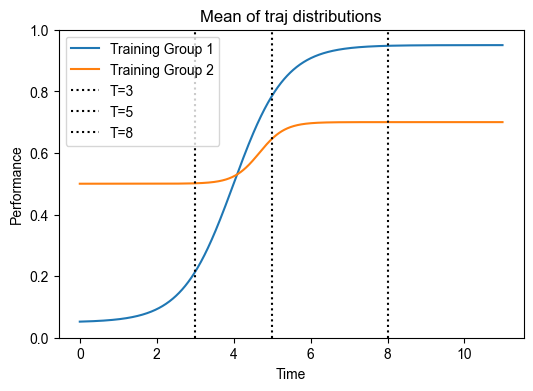

2

In [28]:
# Figure 2: Models

dt=0.01
ts = np.arange(0,11,dt)[:,None]

# 1) The means of trajs
theta0 = np.array([[0.05,0.9,0.5,12]]) # theta[2]=0.8
theta1 = np.array([[0.5,0.2,1,14]])
theta_sigmas = np.array([0.03,0.03,0.03,0.03])
T_ends = np.array([3,5,8])

fig, ax = plt.subplots(1,1, figsize=(6,4))
plt.plot(ts,logistic_growth(ts, theta0),"C0-", label="Training Group 1")
plt.plot(ts,logistic_growth(ts, theta1),"C1-", label="Training Group 2")
for T_end in T_ends:
    plt.plot([T_end,T_end], [0,1.4], "k:", label="T="+str(T_end))
ax.set_xlabel("Time")
ax.set_ylabel("Performance")
ax.set_ylim([0,1])
ax.set_title("Mean of traj distributions")
plt.legend()
plt.show()






# 2) Actual data
num_thetas = 500
theta_dims = theta0.shape[1]
np.random.seed(1)
thetas_0 = np.random.normal(loc=theta0, scale=theta_sigmas, size=(num_thetas,theta_dims))
thetas_1 = np.random.normal(loc=theta1, scale=theta_sigmas, size=(num_thetas,theta_dims))

# This is technically not the same as the likelihood after observing the asset grow for t=2. 
# However, Figure 2 just serves for illustrative purposes.
thetas_1_certain = np.random.normal(loc=theta1, scale=[0,0.03,0.03,0.03], size=(num_thetas,theta_dims))
trajs_0 = logistic_growth(ts, thetas_0)
trajs_1 = logistic_growth(ts, thetas_1)
trajs_1_certain = logistic_growth(ts, thetas_1_certain)


agent_names = ["Velocity", "Exploitation"]
Thetas = {"Velocity": thetas_0, "Exploitation": thetas_1}
Trajs = {"Velocity": trajs_0, "Exploitation": trajs_1}
len(Trajs)

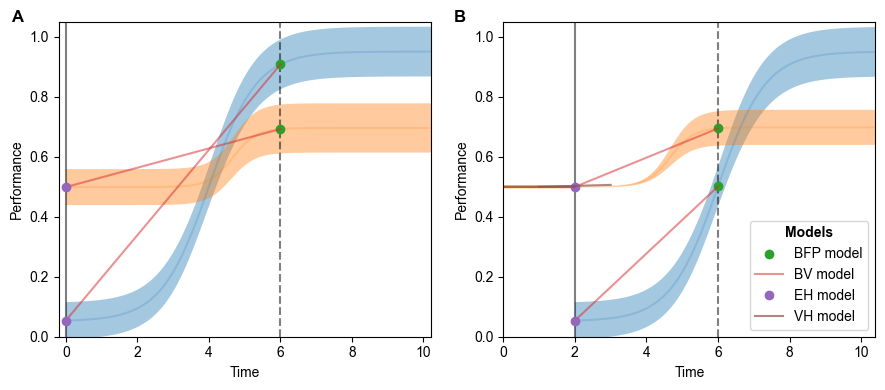

In [29]:
traj_means = np.zeros((len(agent_names), len(ts)))
traj_stds = np.zeros((len(agent_names), len(ts)))
for agent_name_idx in range(len(agent_names)):
    agent_name = agent_names[agent_name_idx]
    traj_means[agent_name_idx,:] = np.mean(Trajs[agent_name], axis=1)
    traj_stds[agent_name_idx,:] = np.std(Trajs[agent_name], axis=1, ddof=1)
    
    
T_end = 6
fig, ax = plt.subplots(1,2,figsize = (9,4))
fig.subplots_adjust(wspace=1)
y_upper = traj_means - 2*traj_stds
y_lower = traj_means + 2*traj_stds
alpha=0.2
markersize = 12

# 1) Asset selection
for agent_name_idx in range(len(agent_names)):
    ax[0].plot(np.squeeze(ts), traj_means[agent_name_idx,:], "-", color="C"+str(agent_name_idx), alpha=alpha)
    # Create the plot
    ax[0].fill_between(np.squeeze(ts), y_lower[agent_name_idx,:], y_upper[agent_name_idx,:], color="C"+str(agent_name_idx), edgecolor="none", alpha=alpha+0.2)
ax[0].plot([0,0],[0,2],"k-", alpha=0.5)
ax[0].plot([T_end,T_end],[0,2],"k--", alpha=0.5)
# Models
ax[0].plot([T_end,T_end],[traj_means[0,int(T_end/dt)],traj_means[1,int(T_end/dt)]], ".", markersize=markersize, color="C2", label="Bayesian final height")
ax[0].plot([0,T_end],[traj_means[0,0],traj_means[0,int(T_end/dt)]], "-", markersize=markersize-8, color="C3", alpha=alpha+0.3, label="Bayesian velocity")
ax[0].plot([0,T_end],[traj_means[1,0],traj_means[1,int(T_end/dt)]], "-", markersize=markersize-8, color="C3", alpha=alpha+0.3)
ax[0].plot([0,0],[traj_means[0,0],traj_means[1,0]], ".", markersize=markersize, color="C4", label="Exploitation heuristic")
ax[0].set_xlim([-0.2,10.2])
ax[0].set_ylim([0,1.05])
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Performance")
#ax[0].legend(title="Models")

# 2) Asset switching
t_now = 2
start_agent_idx=1
traj_means = np.zeros((len(agent_names), len(ts)))
traj_stds = np.zeros((len(agent_names), len(ts)))
traj_means[0,:] = np.mean(Trajs[agent_names[0]], axis=1)
traj_stds[0,:] = np.std(Trajs[agent_names[0]], axis=1, ddof=1)
traj_means[1,:] = np.mean(trajs_1_certain, axis=1)
traj_stds[1,:] = np.std(trajs_1_certain, axis=1, ddof=1)
y_upper = traj_means - 2*traj_stds
y_lower = traj_means + 2*traj_stds

for agent_name_idx in range(len(agent_names)):
    ax[1].plot(np.squeeze(ts)+(t_now * (start_agent_idx!=agent_name_idx)), traj_means[agent_name_idx,:], "-", color="C"+str(agent_name_idx), alpha=alpha)
    # Create the plot
    ax[1].fill_between(np.squeeze(ts)+(t_now * (start_agent_idx!=agent_name_idx)), y_lower[agent_name_idx,:], y_upper[agent_name_idx,:], color="C"+str(agent_name_idx), edgecolor="none", alpha=alpha+0.2)
ax[1].plot(np.squeeze(ts[0:int(t_now/dt)]), traj_means[start_agent_idx,0:int(t_now/dt)], "-", linewidth = 2, color="C"+str(agent_name_idx), alpha=1)
# for timestep in range(t_now+1):
#     ax[1].plot(timestep, traj_means[start_agent_idx,int(timestep/dt)], "o", markersize=8, color="C"+str(agent_name_idx), alpha=1)
ax[1].plot([t_now,t_now],[0,2],"k-", alpha=0.5)
ax[1].plot([T_end,T_end],[0,2],"k--", alpha=0.5)
# Models
ax[1].plot([T_end,T_end],[traj_means[0,int(T_end/dt)-int(t_now/dt)*(0!=agent_name_idx)],traj_means[1,int(T_end/dt)-int(t_now/dt)*(1!=agent_name_idx)]], ".", markersize=markersize, color="C2", label="BFP model")
ax[1].plot([t_now,T_end],[traj_means[0,int(t_now/dt)-int(t_now/dt)*(0!=agent_name_idx)],traj_means[0,int(T_end/dt)-int(t_now/dt)*(0!=agent_name_idx)]], "-", markersize=markersize-8, color="C3", alpha=alpha+0.3, label="BV model")
ax[1].plot([t_now,T_end],[traj_means[1,int(t_now/dt)-int(t_now/dt)*(0!=agent_name_idx)],traj_means[1,int(T_end/dt)-int(t_now/dt)*(1!=agent_name_idx)]], "-", markersize=markersize-8, color="C3", alpha=alpha+0.3)
ax[1].plot([t_now,t_now],[traj_means[0,int(t_now/dt)-int(t_now/dt)*(0!=agent_name_idx)],traj_means[1,int(t_now/dt)-int(t_now/dt)*(1!=agent_name_idx)]], ".", markersize=markersize, color="C4", label="EH model")

current_velocity = (traj_means[start_agent_idx,int(t_now/dt)] - traj_means[start_agent_idx,int((t_now-1)/dt)])/dt
ax[1].plot([0,t_now],[traj_means[start_agent_idx,0],traj_means[start_agent_idx,int(t_now/dt)]], "-", markersize=markersize, alpha=alpha+0.5, color="C5", label="VH model")
ax[1].plot([t_now-1,t_now+1],[traj_means[start_agent_idx,int(t_now/dt)]-current_velocity,traj_means[start_agent_idx,int(t_now/dt)]]+current_velocity, "-", markersize=markersize, alpha=alpha+0.5, color="C5")
ax[1].set_xlim([0,10.4])
ax[1].set_ylim([0,1.05])
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Performance")

# # Get handles and labels from one of the axes
# handles, labels = ax[1].get_legend_handles_labels()

# # Create a common legend for the figure
# fig.legend(handles, labels, title="Models", loc='upper center')
ax[1].legend(title="Models",title_fontproperties={'weight': 'bold'}, frameon=True)
ax[0].text(-1.5,1.05, "A", fontsize=12, weight="bold")
ax[1].text(-1.4,1.05, "B", fontsize=12, weight="bold")
fig.tight_layout()
plt.savefig(os.path.join(figpath,"Fig1.pdf"), format="pdf")
plt.show()

# Experiment 1

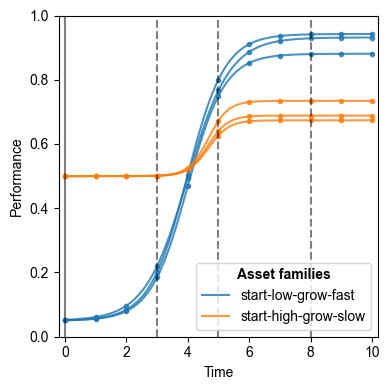

2

In [30]:
# Experiment 2A questions
nu = 0.1
beta = 5
logistic_growth = lambda t, theta: theta[:,0] + theta[:,1]/(1+np.exp(-theta[:,2]*(3*t-theta[:,3])))

def log_normpdf(x, mean, std):
    log_normpdf_unnorm = -np.log(std)-0.5*np.log(2*np.pi)-0.5*((x-mean)/std)**2
    return log_normpdf_unnorm

def traj_r_T_estimation(rs_traj, t_now=10, T_end=20, dt=1, thetas_support=None, nu=nu, thetas_traj=None, is_plot=False):
    '''Assume that ts is a vector from t=0 to t=t_now, with spacing of 1 unit. 
       Hence, the length of rs_traj should be at least t_now.
       Also, T_end must be larger than t_now.
    '''
    if(t_now<0): # Prior; no evidence r observed so far.
        ts_train = []
    else:
        ts_train = np.arange(0,t_now,dt)[:,None]
    (num_thetas, thetas_dim) = thetas_support.shape
    
    
    # Grid of integration. Needs to be more finer. 
    r_T_grid = np.linspace(-3,5,400)
    
    # 1) Find p(theta|r) as a function of theta.
    log_p_thetaj_given_rj = np.zeros((num_thetas))
    for theta_val_idx in range(num_thetas):
            # Current theta value
            theta_val = thetas_support[theta_val_idx][None,:]
            # Instantiate the flat prior p(theta). 
            log_p_thetaj_given_rj[theta_val_idx] = -np.log(num_thetas)
            for t0_idx in range(len(ts_train)):
                t0 = ts_train[t0_idx]
                r_t0_traj = rs_traj[t0_idx]
                rho_t_given_thetaj = logistic_growth(t0, theta_val)
                log_p_thetaj_given_rj[theta_val_idx] += log_normpdf(rho_t_given_thetaj, r_t0_traj, nu)
    log_p_thetaj_given_rj_normalized =  log_p_thetaj_given_rj - scipy.special.logsumexp(log_p_thetaj_given_rj)    

    # 2) Find p(r_T | rho(T; theta))
    log_r_T_given_thetaj = np.zeros((len(r_T_grid), num_thetas))
    for theta_val_idx in range(num_thetas):
        # Current theta value
        theta_val = thetas_support[theta_val_idx][None,:]
        rho_T_given_thetaj = logistic_growth(T_end, theta_val)
        log_r_T_given_thetaj[:, theta_val_idx] = log_normpdf(r_T_grid, rho_T_given_thetaj, nu)

    # 3) Find p(r_T | r)
    log_p_r_T_and_theta_given_r = log_r_T_given_thetaj + log_p_thetaj_given_rj_normalized[None,:]
    p_r_T_given_r = np.sum(np.exp(log_p_r_T_and_theta_given_r), axis=-1) # Integrate over possible theta values
    p_r_T_given_r = p_r_T_given_r/np.trapz(p_r_T_given_r, x=r_T_grid)
    post_mean = np.trapz(r_T_grid*p_r_T_given_r, x=r_T_grid)
    post_mode = r_T_grid[np.argmax(p_r_T_given_r)]  
    
    
    # Sanity check:
    if(is_plot):
        print("Posterior mean for r_T: ",  post_mean)
        print("Posterior mode for r_T: ",  post_mode)
        
        sorted_array = -np.sort(-log_p_thetaj_given_rj_normalized.reshape(-1))
        print("theta_true:", thetas_traj)
        
        fig, ax = plt.subplots(1,2,figsize=(8,4))
        ax[0].plot(ts, logistic_growth(ts, thetas_traj[None,:]), "k-", label="true traj")
        ax[0].plot(np.squeeze(ts[ts_train]), np.squeeze(rs_traj[ts_train]), "r.", label="training data")
        theta_postmean = np.sum(np.exp(log_p_thetaj_given_rj_normalized)[:,None]*thetas_support, axis=0)[None,:]
        ax[0].plot(ts, logistic_growth(np.squeeze(ts), theta_postmean), "C0--", label="rho(t; E[theta|r])")
        for traj_idx in range(1):
            theta_map_idx = np.where(log_p_thetaj_given_rj_normalized == sorted_array[traj_idx])
            theta_map = thetas_support[theta_map_idx]
            print("theta_map: ",np.squeeze(theta_map))
            ax[0].plot(ts, logistic_growth(np.squeeze(ts), theta_map), "C1--", label="rho(t; Mode[theta|r])")
        ax[0].plot(ts, trajs, "k-", alpha=0.1)
        ax[0].set_ylim([0,1])
        ax[0].set_ylabel("Performance")
        ax[0].set_xlabel("Time")
        ax[0].legend()
        
        ax[1].plot(p_r_T_given_r, r_T_grid, "k-", label="p(r_T | r)")
        ax[1].plot([0,5],[rs_traj[T_end], rs_traj[T_end]], "k--", label="true r_T")
        ax[1].plot([0,5],[post_mean, post_mean], "C0--", label="E[r_T|r]")
        ax[1].plot([0,5],[post_mode, post_mode], "C1--", label="Mode[r_T|r]")
        ax[1].set_ylabel("r_T")
        ax[1].set_xlabel("p(r_T | r)")
        ax[1].set_ylim([0,1])
        ax[1].legend()
        
        plt.suptitle("theta_true="+str(np.round(thetas_traj,2))+", t_now="+str(t_now)+", T_end="+str(T_end))
        plt.tight_layout()
    
    if(is_plot):
        return post_mean, post_mode, fig
    else:
        return post_mean, post_mode

    
    
dt=0.01
ts = np.arange(0,10+dt,dt)[:,None]

ts_integer = np.arange(0,10+dt,1)[:,None]

# 1) The means of trajs
theta0 = np.array([[0.05,0.9,0.5,12]]) # theta[2]=0.8
theta1 = np.array([[0.5,0.2,1,14]])
theta_sigmas = np.array([0,0.03,0.03,0.03])
T_ends = np.array([3,5,8])


# 2) Actual data
num_thetas = 3
theta_dims = theta0.shape[1]
np.random.seed(1)
thetas_0 = np.random.normal(loc=theta0, scale=theta_sigmas, size=(num_thetas,theta_dims))
thetas_1 = np.random.normal(loc=theta1, scale=theta_sigmas, size=(num_thetas,theta_dims))
trajs_0 = logistic_growth(ts, thetas_0).T
trajs_1 = logistic_growth(ts, thetas_1).T
trajs_0_integer = logistic_growth(ts_integer, thetas_0).T
trajs_1_integer = logistic_growth(ts_integer, thetas_1).T

alpha=0.8
fig,ax = plt.subplots(1,1,figsize=(4,4))
for traj_idx in range(num_thetas):
    if(traj_idx==0):
        plt.plot(ts,trajs_0[traj_idx,:],"C0-", alpha=alpha, label="start-low-grow-fast")
        plt.plot(ts,trajs_1[traj_idx,:],"C1-", alpha=alpha, label="start-high-grow-slow")
    else:
        plt.plot(ts,trajs_0[traj_idx,:],"C0-", alpha=alpha)
        plt.plot(ts,trajs_1[traj_idx,:],"C1-", alpha=alpha)
    plt.plot(ts_integer,trajs_0_integer[traj_idx,:],"C0.", alpha=alpha)
    plt.plot(ts_integer,trajs_1_integer[traj_idx,:],"C1.", alpha=alpha)

ax.plot([0,0],[0,2],"k-", alpha=0.5)
for T_end in T_ends:
    ax.plot([T_end,T_end], [0,1.4], "k--",alpha=0.5)
ax.set_xlabel("Time")
ax.set_ylabel("Performance")
ax.set_xlim([-0.2,10.2])
ax.set_ylim([0,1])
ax.legend(title="Asset families",title_fontproperties={'weight': 'bold'}, frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(figpath,"Fig2_partiala.pdf"), format="pdf")
plt.show()

Thetas = {"0": thetas_0, "1": thetas_1}
Trajs = {"0": trajs_0, "1": trajs_1}
len(Trajs)

Binomial test p(choose start-low-grow-fast): prop=0.33, p=0.0008737198369123724, 95% CI=[0.2392,0.43117]
Binomial test p(choose start-low-grow-fast): prop=0.64, p=0.006637120515926128, 95% CI=[0.53788,0.73359]
Binomial test p(choose start-low-grow-fast): prop=0.77, p=5.513580775850052e-08, 95% CI=[0.67514,0.84827]

[[ 1.5         3.87550648]
 [ 1.5         6.0653187 ]
 [ 1.5         0.        ]
 [ 1.13106041 46.15122678]]

[[ 0.16213375  3.45159637 -0.29821964]
 [ 1.5        22.50650931  1.34498636]
 [ 1.39986411 11.99374434 -5.33861252]
 [ 0.89906635  0.77666378 -0.32277338]]


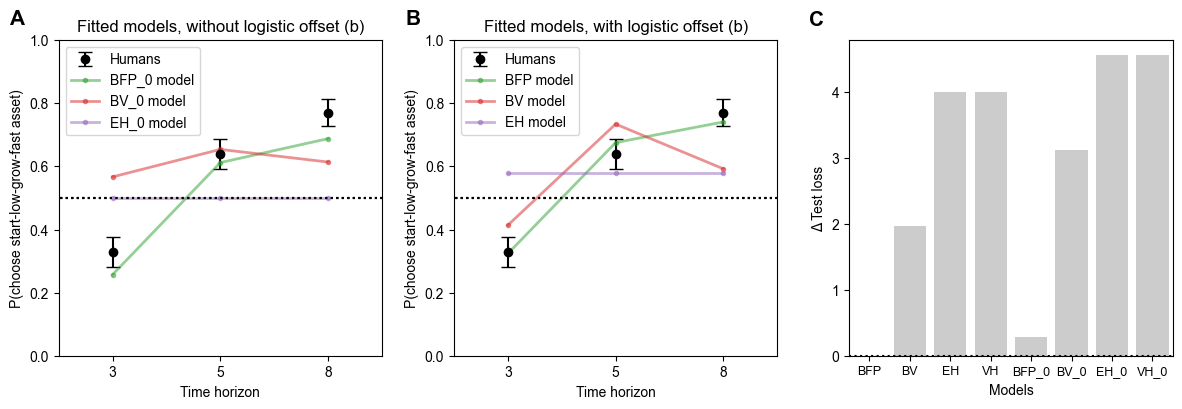

In [31]:
linewidth=2

with open(os.path.join(data_path,'exp1_data.pickle'), 'rb') as handle:
    b = pickle.load(handle)
    choices = b["choices"]
    T_ends = b["T_ends"]
    Thetas = b["Thetas"]
    Trajs = b["Trajs"]
    ts = b["ts"]
dt = ts[1]-ts[0]
n_subj,n_questions = choices.shape
choices_mean = np.mean(choices, axis=0)
choices_std = np.std(choices, ddof=1, axis=0) # Use sample std: denom is (N-1)
choices_sem = choices_std/np.sqrt(n_subj)
n_stay = n_subj * choices_mean
n_subjs=[n_subj,n_subj,n_subj]

# Print the binomial test results, and the estimated 95% CI under normal approximation.
for question in range(n_questions):
    result = binomtest(k=int(n_stay[question]), n=n_subjs[question], p=0.5)
    print("Binomial test p(choose start-low-grow-fast): prop={0}, p={1}, 95% CI=[{2},{3}]".format(result.statistic, result.pvalue, np.round(result.proportion_ci()[0],5), np.round(result.proportion_ci()[1],5)))

def prob_choose_velocity_logistic(theta = [0.1,10,0], T_end=T_end, start_agent="velocity", model="bayesian_postmean", include_offset_param = True, Thetas=Thetas, Trajs=Trajs, rs_traj=[], t_now=-1, dt=dt, is_plot=False):
    '''Function to evaluate logistic probabilities outputted by each model.'''
    nu = theta[0]
    slope = theta[1]
    if(include_offset_param):
        offset = theta[2]
    else:
        offset = 0
        
    
    prior_mean_trajs_raw = np.zeros((len(Trajs), 1, 1, len(ts)))
    prior_mode_trajs_raw = np.zeros((len(Trajs), 1, 1, len(ts)))

    # Loop over each trajectory family / agent. 
    for traj_family_idx in range(len(Trajs)):
        thetas = Thetas[str(traj_family_idx)]
        trajs = Trajs[str(traj_family_idx)]
        for T_end_idx in range(len(ts)):
            T_end_temp = ts[T_end_idx]
            prior_mean_trajs_raw[traj_family_idx,0,0,T_end_idx], prior_mode_trajs_raw[traj_family_idx,0,0,T_end_idx] = traj_r_T_estimation(rs_traj=rs_traj, t_now=-1, T_end=T_end_temp, dt=dt, nu=nu, thetas_support=thetas, is_plot=is_plot)
    softmax_probs_exploit = np.exp(beta*np.squeeze(prior_mean_trajs_raw[0,:])) / (np.exp(beta*np.squeeze(prior_mean_trajs_raw[0,:])) + np.exp(beta*np.squeeze(prior_mean_trajs_raw[1,:])))
    
    if(start_agent=="velocity"):
        velocity_final_height = prior_mean_trajs_raw[0,0,0,T_end]
        exploitation_final_height = prior_mean_trajs_raw[1,0,0,T_end-t_now]
        #softmax_prob = np.exp(beta*velocity_final_height) / (np.exp(beta*velocity_final_height) + np.exp(beta*exploitation_final_height))
    else: 
        velocity_final_height = prior_mean_trajs_raw[0,0,0,T_end-t_now]
        exploitation_final_height = prior_mean_trajs_raw[1,0,0,T_end]
        #softmax_prob = np.exp(beta*exploitation_final_height) / (np.exp(beta*velocity_final_height) + np.exp(beta*exploitation_final_height))
         
                        
    if(model=="bayesian_postmean"):
        if(start_agent=="velocity"):
            final_height_diff = velocity_final_height - exploitation_final_height
        else:
            final_height_diff = exploitation_final_height - velocity_final_height
        prob_stay = 1 / (1 + np.exp(offset - slope * final_height_diff))
    elif(model=="exploitation" or model=="exploitation_heuristic"):
        if(start_agent=="velocity"):
            initial_height_diff = np.squeeze(prior_mean_trajs_raw)[0,0] - np.squeeze(prior_mean_trajs_raw)[1,0]
        else:
            initial_height_diff = np.squeeze(prior_mean_trajs_raw)[0,0] - np.squeeze(prior_mean_trajs_raw)[1,0]
        prob_stay = 1 / (1 + np.exp(offset -slope * initial_height_diff))
    elif(model=="velocity"):
        velocity_traj0_Tend = (velocity_final_height-prior_mean_trajs_raw[0,0,0,0])/(T_end-t_now)
        velocity_traj1_Tend = (exploitation_final_height-prior_mean_trajs_raw[1,0,0,0])/(T_end-t_now)
        if(start_agent=="velocity"):
            velocity_diff = velocity_traj0_Tend - velocity_traj1_Tend
        else:
            velocity_diff = velocity_traj1_Tend - velocity_traj0_Tend
#         print(velocity_diff)
        prob_stay = 1 / (1 + np.exp(offset - slope * velocity_diff))
    elif(model=="velocity_heuristic"):
        # Velocity heuristic, which looks at past velocity, is undefined for strategy selection (where t_now=0)
        prob_stay = 1 / (1 + np.exp(offset - slope * 0))

    return prob_stay


     
    
# Visualize model fits.
t_nows = [0,0,0]
n_questions = len(T_ends)
start_agents=["velocity"]
models = ["bayesian_postmean","velocity","exploitation_heuristic","velocity_heuristic"]
# model_names = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic"]
subplot_titles = ["Fitted models, without logistic offset (b)", "Fitted models, with logistic offset (b)"]
beta = 5
T_ends_complete = [range(3,11)]
t_nows_complete = 2*np.ones((len(T_ends_complete))).astype(int)
agent_names = ["Velocity","Exploitation"]
logistic_probs_stay = np.zeros((2, len(models), len(T_ends)))

fig,ax = plt.subplots(1,3, figsize=(12,4.2))
fig.subplots_adjust(wspace=2)
t_nows_complete = 2*np.ones((len(T_ends_complete))).astype(int)
agent_names = ["Velocity","Exploitation"]

subplot_count = -1
for include_offset_param_val in [False, True]:
    subplot_count = subplot_count+1;
    
    # Load data
    if(include_offset_param_val):
        suffix_offset = "_offset"
        model_names = ["BFP model","BV model", "EH model","VH model"]
    else:
        suffix_offset = "_nooffset"
        model_names = ["BFP_0 model","BV_0 model", "EH_0 model","VH_0 model"]
    filename = "exp1_fits_logistic_heuristics"+suffix_offset
    with open(os.path.join(fits_path,filename+'.pickle'), 'rb') as handle:
        b = pickle.load(handle)
    best_params_fitted = b["best_params_fitted"]
    crossentropy_fitted = b["crossentropy_fitted"]
    data = b["data"]
    models = b["models"]
    include_offset_param = b["include_offset_param"]
    print()
    print(best_params_fitted)
    
    
    # Visualize fits
    for forced_agent in range(1):
        ax[subplot_count].errorbar(range(n_questions),choices_mean, yerr=choices_sem, fmt='-o',color="k", linestyle="", capsize=5, label="Humans")
        for model_idx in range(len(models)-1):
            start_agent = start_agents[forced_agent]
            for task in range(len(T_ends)):
                t_now = t_nows[task]
                T_end = T_ends[task]
                logistic_probs_stay[forced_agent, model_idx, task] = prob_choose_velocity_logistic(theta=best_params_fitted[model_idx,:], T_end=T_end, t_now=t_now, include_offset_param=include_offset_param, start_agent=start_agent, model=models[model_idx])

            ax[subplot_count].plot(range(n_questions), logistic_probs_stay[forced_agent, model_idx,:], ".-", linewidth=linewidth, color="C"+str(model_idx+2), alpha=0.5, label=model_names[model_idx])
            ax[subplot_count].plot([-1,3],[0.5,0.5], "k:")
            ax[subplot_count].set_ylabel("P(choose start-low-grow-fast asset)")
            ax[subplot_count].set_ylim([0,1])
            ax[subplot_count].set_xlim([-0.5,2.5])
            ax[subplot_count].set_xticks([0,1,2])
            ax[subplot_count].set_xticklabels([3,5,8])
            ax[subplot_count].set_xlabel("Time horizon")
            ax[subplot_count].set_title(subplot_titles[subplot_count])

    # Figure indexing
    handles, labels = ax[subplot_count].get_legend_handles_labels()
    # specify order 
    order = [3,0,1,2] 
    # pass handle & labels lists along with order as below 
    ax[subplot_count].legend([handles[i] for i in order], [labels[i] for i in order]) 

# Model comparison plot
model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
# model_names_full = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic","Bayesian final height 0","Bayesian velocity 0", "Exploitation heuristic 0","Velocity heuristic 0"]
model_names_full = ["BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]
filename = "exp1_fits_logistic_heuristics_cv"
with open(os.path.join(fits_path,filename+'.pickle'), 'rb') as handle:
    b = pickle.load(handle)
crossentropy_testloss = b["crossentropy_testloss"]
# 2) Average over folds for each subject, then sum over subjects.
crossentropy_cv = np.mean(crossentropy_testloss,axis=1)
crossentropy_cv_sem = np.nanstd(crossentropy_testloss-np.min(crossentropy_testloss,axis=0)[None,:], ddof=1, axis=1) / np.sqrt(n_folds) # Errorbars are SEM over 

# 3) Visualize
ax[2].bar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), color="k", alpha=0.2)
yerr = crossentropy_cv_sem
ax[2].plot([-0.5,len(model_fullnames)-1+0.5],[0,0],"k:")
ax[2].set_xlim([-0.5,len(model_fullnames)-1+0.5])
ax[2].set_ylabel("Δ Test loss")
ax[2].set_xlabel("Models")
ax[2].set_xticks(range(len(model_fullnames)))
ax[2].set_xticklabels(model_names_full, fontsize=9)
ax[2].tick_params(axis='x', labelrotation=0) 


ax[0].text(-0.95,1.05, "A", fontsize=15, weight="bold")
ax[1].text(-0.95,1.05, "B", fontsize=15, weight="bold")
ax[2].text(-1.5,5, "C", fontsize=15, weight="bold")
#fig.suptitle("Experiment 1: humans and fitted logistic models")
fig.tight_layout()
plt.savefig(os.path.join(figpath,"Fig2_partialb.pdf"), format="pdf")
plt.show()

# Experiment 2

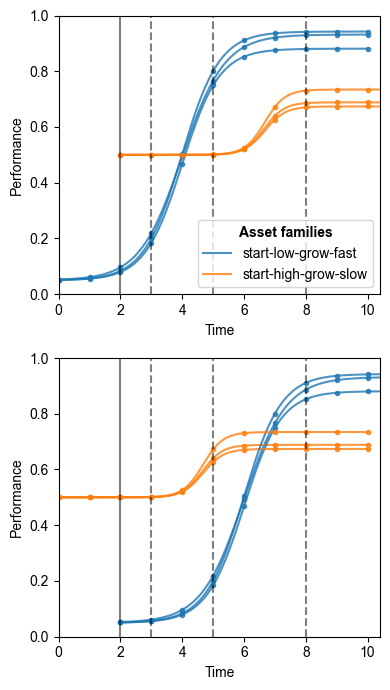

2

In [32]:
nu = 0.1
logistic_growth = lambda t, theta: theta[:,0] + theta[:,1]/(1+np.exp(-theta[:,2]*(3*t-theta[:,3])))

def log_normpdf(x, mean, std):
    log_normpdf_unnorm = -np.log(std)-0.5*np.log(2*np.pi)-0.5*((x-mean)/std)**2
    return log_normpdf_unnorm

def traj_r_T_estimation(rs_traj, t_now=2, T_end=10, dt=1, thetas_support=None, nu=nu, thetas_traj=None, is_plot=False):
    '''Assume that ts is a vector from t=0 to t=t_now, with spacing of 1 unit. 
       Hence, the length of rs_traj should be at least t_now.
       Also, T_end must be larger than t_now.
    '''
    if(t_now<0): # Prior; no evidence r observed so far.
        ts_train = []
    else:
        ts_train = np.arange(0,t_now,dt)[:,None]
    (num_thetas, thetas_dim) = thetas_support.shape
    
    
    # Grid of integration. Needs to be more finer. 
    r_T_grid = np.linspace(-3,5,400)
    
    # 1) Find p(theta|r) as a function of theta.
    log_p_thetaj_given_rj = np.zeros((num_thetas))
    for theta_val_idx in range(num_thetas):
            # Current theta value
            theta_val = thetas_support[theta_val_idx][None,:]
            # Instantiate the flat prior p(theta). 
            log_p_thetaj_given_rj[theta_val_idx] = -np.log(num_thetas)
            for t0_idx in range(len(ts_train)):
                t0 = ts_train[t0_idx]
                r_t0_traj = rs_traj[t0_idx]
                rho_t_given_thetaj = logistic_growth(t0, theta_val)
                log_p_thetaj_given_rj[theta_val_idx] += log_normpdf(rho_t_given_thetaj, r_t0_traj, nu)
    log_p_thetaj_given_rj_normalized =  log_p_thetaj_given_rj - scipy.special.logsumexp(log_p_thetaj_given_rj)    

    # 2) Find p(r_T | rho(T; theta))
    log_r_T_given_thetaj = np.zeros((len(r_T_grid), num_thetas))
    for theta_val_idx in range(num_thetas):
        # Current theta value
        theta_val = thetas_support[theta_val_idx][None,:]
        rho_T_given_thetaj = logistic_growth(T_end, theta_val)
        log_r_T_given_thetaj[:, theta_val_idx] = log_normpdf(r_T_grid, rho_T_given_thetaj, nu)

    # 3) Find p(r_T | r)
    log_p_r_T_and_theta_given_r = log_r_T_given_thetaj + log_p_thetaj_given_rj_normalized[None,:]
    p_r_T_given_r = np.sum(np.exp(log_p_r_T_and_theta_given_r), axis=-1) # Integrate over possible theta values
    p_r_T_given_r = p_r_T_given_r/np.trapz(p_r_T_given_r, x=r_T_grid)
    post_mean = np.trapz(r_T_grid*p_r_T_given_r, x=r_T_grid)
    post_mode = r_T_grid[np.argmax(p_r_T_given_r)]  
    
    
    # Sanity check:
    if(is_plot):
        print("Posterior mean for r_T: ",  post_mean)
        print("Posterior mode for r_T: ",  post_mode)
        
        sorted_array = -np.sort(-log_p_thetaj_given_rj_normalized.reshape(-1))
        print("theta_true:", thetas_traj)
        
        fig, ax = plt.subplots(1,2,figsize=(8,4))
        ax[0].plot(ts, logistic_growth(ts, thetas_traj[None,:]), "k-", label="true traj")
        ax[0].plot(np.squeeze(ts[ts_train]), np.squeeze(rs_traj[ts_train]), "r.", label="training data")
        theta_postmean = np.sum(np.exp(log_p_thetaj_given_rj_normalized)[:,None]*thetas_support, axis=0)[None,:]
        ax[0].plot(ts, logistic_growth(np.squeeze(ts), theta_postmean), "C0--", label="rho(t; E[theta|r])")
        for traj_idx in range(1):
            theta_map_idx = np.where(log_p_thetaj_given_rj_normalized == sorted_array[traj_idx])
            theta_map = thetas_support[theta_map_idx]
            print("theta_map: ",np.squeeze(theta_map))
            ax[0].plot(ts, logistic_growth(np.squeeze(ts), theta_map), "C1--", label="rho(t; Mode[theta|r])")
        ax[0].plot(ts, trajs, "k-", alpha=0.1)
        ax[0].set_ylim([0,1])
        ax[0].set_ylabel("Performance")
        ax[0].set_xlabel("Time")
        ax[0].legend()
        
        ax[1].plot(p_r_T_given_r, r_T_grid, "k-", label="p(r_T | r)")
        ax[1].plot([0,5],[rs_traj[T_end], rs_traj[T_end]], "k--", label="true r_T")
        ax[1].plot([0,5],[post_mean, post_mean], "C0--", label="E[r_T|r]")
        ax[1].plot([0,5],[post_mode, post_mode], "C1--", label="Mode[r_T|r]")
        ax[1].set_ylabel("r_T")
        ax[1].set_xlabel("p(r_T | r)")
        ax[1].set_ylim([0,1])
        ax[1].legend()
        
        plt.suptitle("theta_true="+str(np.round(thetas_traj,2))+", t_now="+str(t_now)+", T_end="+str(T_end))
        plt.tight_layout()
    
    if(is_plot):
        return post_mean, post_mode, fig
    else:
        return post_mean, post_mode


    
dt=0.01
ts = np.arange(0,10+dt,dt)[:,None]

ts_integer = np.arange(0,10+dt,1)[:,None]

# 1) The means of trajs
theta0 = np.array([[0.05,0.9,0.5,12]]) # theta[2]=0.8
theta1 = np.array([[0.5,0.2,1,14]])
theta_sigmas = np.array([0,0.03,0.03,0.03])
T_ends = np.array([3,5,8])


# 2) Actual data
num_thetas = 3
theta_dims = theta0.shape[1]
np.random.seed(1)
thetas_0 = np.random.normal(loc=theta0, scale=theta_sigmas, size=(num_thetas,theta_dims))
thetas_1 = np.random.normal(loc=theta1, scale=theta_sigmas, size=(num_thetas,theta_dims))
trajs_0 = logistic_growth(ts, thetas_0).T
trajs_1 = logistic_growth(ts, thetas_1).T
trajs_0_integer = logistic_growth(ts_integer, thetas_0).T
trajs_1_integer = logistic_growth(ts_integer, thetas_1).T

alpha=0.8
t_now=2
fig,ax = plt.subplots(2,1,figsize=(4,7))
fig.subplots_adjust(hspace=1)

for start_agent_idx in range(2):
    for traj_idx in range(num_thetas):
        if(traj_idx==0):
            ax[start_agent_idx].plot(ts+t_now*(0!=start_agent_idx), trajs_0[traj_idx,:],"C0-", alpha=alpha, label="start-low-grow-fast")
            ax[start_agent_idx].plot(ts+t_now*(1!=start_agent_idx),trajs_1[traj_idx,:],"C1-", alpha=alpha, label="start-high-grow-slow")
        else:
            ax[start_agent_idx].plot(ts+t_now*(0!=start_agent_idx),trajs_0[traj_idx,:],"C0-", alpha=alpha)
            ax[start_agent_idx].plot(ts+t_now*(1!=start_agent_idx),trajs_1[traj_idx,:],"C1-", alpha=alpha)
        ax[start_agent_idx].plot(ts_integer+t_now*(0!=start_agent_idx),trajs_0_integer[traj_idx,:],"C0.", alpha=alpha)
        ax[start_agent_idx].plot(ts_integer+t_now*(1!=start_agent_idx),trajs_1_integer[traj_idx,:],"C1.", alpha=alpha)

    ax[start_agent_idx].plot([t_now,t_now],[0,2],"k-", alpha=0.5)
    for T_end in T_ends:
        ax[start_agent_idx].plot([T_end,T_end], [0,1.4], "k--", alpha=0.5)
    ax[start_agent_idx].set_xlabel("Time")
    ax[start_agent_idx].set_ylabel("Performance")
    ax[start_agent_idx].set_xlim([0,10.4])
    ax[start_agent_idx].set_ylim([0,1])
    ax[0].legend(title="Asset families",title_fontproperties={'weight': 'bold'}, frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(figpath,"Fig3_partial.pdf"), format="pdf")
plt.show()

Thetas = {"Velocity": thetas_0, "Exploitation": thetas_1}
Trajs = {"Velocity": trajs_0, "Exploitation": trajs_1}
len(Trajs)

Binomial test p(stay): prop=0.27, p=4.69241261264223e-06, 95% CI=[0.18606642229074066,0.36801627290897476]
Binomial test p(stay): prop=0.67, p=0.0008737198369123724, 95% CI=[0.5688272492224289,0.7608014653773981]
Binomial test p(stay): prop=0.83, p=1.3097998650070218e-11, 95% CI=[0.7418245893678491,0.8977350899644719]
Binomial test p(stay): prop=0.83, p=1.3097998650070218e-11, 95% CI=[0.7418245893678491,0.8977350899644719]
Binomial test p(stay): prop=0.62, p=0.02097873567785172, 95% CI=[0.5174606942491933,0.7152325238585205]
Binomial test p(stay): prop=0.1, p=3.0632901754379845e-17, 95% CI=[0.049004689221485945,0.17622259774017535]

[[5.67570876e-01 3.23658989e+00]
 [1.50000000e+00 4.67630942e+00]
 [4.87401225e-01 1.00000000e-03]
 [1.19508643e+00 3.09082400e+01]]

[[ 1.50000000e+00  4.03792818e+00  3.30084817e-01]
 [ 1.50000000e+00  4.75231743e+00  1.82862400e-02]
 [ 1.14677497e+00  1.00000000e-03 -2.14139275e-01]
 [ 1.01702354e+00  2.42888816e+01 -7.65281751e-02]]


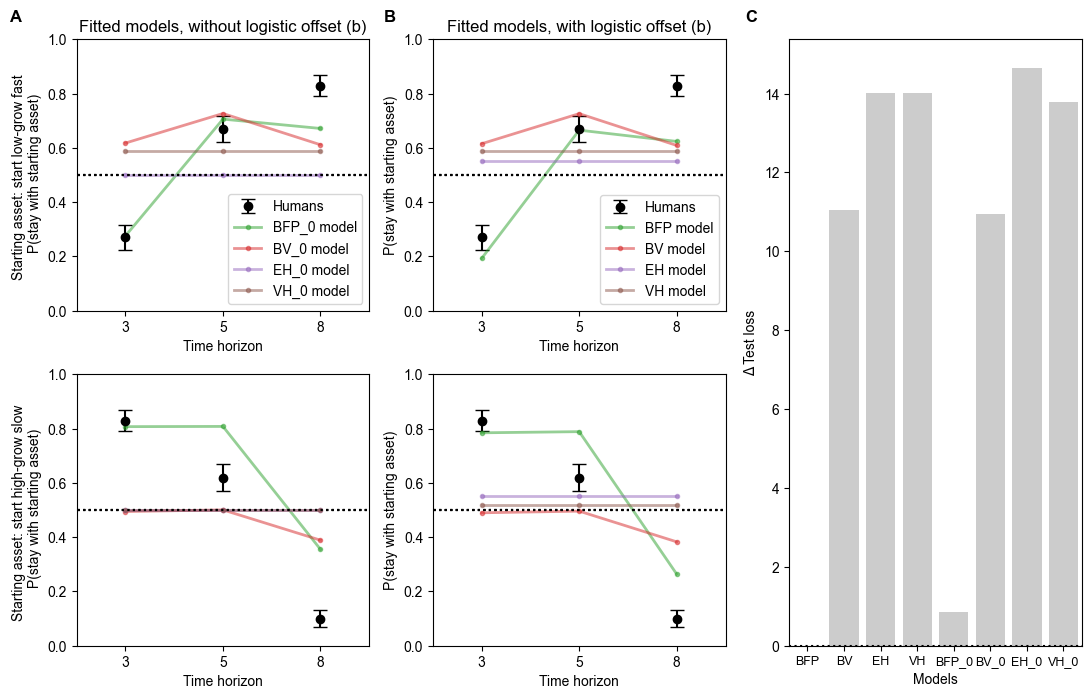

In [33]:
# Load human data
linewidth=2

agent_names = ["Velocity","Exploitation"]
models = ["bayesian_postmean","velocity","exploitation_heuristic","velocity_heuristic"]
# model_names = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic"]
model_names = ["BFP model","BV model", "EH model","VH model"]
subplot_titles = ["Fitted models, without logistic offset (b)", "Fitted models, with logistic offset (b)"]
start_agents = agent_names
with open(os.path.join(data_path,'exp2_data.pickle'), 'rb') as handle:
    b = pickle.load(handle)
    choices_allconds = b["choices_allconds"]
    t_nows = b["t_nows"]
    T_ends = b["T_ends"]
    Thetas = b["Thetas"]
    Trajs = b["Trajs"]
    ts = b["ts"]
    testtrajidx_allconds = b["testtrajidx_allconds"]
    
def capitalize_dict_keys(input_dict):
    """Capitalizes the first letter of each key in a dictionary.
    Args:
    input_dict: The dictionary to modify.
    Returns:
    A new dictionary with the first letter of each key capitalized.
    """
    return {key.capitalize(): value for key, value in input_dict.items()}
choices_allconds = capitalize_dict_keys(choices_allconds)
Trajs = capitalize_dict_keys(Trajs)
Thetas = capitalize_dict_keys(Thetas)
testtrajidx_allconds = capitalize_dict_keys(testtrajidx_allconds)


dt = ts[1]-ts[0]
n_questions = len(T_ends)
choices_mean = np.zeros((2, n_questions))
choices_std = np.zeros((2, n_questions))
choices_sem = np.zeros((2, n_questions))
for start_agent_idx in range(len(agent_names)):
    start_agent = agent_names[start_agent_idx]
    choices = choices_allconds[start_agent]
    n_subj_cond = choices.shape[0]
    choices_mean[start_agent_idx,:] = np.mean(choices, axis=0) # Originnaly in choices, Stay is 0, Switch is 1. Need to flip this.
    choices_std[start_agent_idx,:] = np.std(choices, ddof=1, axis=0) #ddof = 1 means computing the sample std with (N-1) as denom
    choices_sem[start_agent_idx,:] = choices_std[start_agent_idx,:]/np.sqrt(n_subj_cond)
    
    # Print the binomial test results, and the estimated 95% CI under normal approximation.
    for question in range(n_questions):
        result = binomtest(k=int(choices_mean[start_agent_idx,question]*n_subj_cond), n=n_subj_cond, p=0.5)
        print("Binomial test p(stay): prop={0}, p={1}, 95% CI=[{2},{3}]".format(result.statistic, result.pvalue, result.proportion_ci()[0], result.proportion_ci()[1]))


num_testtrajs = Trajs[agent_names[0]].shape[1]
num_subjss = np.zeros((len(agent_names),num_testtrajs, n_questions))
num_choosestays = np.zeros((len(agent_names),num_testtrajs, n_questions))
num_tasks = n_questions


for start_agent_idx in range(len(agent_names)):
    agent_name = agent_names[start_agent_idx]
    choices_cond = choices_allconds[agent_name]
    testtrajidx_cond = testtrajidx_allconds[agent_name]
    for testtraj_idx in range(num_testtrajs):
        relevant_subjs = np.where(testtrajidx_cond==testtraj_idx)[0]
        num_subjss[start_agent_idx, testtraj_idx,:] = len(relevant_subjs)
        num_choosestays[start_agent_idx, testtraj_idx,:] = np.sum(choices_cond[relevant_subjs,:], axis=0)

        
# Function to output logistic probs from models
p_stay_logistic = lambda diff, slope, offset: 1 / (1 + np.exp(offset - slope * diff))

def prob_stay_logistic(theta=[0.1,10,0], T_end=T_end, start_agent="velocity", model="bayesian_postmean", include_offset_param=True, Thetas=Thetas, Trajs=Trajs, rs_traj=[], t_now=-1, dt=dt, thetas_support=Thetas["Exploitation"], is_plot=False):
    nu = theta[0]
    slope = theta[1]
    if(include_offset_param):
        offset = theta[2]
    else:
        offset = 0

    if(model=="bayesian_postmean"):
        if(start_agent=="Velocity"):
            velocity_final_height, _ = traj_r_T_estimation(rs_traj=rs_traj, t_now=t_now, T_end=T_end, dt=dt, nu=nu, thetas_support=Thetas["Velocity"], is_plot=is_plot)
            exploitation_final_height, _ = traj_r_T_estimation(rs_traj=[], t_now=-1, T_end=T_end-t_now, dt=dt, nu=nu, thetas_support=Thetas["Exploitation"], is_plot=is_plot)            
            final_height_diff = velocity_final_height - exploitation_final_height
        else:
            exploitation_final_height, _ = traj_r_T_estimation(rs_traj=rs_traj, t_now=t_now, T_end=T_end, dt=dt, nu=nu, thetas_support=Thetas["Exploitation"], is_plot=is_plot)       
            velocity_final_height, _ = traj_r_T_estimation(rs_traj=[], t_now=-1, T_end=T_end-t_now, dt=dt, nu=nu, thetas_support=Thetas["Velocity"], is_plot=is_plot)
            final_height_diff = exploitation_final_height - velocity_final_height
        prob_stay = p_stay_logistic(final_height_diff, slope, offset)
        
    elif(model=="velocity"):
        if(start_agent=="Velocity"):
            velocity_final_height, _ = traj_r_T_estimation(rs_traj=rs_traj, t_now=t_now, T_end=T_end, dt=dt, nu=nu, thetas_support=Thetas["Velocity"], is_plot=is_plot)
            exploitation_final_height, _ = traj_r_T_estimation(rs_traj=[], t_now=-1, T_end=T_end-t_now, dt=dt, nu=nu, thetas_support=Thetas["Exploitation"], is_plot=is_plot)    
            velocity_current_height, _ = traj_r_T_estimation(rs_traj=rs_traj, t_now=t_now, T_end=t_now, dt=dt, nu=nu, thetas_support=Thetas["Velocity"], is_plot=is_plot)
            exploitation_current_height, _ = traj_r_T_estimation(rs_traj=[], t_now=-1, T_end=0, dt=dt, nu=nu, thetas_support=Thetas["Exploitation"], is_plot=is_plot)            
            velocity_traj0_Tend = (velocity_final_height-velocity_current_height)/(T_end-t_now)
            velocity_traj1_Tend = (exploitation_final_height-exploitation_current_height)/(T_end-t_now)
            velocity_diff = velocity_traj0_Tend - velocity_traj1_Tend
        else:
            exploitation_final_height, _ = traj_r_T_estimation(rs_traj=rs_traj, t_now=t_now, T_end=T_end, dt=dt, nu=nu, thetas_support=Thetas["Exploitation"], is_plot=is_plot)
            velocity_final_height, _ = traj_r_T_estimation(rs_traj=[], t_now=-1, T_end=T_end-t_now, dt=dt, nu=nu, thetas_support=Thetas["Velocity"], is_plot=is_plot)    
            exploitation_current_height, _ = traj_r_T_estimation(rs_traj=rs_traj, t_now=t_now, T_end=t_now, dt=dt, nu=nu, thetas_support=Thetas["Exploitation"], is_plot=is_plot)
            velocity_current_height, _ = traj_r_T_estimation(rs_traj=[], t_now=-1, T_end=0, dt=dt, nu=nu, thetas_support=Thetas["Velocity"], is_plot=is_plot)            
            velocity_traj0_Tend = (velocity_final_height-velocity_current_height)/(T_end-t_now)
            velocity_traj1_Tend = (exploitation_final_height-exploitation_current_height)/(T_end-t_now)
            velocity_diff = velocity_traj1_Tend - velocity_traj0_Tend
        #softmax_velocity_Tend = np.exp(beta*velocity_traj0_Tend)/(np.exp(beta*velocity_traj0_Tend)+np.exp(beta*velocity_traj1_Tend))
        prob_stay = p_stay_logistic(velocity_diff, slope, offset)
        
    elif(model=="exploitation_heuristic"):
        # Myopic model, like MVT. Compares current heights of starting and new trajectory.
        if(start_agent=="Velocity"):
            exploitation_initial_height, _ = traj_r_T_estimation(rs_traj=[], t_now=-1, T_end=0, dt=dt, nu=nu, thetas_support=Thetas["Exploitation"], is_plot=is_plot)            
            current_height_diff = rs_traj[t_now] - exploitation_initial_height
        else:
            velocity_initial_height, _ = traj_r_T_estimation(rs_traj=[], t_now=-1, T_end=0, dt=dt, nu=nu, thetas_support=Thetas["Velocity"], is_plot=is_plot)            
            current_height_diff = rs_traj[t_now] - velocity_initial_height
        prob_stay = p_stay_logistic(current_height_diff, slope, offset)
        
    elif(model=="velocity_heuristic"):
        # Compares the average velocity of the starting trajectory so far, to its most recent velocity. More likely to switch if the latter is smaller than former.
        velocity_diff = (rs_traj[t_now]- rs_traj[t_now-1]) - (rs_traj[t_now]-rs_traj[0])/(t_now)
        prob_stay = p_stay_logistic(velocity_diff, slope, offset)
        

    return prob_stay


# Visualization
beta = 5
T_ends_complete = [range(3,11)]
t_nows_complete = 2*np.ones((len(T_ends_complete))).astype(int)
logistic_probs_stay = np.zeros((2, len(models)*2, len(T_ends)))
logistic_probs_stay_bytesttrajidx = np.zeros((2, len(models)*2, Trajs[agent_names[0]].shape[1], len(T_ends)))
# fig,ax = plt.subplots(2,3, figsize=(11,7))


layout = [
    ["A", "C", "E"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["B","D","E"],  # Row 2: C, D, and E are independent, "." leaves blank space
]

fig, ax = plt.subplot_mosaic(layout, figsize=(11, 7))
plot_idx_raw = -1

# Visualize fits
subplot_count = -1

for include_offset_param_val in [False,True]:
    subplot_count = subplot_count+1;
    
    # Load data
    if(include_offset_param_val):
        suffix_offset = "_offset"
        model_names = ["BFP model","BV model", "EH model","VH model"]
        legend_panel = "C"
    else:
        suffix_offset = "_nooffset"
        model_names = ["BFP_0 model","BV_0 model", "EH_0 model","VH_0 model"]
        legend_panel = "A"
    filename = "exp2_fits_logistic_heuristics"+suffix_offset
    with open(os.path.join(fits_path,filename+'.pickle'), 'rb') as handle:
        b = pickle.load(handle)
    best_params_fitted = b["best_params_fitted"]
    crossentropy_fitted = b["crossentropy_fitted"]
    data = b["data"]
    models = b["models"]
    include_offset_param = b["include_offset_param"]
    print()
    print(best_params_fitted)

    # Visualize fits
    for forced_agent in range(2):
        plot_idx_raw = plot_idx_raw +1
        plot_idx = chr(plot_idx_raw + 65)
        ax[plot_idx].errorbar(range(num_tasks),choices_mean[forced_agent,:], yerr=choices_sem[forced_agent,:], fmt='-o',color="k", linestyle="", capsize=5, label="Humans")
        for model_idx in range(len(models)):           
            start_agent = start_agents[forced_agent]
            for testtraj_idx in range(num_testtrajs):
                rs_traj = Trajs[start_agent][:,testtraj_idx]
                for task in range(len(T_ends)):
                    t_now = t_nows[task]
                    T_end = T_ends[task]
                    logistic_probs_stay_bytesttrajidx[forced_agent, model_idx, testtraj_idx, task] = prob_stay_logistic(theta=best_params_fitted[model_idx,:], T_end=T_end, t_now=t_now, start_agent=start_agent, model=models[model_idx], rs_traj=rs_traj, include_offset_param=include_offset_param_val)
            # Average over the different test trajectories, where weights are determined by the proportion of participants that got each test trajectory.
            logistic_probs_stay[forced_agent, model_idx, :] = np.sum(logistic_probs_stay_bytesttrajidx[forced_agent, model_idx, :, :] * (num_subjss[forced_agent,:,0:1]/np.sum(num_subjss[forced_agent,:,0:1])), axis=0)

            
            ax[plot_idx].plot(range(num_tasks), logistic_probs_stay[forced_agent, model_idx,:], ".-", linewidth=linewidth, color="C"+str(model_idx+2), alpha=0.5, label=model_names[model_idx])
            ax[plot_idx].plot([-1,3],[0.5,0.5], "k:")
            if(agent_names[forced_agent]=="Velocity"):
                ax["A"].set_ylabel("Starting asset: start low-grow fast \n P(stay with starting asset)")
            else:
                ax["B"].set_ylabel("Starting asset: start high-grow slow \n P(stay with starting asset)")
            ax[plot_idx].set_ylabel("P(stay with starting asset)")
            ax[plot_idx].set_ylim([0,1])
            ax[plot_idx].set_xlim([-0.5,2.5])
            ax[plot_idx].set_xticks([0,1,2])
            ax[plot_idx].set_xticklabels([3,5,8])
            ax[plot_idx].set_xlabel("Time horizon")
            if(plot_idx_raw%2==0):
                ax[plot_idx].set_title(subplot_titles[subplot_count])
            
        
        handles, labels = ax[legend_panel].get_legend_handles_labels()
        # specify order 
        order = [4,0,1,2,3] 
        # pass handle & labels lists along with order as below 
        ax[legend_panel].legend([handles[i] for i in order], [labels[i] for i in order]) 
    
        


# Model comparison plot
model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
# model_names_full = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic","Bayesian final height 0","Bayesian velocity 0", "Exploitation heuristic 0","Velocity heuristic 0"]
model_names_full = ["BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]
filename = "exp2_fits_logistic_heuristics_cv"
with open(os.path.join(fits_path,filename+'.pickle'), 'rb') as handle:
    b = pickle.load(handle)
crossentropy_testloss = b["crossentropy_testloss"]
# 2) Average over folds for each subject, then sum over subjects.
crossentropy_cv = np.mean(crossentropy_testloss,axis=1)
crossentropy_cv_sem = np.nanstd(crossentropy_testloss-np.min(crossentropy_testloss,axis=0)[None,:], ddof=1, axis=1) / np.sqrt(n_folds) # Errorbars are SEM over 
# 3) Visualize
ax["E"].bar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), color="k", alpha=0.2)
yerr = crossentropy_cv_sem
ax["E"].plot([-0.5,len(model_fullnames)-1+0.5],[0,0],"k:")
ax["E"].set_xlim([-0.5,len(model_fullnames)-1+0.5])
ax["E"].set_ylabel("Δ Test loss")
ax["E"].set_xlabel("Models")
ax["E"].set_xticks(range(len(model_fullnames)))
ax["E"].set_xticklabels(model_names_full, fontsize=9)
ax["E"].tick_params(axis='x', labelrotation=0) 


fig.text(0.012,0.975, "A", fontsize=12, weight="bold")
fig.text(0.352,0.975, "B", fontsize=12, weight="bold")
fig.text(0.68,0.975, "C", fontsize=12, weight="bold")

#fig.suptitle("Experiment 1: humans and fitted logistic models")
fig.tight_layout()
plt.savefig(os.path.join(figpath,"Fig4.pdf"), format="pdf")
plt.show()

# Experiment 3

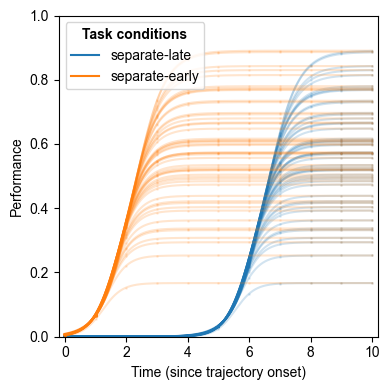

In [50]:
# Experiment 3
dt=0.01  #1
ts = np.arange(0,10+dt,dt)[:,None]
ts_integer = np.arange(0,10+dt,1)[:,None]
logistic_growth = lambda t, theta: theta[:,0] + theta[:,1]/(1+np.exp(-theta[:,2]*(3*t-theta[:,3])))
def logistic_growth_group(ts, traj_assymtotes, left_offset):
    '''Here, theta is a num_thetas x 1 vector, 
    corresponding to theta[:,1] required by the lambda function logistic_growth().'''
    num_thetas,_ = traj_assymtotes.shape
    new_theta = np.zeros((num_thetas,4))
    new_theta[:,0] = 0 # Starting height
    new_theta[:,1] = np.squeeze(traj_assymtotes) # Asymptotic height
    new_theta[:,2] = -1/2*np.squeeze(traj_assymtotes) + 9/8 # Slope
    new_theta[:,3] = left_offset + 25/6*np.squeeze(traj_assymtotes) # Left/right translation
    return logistic_growth(ts, new_theta)
theta_mean = 0.55
theta_nu = 0.15
condition_left_offsets = np.array([17-25/24, 3]) #[17-25/24,3-25/24]


# 2) Actual data
num_thetas = 50
theta_dims = 4
np.random.seed(0)
thetas = np.random.normal(loc=theta_mean, scale=theta_nu, size=(num_thetas,1))
trajs_0 = logistic_growth_group(ts, thetas, condition_left_offsets[0])
trajs_1 = logistic_growth_group(ts, thetas, condition_left_offsets[1])
trajs_0_integer = logistic_growth_group(ts_integer, thetas, condition_left_offsets[0])
trajs_1_integer = logistic_growth_group(ts_integer, thetas, condition_left_offsets[1])
trajs = np.array([trajs_0, trajs_1])
trajs_integer = np.array([trajs_0_integer, trajs_1_integer])

fig, ax = plt.subplots(1,1, figsize=(4,4))
plt.plot(ts,trajs_0,"C0-", alpha=0.2)
plt.plot(ts,trajs_1,"C1-", alpha=0.2)
plt.plot(ts_integer,trajs_0_integer,"C0.", markersize=2, alpha=0.1)
plt.plot(ts_integer,trajs_1_integer,"C1.", markersize=2, alpha=0.1)
ax.set_xlabel("Time (since trajectory onset)")
ax.set_ylabel("Performance")
ax.set_ylim([0,1])
ax.set_xlim([-0.2,10.2])

from matplotlib.lines import Line2D
legend_line0 = Line2D([0], [0], color='C0')  # Use the color of your choice
legend_line1 = Line2D([0], [0], color='C1')  # Use the color of your choice
plt.legend([legend_line0,legend_line1], ["separate-late","separate-early"],title="Task conditions", title_fontproperties={'weight': 'bold'}, frameon=True)  # Single entry for the legend


plt.tight_layout()
plt.savefig(os.path.join(figpath,"Fig5_partial.pdf"), format="pdf")
plt.show()

thetas_support = thetas
num_thetas = len(thetas_support)

In [51]:
# 1) Functions for model fitting
logistic_growth = lambda t, theta: theta[:,0] + theta[:,1]/(1+np.exp(-theta[:,2]*(t-theta[:,3])))
dt=1  #1
ts = np.arange(0,11,dt)[:,None]
T_end = len(ts)-1;

# Group-level parameters for each family
theta_mean = 0.55
theta_nu = 0.15
condition_left_offsets = np.array([17-25/24, 3]) # Offsets for the seplate and sepearly conditions.

def logistic_growth_group(ts, traj_assymtotes, left_offset):
    '''Here, theta is a num_thetas x 1 vector, 
    corresponding to theta[:,1] required by the lambda function logistic_growth().'''
    num_thetas,_ = traj_assymtotes.shape
    new_theta = np.zeros((num_thetas,4))
    new_theta[:,0] = 0 # Starting height
    new_theta[:,1] = np.squeeze(traj_assymtotes) # Asymptotic height
    new_theta[:,2] = -1/2*np.squeeze(traj_assymtotes) + 9/8 # Slope
    new_theta[:,3] = left_offset + 25/6*np.squeeze(traj_assymtotes) # Left/right translation
    return logistic_growth(3*ts, new_theta)

def log_normpdf(x, mean, std):
    log_normpdf_unnorm = -np.log(std)-0.5*np.log(2*np.pi)-0.5*((x-mean)/std)**2
    return log_normpdf_unnorm

## Grid of integration. Needs to be more finer. 
theta0_grid = np.linspace(0,1,50)  
r_T_grid = np.linspace(-3,5,400)

def traj_r_T_estimation(ts, rs_traj, sensory_noise=0.1, cond=0, t_now_idx=0, T_end=T_end):
    ts_train = ts[0:(t_now_idx+1)];

    # 1) Find p(theta|r) as a function of theta.
    log_p_thetaj_given_rj = log_normpdf(theta0_grid,theta_mean,theta_nu) # This is actually the log prior p(theta); [theta0_grid]
    rho_t_given_thetaj = logistic_growth_group(ts_train, theta0_grid[:,None], condition_left_offsets[cond]) # traj heights over time, given theta [ts_train, theta0_grid]
    if(t_now_idx>-1):
        # Update the prior p(theta) using the likelihoods over time p(r_{1:t} | theta), to obtain the posterior p(theta | r_{1:t})
        log_p_thetaj_given_rj = log_p_thetaj_given_rj + np.sum(log_normpdf(rho_t_given_thetaj, rs_traj[0:len(ts_train)][:,None], sensory_noise), axis=0) # np.sum is summing across time over log likelihoods
    # logsumexp
    log_p_thetaj_given_rj_normalized = log_p_thetaj_given_rj - scipy.special.logsumexp(log_p_thetaj_given_rj)


    # 2) Find p(r_T | rho(T; theta))
    rho_T_given_thetaj = logistic_growth_group(T_end, theta0_grid[:,None], condition_left_offsets[cond]) #[theta0_grid, ]
    log_r_T_given_thetaj = log_normpdf(r_T_grid[:,None], rho_T_given_thetaj[None,:], sensory_noise) # [r_T_grid, theta0_grid]

    # 3) Find p(r_T | r)
    log_p_r_T_and_theta_given_r = log_r_T_given_thetaj + log_p_thetaj_given_rj_normalized[None,:]
    p_r_T_given_r = np.trapz(np.exp(log_p_r_T_and_theta_given_r), x=theta0_grid, axis=-1)
    p_r_T_given_r = p_r_T_given_r/np.trapz(p_r_T_given_r, x=r_T_grid)
    post_mean = np.trapz(r_T_grid*p_r_T_given_r, x=r_T_grid)
    return post_mean

p_stay_logistic = lambda diff, slope, offset: 1 / (1 + np.exp(offset - slope * diff))

def prob_stay_logistic(theta, cond=0, ts=ts, t_now=0, T_end=T_end, traj=np.nan, model="bayesian_postmean", include_offset_param = True, return_postmean=False):
    '''Given a set of parameter values theta=(sensory_noise, slope, offset), 
        evaluate p(stay; theta, traj[0:(t_now+1)]) given the starting trajectory's development up until t_now, 
        under a certain model.'''
    sensory_noise = theta[0]
    slope = theta[1]
    if(include_offset_param):
        offset = theta[2]
    else:
        offset = 0

    if(model=="bayesian_postmean"):
        stay_finalheight_postmean = traj_r_T_estimation(ts, traj, sensory_noise=sensory_noise, cond=cond, t_now_idx=t_now, T_end=T_end)
        switch_finalheight_priormean = traj_r_T_estimation(ts, np.nan, sensory_noise=sensory_noise, cond=cond, t_now_idx=-1, T_end=ts[T_end-t_now][0])
        final_height_diff = stay_finalheight_postmean - switch_finalheight_priormean
        prob_stay = p_stay_logistic(final_height_diff, slope, offset)
        if(return_postmean):
            return (prob_stay, final_height_diff)

    elif(model=="velocity"):
        stay_finalheight_postmean = traj_r_T_estimation(ts, traj, sensory_noise=sensory_noise, cond=cond, t_now_idx=t_now, T_end=T_end)
        switch_finalheight_priormean = traj_r_T_estimation(ts, np.nan, sensory_noise=sensory_noise, cond=cond, t_now_idx=-1, T_end=ts[T_end-t_now][0])  
        stay_initial_height_postmean = traj_r_T_estimation(ts, traj, sensory_noise=sensory_noise, cond=cond, t_now_idx=t_now, T_end=t_now)
        switch_initial_height_priormean = traj_r_T_estimation(ts, np.nan, sensory_noise=sensory_noise, cond=cond, t_now_idx=-1, T_end=0)

        stay_velocity = (stay_finalheight_postmean - stay_initial_height_postmean)/(T_end-t_now)
        switch_velocity = (switch_finalheight_priormean - switch_initial_height_priormean)/(T_end-t_now)
        velocity_diff = stay_velocity - switch_velocity
        prob_stay = p_stay_logistic(velocity_diff, slope, offset)
        if(return_postmean):
            return (prob_stay, velocity_diff)

    elif(model=="exploitation_heuristic"):
#         stay_currentheight = traj[t_now]
#         switch_initial_height_priormean = traj_r_T_estimation(ts, np.nan, sensory_noise=sensory_noise, cond=cond, t_now_idx=-1, T_end=0)
#         current_height_diff = stay_currentheight - switch_initial_height_priormean
#         prob_stay = p_stay_logistic(current_height_diff, slope, offset)
        prob_stay = p_stay_logistic(traj[t_now], slope, offset)
        if(return_postmean):
            return (prob_stay, traj[t_now])

    elif(model=="velocity_heuristic"):
        velocity_diff = (traj[t_now]- traj[t_now-1]) - (traj[t_now]-traj[0])/(t_now)
        prob_stay = p_stay_logistic(velocity_diff, slope, offset)
        if(return_postmean):
            return (prob_stay, velocity_diff)



    return prob_stay



T_ends = [10,10]

def crossentropy_loss(theta, data_subj=np.nan, ts=ts, T_ends=T_ends, model="bayesian_postmean",include_offset_param=True, cross_validate=False, cross_validate_timepts=np.nan):
    '''For the data of one subject: [cond, run, t_now, (traj_height, response)],
    and a set of parameter values theta, compute cross entropy loss.'''

    loss = 0;
    for cond in range(n_conds):
        T_end = T_ends[cond]
        for run in range(n_runs):
            traj = data_subj[cond,run,:,0]
            responses = data_subj[cond,run,:,1] # 1 is stay; 0 is switch
            n_steps_beforeswitch = np.sum(1-np.isnan(responses))
            for t_now_idx in range(1,n_steps_beforeswitch+1): # Exclude Month 0, and any month after the switch (if switched)

                if(cross_validate): # Doing cross-validation: only evaluate loss on a subset of dpts.
                    target_tuple = (cond,run,t_now_idx)

                    if(target_tuple in cross_validate_timepts):
                        model_prob_pred = prob_stay_logistic(theta, cond=cond, traj=traj, ts=ts, t_now=ts[t_now_idx][0], T_end=T_end, model=model,include_offset_param=include_offset_param)
                        response = responses[t_now_idx]
                        if(response==1):
                            loss = loss - np.log(max(model_prob_pred,1e-100))
                        elif(response==0):
                            loss = loss - np.log(max(1-model_prob_pred,1e-100))
                        else:
                            print("Warning: CV trials include nan!")
                    else: 
                        continue;

                else: # Not doing cross-validation: fitted to the full dataset.
                    model_prob_pred = prob_stay_logistic(theta, cond=cond, traj=traj, ts=ts, t_now=ts[t_now_idx][0], T_end=T_end, model=model,include_offset_param=include_offset_param)
                    response = responses[t_now_idx]
                    if(response==1):
                        loss = loss - np.log(max(model_prob_pred,1e-100))
                    elif(response==0):
                        loss = loss - np.log(max(1-model_prob_pred,1e-100))
                    else:
                        print("Warning: trials include nan!")
    return loss


def evaluate_p_stay_logistic(theta, data_subj=np.nan, ts=ts, T_ends=T_ends, model="bayesian_postmean",include_offset_param=True):   
    loss = 0;
    model_prob_preds = np.zeros((n_conds, n_runs, n_timesteps))
    model_prob_preds[:] = np.nan;
    stayswitch_diffs = np.zeros((n_conds, n_runs, n_timesteps))
    stayswitch_diffs[:] = np.nan;
    for cond in range(n_conds):
        T_end = T_ends[cond]
        for run in range(n_runs):
            traj = data_subj[cond,run,:,0]
            responses = data_subj[cond,run,:,1] # 1 is stay; 0 is switch
            n_steps_beforeswitch = np.sum(1-np.isnan(responses))
            for t_now_idx in range(1,n_steps_beforeswitch+1): # Exclude Month 0, and any month after the switch (if switched)
                [model_prob_pred, stayswitch_diff] = prob_stay_logistic(theta, cond=cond, traj=traj, ts=ts, t_now=ts[t_now_idx][0], T_end=T_end, model=model, return_postmean=True,include_offset_param=include_offset_param)
                model_prob_preds[cond, run, t_now_idx] = model_prob_pred
                stayswitch_diffs[cond, run, t_now_idx] = stayswitch_diff
    return (model_prob_preds, stayswitch_diffs)


def cross_validation_dataset_partition(responses_allsubj, n_folds=5, seed=0):
    # Cross validation dataset partitioning?
    n_subj = responses_allsubj.shape[1] # [conds, subj, runs, timepts]
    cross_val_setidxs_allsubj = [] # Nested array: subjs -> folds -> (train dataset, test dataset) -> [cond,run,timept] signatures of a trial.

    for subj in range(n_subj):
        responses = responses_allsubj[:,subj,:,:]

        # Step 1: Identify valid trials (0 or 1)
        valid_indices = np.argwhere((responses == 0) | (responses == 1))

        # Step 2: Shuffle indices
        np.random.seed(seed)
        np.random.shuffle(valid_indices)

        # Step 3: Split into 5 folds
        folds = np.array_split(valid_indices, n_folds)

        # Step 4: Create training and testing trial idxs for each fold
        cross_val_setidxs = []
        for i in range(n_folds):
            test_indices = folds[i]
            train_indices = np.concatenate(folds[:i] + folds[i+1:])
            train_indices = [tuple(idx) for idx in train_indices]
            test_indices = [tuple(idx) for idx in test_indices]
            cross_val_setidxs.append((train_indices, test_indices)) # First level are the 5 folds; second level is a tuple with [0] being the training dataset.
        cross_val_setidxs_allsubj.append(cross_val_setidxs)

    return cross_val_setidxs_allsubj

def decompose_model_fullname(model_fullname):
    include_offset_param = "_offset" in model_fullname
    model = model_fullname.rpartition('_')[0]
    return (model, include_offset_param)

### Human data

In [52]:
# Load the human dataset
filename = "exp3_data"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
print(b.keys())  
data = b['data']
traj_params = b["traj_params"]
traj_finalheights = b["counterfactual_traj_finalheights"]
(n_conds,n_subj,n_runs,n_timesteps,_) = data.shape

# Load the fake datasets
filename = os.path.join(data_path, "exp3_fits_fakedata_allmodels")
with open(filename+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
models_true_gen_params = b['true_gen_params']
models_fakedata = b['models_fakedata']

model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
# model_names = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic"]
model_names = ["BFP model","BV model", "EH model","VH model"]
cond_names = ["Separate-late","Separate-early"]

dict_keys(['mturk_IDs', 'data_dims', 'data', 'traj_params', 'counterfactual_traj_finalheights', 'starting_traj_heights_counterfactual', 'ages', 'genders', 'comments'])


In [53]:
# Visualization functions

def visualize_switchtimes(data, is_plot=False, is_save=False):
    p_continuetillends_subjmean = np.zeros((n_conds, n_subj))
    last_free_timesteps_allsubj = np.zeros((n_conds,n_subj,n_runs))
    last_free_timesteps_allsubjmean = np.zeros((n_conds,n_subj))
    for subj in range(n_subj):
        hasswitched_subj_conds = np.zeros((n_conds, n_runs))
        for cond in range(n_conds):
            traj_heights = data[cond,subj,:,:,0]
            last_free_timestep = np.isnan(traj_heights).argmax(axis=1)-1 # -1 entries denote trials in which subj never switched.
            last_free_timesteps_allsubj[cond,subj,:] = last_free_timestep
        last_free_timesteps_subj_cond0 = last_free_timesteps_allsubj[0,subj,:]
        last_free_timesteps_subj_cond0 = last_free_timesteps_subj_cond0[last_free_timesteps_subj_cond0!=-1] # Only consider trials where subj switched.
        last_free_timesteps_subj_cond1 = last_free_timesteps_allsubj[1,subj,:]
        last_free_timesteps_subj_cond1 = last_free_timesteps_subj_cond1[last_free_timesteps_subj_cond1!=-1] # Only consider trials where subj switched.
        last_free_timesteps_allsubjmean[0,subj] = np.mean(last_free_timesteps_subj_cond0)
        last_free_timesteps_allsubjmean[1,subj] = np.mean(last_free_timesteps_subj_cond1)
    
    subjs_didswitch_bothconds = 1-np.isnan(last_free_timesteps_allsubjmean).any(axis=0)

    if(is_plot):
        # Aggregate over all subjects
        last_free_timesteps_allsubj_cond0 = last_free_timesteps_allsubj[0,:,:].flatten();
        last_free_timesteps_allsubj_cond0 = last_free_timesteps_allsubj_cond0[last_free_timesteps_allsubj_cond0!=-1]
        last_free_timesteps_allsubj_cond1 = last_free_timesteps_allsubj[1,:,:].flatten();
        last_free_timesteps_allsubj_cond1 = last_free_timesteps_allsubj_cond1[last_free_timesteps_allsubj_cond1!=-1]
    
        fig, ax = plt.subplots(1,2,figsize=(8,4))
        ax[0].hist(last_free_timesteps_allsubj_cond0, color="C0", bins=np.arange(-1,T_end+1,1)-0.5, alpha=0.5, label="seplate", density=False)
        ax[0].hist(last_free_timesteps_allsubj_cond1, color="C1", bins=np.arange(-1,T_end+1,1)-0.5, alpha=0.5, label="sepearly", density=False)
        ax[0].set_xticks(range(1,T_end))
        # ax.set_ylim([0,1])
        ax[0].set_xlim([0.5,T_end-0.5])
        p_val = scipy.stats.ttest_ind(last_free_timesteps_allsubj_cond0, last_free_timesteps_allsubj_cond1).pvalue
        ax[0].set_title("Aggregate over all trials \n two-sample t-test p={0}".format(np.round(p_val, 6)))
        ax[0].legend()
        ax[0].set_ylabel("Frequency (trials)")
        ax[0].set_xlabel("Time of switching")

        # Paired t-test on mean switch time of subjects (which did switch at least once in both conditions)
        p_val = scipy.stats.ttest_rel(np.squeeze(last_free_timesteps_allsubjmean[0,np.where(subjs_didswitch_bothconds)]), np.squeeze(last_free_timesteps_allsubjmean[1,np.where(subjs_didswitch_bothconds)])).pvalue
        print(p_val)
        ax[1].hist(np.squeeze(last_free_timesteps_allsubjmean[1,np.where(subjs_didswitch_bothconds==1)]-last_free_timesteps_allsubjmean[0,np.where(subjs_didswitch_bothconds==1)]), color="k", alpha=0.2, density=False)
        ax[1].plot([0,0],[0,5],"k:")
        ax[1].set_title("Diff in mean switch time btw. conds, N={0} \n paired t-test p={1}".format(np.sum(subjs_didswitch_bothconds), np.round(p_val, 6)))
        ax[1].set_ylabel("Frequency (subjects)")
        ax[1].set_xlabel("Time of switching, sepearly - seplate")
        fig.suptitle("Experiment 3")
        fig.tight_layout()
        if(is_save):
            plt.savefig(os.path.join(figpath,"exp3_whenswitch"), dpi=300)
        plt.show()
        
    return (last_free_timesteps_allsubjmean, subjs_didswitch_bothconds)

# Visualization of current traj height when switched.
def visualize_switchheights(data, is_plot=False, is_save=False):
    p_continuetillends_subjmean = np.zeros((n_conds, n_subj))
    last_free_timesteps_allsubj = np.zeros((n_conds,n_subj,n_runs))
    last_free_trajheights_allsubj = np.zeros((n_conds,n_subj,n_runs))
    last_free_trajheights_allsubjmean = np.zeros((n_conds,n_subj))
    has_switched_allsubj = np.zeros((n_conds,n_subj,n_runs))
    for subj in range(n_subj):
        hasswitched_subj_conds = np.zeros((n_conds, n_runs))
        for cond in range(n_conds):
            traj_heights = data[cond,subj,:,:,0]
            last_free_timestep = np.isnan(traj_heights).argmax(axis=1)-1 # -1 entries denote trials in which subj never switched.
            last_free_timesteps_allsubj[cond,subj,:] = last_free_timestep
            for run in range(n_runs):
                last_free_trajheights_allsubj[cond,subj,run] = traj_heights[run,last_free_timestep[run]]

            has_switched_allsubj[cond,subj,:] = last_free_timestep!=-1
            last_free_trajheights_subj_cond = last_free_trajheights_allsubj[cond,subj,:]
            last_free_trajheights_subj_cond = last_free_trajheights_subj_cond[last_free_timestep!=-1]

        last_free_timesteps_subj_cond0 = last_free_timesteps_allsubj[0,subj,:].flatten();
        last_free_timesteps_subj_cond1 = last_free_timesteps_allsubj[1,subj,:].flatten();
        last_free_trajheights_subj_cond0 = last_free_trajheights_allsubj[0,subj,:]
        last_free_trajheights_subj_cond0 = last_free_trajheights_subj_cond0[last_free_timesteps_subj_cond0!=-1] # Only consider switch trials
        last_free_trajheights_subj_cond1 = last_free_trajheights_allsubj[1,subj,:]
        last_free_trajheights_subj_cond1 = last_free_trajheights_subj_cond1[last_free_timesteps_subj_cond1!=-1]
        last_free_trajheights_allsubjmean[0,subj] = np.mean(last_free_trajheights_subj_cond0)
        last_free_trajheights_allsubjmean[1,subj] = np.mean(last_free_trajheights_subj_cond1)

    subjs_didswitch_bothconds = 1-np.isnan(last_free_trajheights_allsubjmean).any(axis=0)

    if(is_plot):
        # Aggregate over all subjects
        last_free_timesteps_allsubj_cond0 = last_free_timesteps_allsubj[0,:,:].flatten();
        last_free_timesteps_allsubj_cond1 = last_free_timesteps_allsubj[1,:,:].flatten();
        last_free_trajheights_allsubj_cond0 = last_free_trajheights_allsubj[0,:,:].flatten();
        last_free_trajheights_allsubj_cond0 = last_free_trajheights_allsubj_cond0[last_free_timesteps_allsubj_cond0!=-1] # Only consider switch trials
        last_free_trajheights_allsubj_cond1 = last_free_trajheights_allsubj[1,:,:].flatten();
        last_free_trajheights_allsubj_cond1 = last_free_trajheights_allsubj_cond1[last_free_timesteps_allsubj_cond1!=-1]

        fig, ax = plt.subplots(1,2,figsize=(8,4))
        ax[0].hist(last_free_trajheights_allsubj_cond0, color="C0", alpha=0.5, label="seplate", density=False)
        ax[0].hist(last_free_trajheights_allsubj_cond1, color="C1", alpha=0.5, label="sepearly", density=False)
        ax[0].set_xticks(np.arange(0,1.4,0.2))
        ax[0].set_xlim([0,1.2])
        p_val = scipy.stats.ttest_ind(last_free_trajheights_allsubj_cond0, last_free_trajheights_allsubj_cond1).pvalue
        ax[0].set_title("Aggregate over all trials \n two-sample t-test p={0}".format(np.round(p_val, 6)))
        ax[0].legend()
        ax[0].set_ylabel("Frequency (trials)")
        ax[0].set_xlabel("Traj height at switch")

        p_val = scipy.stats.ttest_rel(np.squeeze(last_free_trajheights_allsubjmean[0,np.where(subjs_didswitch_bothconds)]), np.squeeze(last_free_trajheights_allsubjmean[1,np.where(subjs_didswitch_bothconds)])).pvalue
        ax[1].hist(np.squeeze(last_free_trajheights_allsubjmean[1,np.where(subjs_didswitch_bothconds==1)]-last_free_trajheights_allsubjmean[0,np.where(subjs_didswitch_bothconds==1)]), color="k", alpha=0.2, density=False)
        ax[1].plot([0,0],[0,5],"k:")
        ax[1].set_title("Diff in height at switch btw. conds, N={0} \n paired t-test p={1}".format(np.sum(subjs_didswitch_bothconds), np.round(p_val, 6)))
        ax[1].set_ylabel("Frequency (subjects)")
        ax[1].set_xlabel("Mean traj height at switch, sepearly - seplate")

        fig.suptitle("Experiment 3")
        fig.tight_layout()
        if(is_save):
            plt.savefig(os.path.join(figpath,"exp3_heightatswitch"), dpi=300)
        plt.show()
    return (last_free_trajheights_allsubjmean, subjs_didswitch_bothconds)


# Plot the starting trajectory's final height at T_end, for trials where subject stayed in it till T_end vs. switched. 

def startingtraj_finalheights(data, is_plot=False, is_save=False):
    has_switched_trials_allsubj = np.zeros((2, n_subj, n_runs))
    stayswitched_trials_trajfinalheight_allsubjmean = np.zeros((2, n_subj)) # Here, dim 0 corresponds to switch/stay, not conditions!
    for subj in range(n_subj):
        responses_subj = data[:,subj,:,:,1] # data[1,subj,:,:,1]
        hassswitched_subj = np.sum(responses_subj==0, axis=-1)
        start_traj_params_subj = traj_params[:,subj,:,0] # traj_params[1,subj,:,0]
        has_switched_trials_allsubj[:,subj,:] = hassswitched_subj

        hassswitched_subj_flat = hassswitched_subj.flatten()
        start_traj_params_subj_flat = start_traj_params_subj.flatten()
        has_switched_trials = np.where(hassswitched_subj_flat==1)
        hasnot_switched_trials = np.where(hassswitched_subj_flat!=1)

        stayswitched_trials_trajfinalheight_allsubjmean[0,subj] = np.mean(start_traj_params_subj_flat[has_switched_trials])
        stayswitched_trials_trajfinalheight_allsubjmean[1,subj] = np.mean(start_traj_params_subj_flat[hasnot_switched_trials])

    subjs_didswitch_eithercond = 1-np.isnan(stayswitched_trials_trajfinalheight_allsubjmean).any(axis=0)
    
    if(is_plot):
        # Agg over all subjects
        has_switched_trials_allsubj_flat = has_switched_trials_allsubj.flatten() 
        has_switched_trials = np.where(has_switched_trials_allsubj_flat==1)
        hasnot_switched_trials = np.where(has_switched_trials_allsubj_flat!=1)
        start_traj_params = traj_params[:,:,:,0]
        start_traj_params_flat = start_traj_params.flatten()

        fig, ax = plt.subplots(1,2,figsize=(8,4))
        ax[0].hist(start_traj_params_flat[has_switched_trials], bins=50, color="C3", alpha=0.5, density=True, label="has switched")
        ax[0].hist(start_traj_params_flat[hasnot_switched_trials], bins=50, color="C2", alpha=0.5, density=True, label="stayed till end")
        ax[0].set_xticks(np.arange(0,1.4,0.2))
        ax[0].set_xlim([0,1.2])
        p_val = scipy.stats.ttest_ind(start_traj_params_flat[has_switched_trials], start_traj_params_flat[hasnot_switched_trials]).pvalue
        ax[0].set_title("Aggregate over all conds & subjects \n two-sample t-test p={0}".format(np.round(p_val, 6)))
        ax[0].legend()
        ax[0].set_xlabel("Starting trajectory's final height (if stayed till T_end)")
        ax[0].set_ylabel("Relative frequency (across trials)")

        p_val = scipy.stats.ttest_rel(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean[0,np.where(subjs_didswitch_eithercond==1)]), np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean[1,np.where(subjs_didswitch_eithercond==1)])).pvalue
        print(p_val)
        ax[1].hist(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean[1,np.where(subjs_didswitch_eithercond==1)]-stayswitched_trials_trajfinalheight_allsubjmean[0,np.where(subjs_didswitch_eithercond==1)]), color="k", alpha=0.2, density=False)
        ax[1].plot([0,0],[0,5],"k:")
        ax[1].set_title("Diff in starting traj's final height, N={0} \n paired t-test p={1}".format(np.sum(subjs_didswitch_eithercond), np.round(p_val, 6)))
        ax[1].set_ylabel("Frequency (subjects)")
        ax[1].set_xlabel("Starting trajectory's final height, stay - switch")

        fig.suptitle("Experiment 3")
        fig.tight_layout()
        if(is_save):
            plt.savefig(os.path.join(figpath,"exp3_starttrajheight_stratifybystayswitch"), dpi=300)
        plt.show()

    return (stayswitched_trials_trajfinalheight_allsubjmean, subjs_didswitch_eithercond)


# Visualization of p(continue)

def prop_runs_continuedtillend(data):
    p_continuetillends_subjmean = np.zeros((n_conds, n_subj))
    for subj in range(n_subj):
        hasswitched_subj_conds = np.zeros((n_conds, n_runs))
        for cond in range(n_conds):
            responses_subj_cond = data[cond,subj,:,:,1]
            hassswitched_subj_cond = np.sum(responses_subj_cond==0, axis=1)
            hasswitched_subj_conds[cond,:] = 1-hassswitched_subj_cond
            p_continuetillends_subjmean[cond,subj] = np.nanmean(1-hassswitched_subj_cond)
    return p_continuetillends_subjmean
    


In [54]:
# Save the files, given that it is so slow.
filename = "exp3_modelfits_logisticpredprobs"
with open(os.path.join(fits_path,filename) + '.pickle', 'rb') as handle:
    a = pickle.load(handle)
responses_allsubj = a["responses_allsubj"]
model_prob_preds_allsubj = a["model_prob_preds_allsubj"]
stayswitchdiff_allsubj = a["stayswitchdiff_allsubj"]
accuracy_subjs = a["accuracy_subjs"]

responses_subjs_meanoverruns = np.zeros((n_subj, n_conds, n_timesteps)) # [subj, cond, n_timesteps]
responses_semoverrunssubj = np.zeros((1, n_conds, n_timesteps)) # [subj, n_timesteps]
for subj in range(n_subj):
    responses_subj = responses_allsubj[0,:,subj,:,:] # [cond, n_runs, n_timesteps]
    responses_subjs_meanoverruns[subj,:,:] = np.nanmean(responses_subj, axis=1) # [subj, cond, n_timesteps]; avg over runs
responses_meanoverrunscond = np.nanmean(responses_subjs_meanoverruns, axis=1) # [subj,n_timesteps]; avg over conds; allowed because each cond has same n_runs
responses_meanoverrunssubjcond = np.nanmean(responses_meanoverrunscond, axis=0)[None,:] # [1,n_timesteps]; avg over subjs
#responses_semoverrunssubjcond = np.nanstd(responses_meanoverrunscond, axis=0, ddof=1)[None,:]/np.sqrt(n_subj) # [1,n_timesteps]; sem over subjs
responses_semoverrunssubjcond = np.nanstd(responses_meanoverrunscond, axis=0, ddof=1)[None,:]/np.sqrt(np.sum(np.max(1-np.isnan(responses_subjs_meanoverruns),axis=1), axis=0)) # [1,n_timesteps]; sem over subjs

responses_meanoverrunssubj = np.nanmean(responses_subjs_meanoverruns, axis=0)[None,:] # [1,cond,n_timesteps]; avg over subjs
#responses_semoverrunssubj[0,0,:] = np.nanstd(responses_subjs_meanoverruns[:,0,:], axis=0, ddof=1)[None,:]/np.sqrt(n_subj) #[1,cond,timestep]; avg over subjs for seplate
responses_semoverrunssubj[0,0,:] = np.nanstd(responses_subjs_meanoverruns[:,0,:], axis=0, ddof=1)[None,:] / np.sqrt(np.sum(1-np.isnan(responses_subjs_meanoverruns[:,0,:]), axis=0)) #/np.sqrt(n_subj) #[1,cond,timestep]; avg over subjs for sepearly

#responses_semoverrunssubj[0,1,:] = np.nanstd(responses_subjs_meanoverruns[:,1,:], axis=0, ddof=1)[None,:] /np.sqrt(n_subj) #[1,cond,timestep]; avg over subjs for sepearly
responses_semoverrunssubj[0,1,:] = np.nanstd(responses_subjs_meanoverruns[:,1,:], axis=0, ddof=1)[None,:] / np.sqrt(np.sum(1-np.isnan(responses_subjs_meanoverruns[:,1,:]), axis=0)) #/np.sqrt(n_subj) #[1,cond,timestep]; avg over subjs for sepearly


p_stay_models_meanoverruns = np.zeros((len(model_fullnames), n_subj, n_conds, n_timesteps)) # [model, subj, cond, n_timesteps]
p_stay_models_meanoverrunssubj = np.zeros((len(model_fullnames), n_conds, n_timesteps))
p_stay_models_semoverrunssubj = np.zeros((len(model_fullnames), n_conds, n_timesteps))
p_stay_models_meanoverrunssubjcond = np.zeros((len(model_fullnames),n_timesteps))
p_stay_models_semoverrunssubjcond = np.zeros((len(model_fullnames), n_timesteps)) # [subj, n_timesteps]
for model_idx in range(len(model_fullnames)):
    model_fullname = model_fullnames[model_idx]
    print(model_fullname)
    include_offset_param = "_offset" in model_fullname
    model = model_fullname.rpartition('_')[0]
    p_stay_model = model_prob_preds_allsubj[model_idx,:,:,:,:] # [cond, subj, runs, timesteps]
    
    for subj in range(n_subj):
        p_stay_model_subj = p_stay_model[:,subj,:,:] # [cond, n_runs, n_timesteps]
        p_stay_models_meanoverruns[model_idx, subj,:,:] = np.nanmean(p_stay_model_subj, axis=1) # [model, subj, cond, n_timesteps]
        #p_stay_models_semoverrunssubj[model_idx,:] = np.std(p_stay_models_meanoverruns[model_idx,:,:,:], axis=0, ddof=1)[None,:]/np.sqrt(n_subj) # [1,cond,n_timesteps]
    p_stay_models_meanoverrunscond = np.nanmean(p_stay_models_meanoverruns[model_idx,:,:,:], axis=1) # [n_subj, n_timesteps]; avg over cond; allowed because each cond has same n_runs
    p_stay_models_meanoverrunssubjcond[model_idx,:] = np.nanmean(p_stay_models_meanoverrunscond, axis=0) # [model, n_timesteps]; avg over conds
    p_stay_models_semoverrunssubjcond[model_idx,:] = np.nanstd(p_stay_models_meanoverrunscond, axis=0, ddof=1)[None,:]/np.sqrt(n_subj) # [1,n_timesteps]

    p_stay_models_meanoverrunssubj[model_idx,:] = np.nanmean(p_stay_models_meanoverruns[model_idx,:,:,:], axis=0) # [model, cond, n_timesteps]; avg over subjs
    p_stay_models_semoverrunssubj[model_idx,0,:] = np.nanstd(p_stay_models_meanoverruns[model_idx,:,0,:], axis=0, ddof=1)[None,:]/np.sqrt(n_subj) #[1,subj,cond,timestep]; avg over subjs for seplate
    p_stay_models_semoverrunssubj[model_idx,1,:] = np.nanstd(p_stay_models_meanoverruns[model_idx,:,1,:], axis=0, ddof=1)[None,:]/np.sqrt(n_subj) #[1,subj,cond,timestep]; avg over subjs for sepearly
#print(p_stay_models_meanoverrunssubjcond)

bayesian_postmean_offset
velocity_offset
exploitation_heuristic_offset
velocity_heuristic_offset
bayesian_postmean_nooffset
velocity_nooffset
exploitation_heuristic_nooffset
velocity_heuristic_nooffset


In [55]:
# Check the number of trials of participants
n_trials = np.zeros((n_subj,))
print("Number of participants:", n_subj)
for subj in range(n_subj):
    responses_subj = data[:,subj,:,:,-1]
    responses_subj_flatten = responses_subj.flatten()
    n_trials[subj] = np.sum(1-np.isnan(responses_subj_flatten))
print("Average number of trials: ", np.mean(n_trials))
print("SEM of trials: ", np.std(n_trials,ddof=1)/np.sqrt(n_subj))

Number of participants: 80
Average number of trials:  700.7875
SEM of trials:  13.945357806498397


Paired t-test, mean switch time: p=0.016177274185851704, 95% CI=[-1.00929,-0.10687]
Paired t-test, mean switch height: p=1.1762357139854257e-21, 95% CI=[-0.33156,-0.25145]
Paired t-test, %runs stayed till end: p=6.184826343012728e-09, 95% CI=[0.10991,0.20659]
Paired t-test, start traj's final height in stayed vs. switched runs : p=2.534474418324388e-17, 95% CI=[-0.11501,-0.07946]
Number of participants who have switched:  79
Number of participants who have switched in both task conditions:  63

bayesian_postmean_offset
velocity_offset
exploitation_heuristic_offset
velocity_heuristic_offset


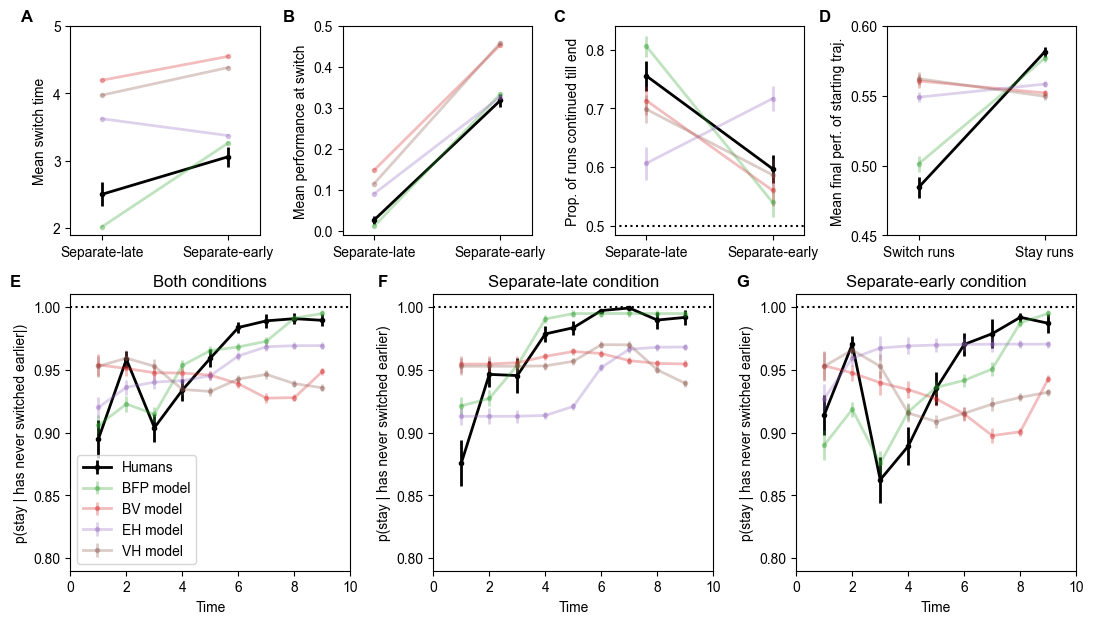

In [56]:
# Figure 6: Experiment 3 results, models fitted with logistic offset
linewidth=1.5
alpha_val = 0.3
model_names_full = ["BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]

# Load the human dataset
filename = "exp3_data"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
data = b['data']
traj_params = b["traj_params"]
traj_finalheights = b["counterfactual_traj_finalheights"]
(n_conds,n_subj,n_runs,n_timesteps,_) = data.shape

# Load the fake datasets
filename = os.path.join(data_path, "exp3_fits_fakedata_allmodels")
with open(filename+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
models_true_gen_params = b['true_gen_params']
models_fakedata = b['models_fakedata']

model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
#model_names = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic","Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic"]
model_names = ["BFP model","BV model", "EH model","VH model","BFP model","BV model", "EH model","VH model"]
cond_names = ["Separate-late","Separate-early"]


# Visualization
linewidth=2
alpha_val = 0.3

(last_free_timesteps_allsubjmean, subjs_didswitch_bothconds) = visualize_switchtimes(data, is_plot=False, is_save=False)
result = ttest_rel(last_free_timesteps_allsubjmean[0,:], last_free_timesteps_allsubjmean[1,:], nan_policy="omit")
print("Paired t-test, mean switch time: p={0}, 95% CI=[{1},{2}]".format(result.pvalue, np.round(result.confidence_interval()[0],5), np.round(result.confidence_interval()[1],5)))

(last_free_trajheights_allsubjmean, subjs_didswitch_bothconds) = visualize_switchheights(data, is_plot=False, is_save=False)
result = ttest_rel(last_free_trajheights_allsubjmean[0,:], last_free_trajheights_allsubjmean[1,:], nan_policy="omit")
print("Paired t-test, mean switch height: p={0}, 95% CI=[{1},{2}]".format(result.pvalue, np.round(result.confidence_interval()[0],5), np.round(result.confidence_interval()[1],5)))

p_continuetillends_subjmean = prop_runs_continuedtillend(data)
result = ttest_rel(p_continuetillends_subjmean[0,:], p_continuetillends_subjmean[1,:], nan_policy="omit")
print("Paired t-test, %runs stayed till end: p={0}, 95% CI=[{1},{2}]".format(result.pvalue, np.round(result.confidence_interval()[0],5), np.round(result.confidence_interval()[1],5)))

(stayswitched_trials_trajfinalheight_allsubjmean, subjs_didswitch_eithercond) = startingtraj_finalheights(data, is_plot=False, is_save=False)
result = ttest_rel(stayswitched_trials_trajfinalheight_allsubjmean[0,:], stayswitched_trials_trajfinalheight_allsubjmean[1,:], nan_policy="omit")
print("Paired t-test, start traj's final height in stayed vs. switched runs : p={0}, 95% CI=[{1},{2}]".format(result.pvalue, np.round(result.confidence_interval()[0],5), np.round(result.confidence_interval()[1],5)))

print("Number of participants who have switched: ", np.sum(subjs_didswitch_eithercond))
print("Number of participants who have switched in both task conditions: ", np.sum(subjs_didswitch_bothconds))

print()


# Visualize all
layout = [
    ["A", "A","A", "B", "B","B", "C", "C","C", "D","D","D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["A", "A","A", "B", "B","B", "C", "C","C", "D","D","D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["A", "A","A", "B", "B","B", "C", "C","C", "D","D","D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["A", "A","A", "B", "B","B", "C", "C","C", "D","D","D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
]

fig, ax = plt.subplot_mosaic(layout, figsize=(11, 8.5/15*11))
plot_idx_raw = -1
for include_offset_params_target in [True]:
    
    # Switch height
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1),  np.std(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1)/np.sqrt(n_subj), color="k", fmt=".-", linewidth=linewidth, label="Human")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        (last_free_timesteps_allsubjmean_fakedata, subjs_didswitch_bothconds_fakedata) = visualize_switchtimes(fake_data, is_plot=False, is_save=False)
        ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_timesteps_allsubjmean_fakedata[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1),  np.std(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-", linewidth=linewidth, alpha=alpha_val, label=model_names[color_count])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_xlim([-0.25,1.25])
    ax[plot_idx].set_yticks([2,3,4,5])
    ax[plot_idx].set_xticklabels(cond_names)
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel("Mean switch time")
#     ax[plot_idx].set_title("include_logistic_offset="+str(include_offset_params_target))
#     ax[plot_idx].set_title("Diff in mean switch time btw. conds,  \n N_human={0}, Human paired t-test p={1}".format(np.sum(subjs_didswitch_bothconds), np.round(p_val, 6)))
    
    
    # Switch time
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_trajheights_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1),  np.std(np.squeeze(last_free_trajheights_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1)/np.sqrt(n_subj), color="k", fmt=".-", linewidth=linewidth, label="Human")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        (last_free_trajheights_allsubjmean_fakedata, subjs_didswitch_bothconds_fakedata) = visualize_switchheights(fake_data, is_plot=False, is_save=False)
        ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_trajheights_allsubjmean_fakedata[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1),  np.std(np.squeeze(last_free_trajheights_allsubjmean[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-",  linewidth=linewidth, alpha=alpha_val, label=model_names[color_count])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_xlim([-0.25,1.25])
    ax[plot_idx].set_yticks([0,0.1,0.2,0.3,0.4,0.5])
    ax[plot_idx].set_xticklabels(cond_names)
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel("Mean performance at switch")
#     ax[plot_idx].set_title("include_logistic_offset="+str(include_offset_params_target))
#     p_val = scipy.stats.ttest_rel(np.squeeze(last_free_trajheights_allsubjmean[0,np.where(subjs_didswitch_bothconds)]), np.squeeze(last_free_trajheights_allsubjmean[1,np.where(subjs_didswitch_bothconds)])).pvalue
#     ax[plot_idx].set_title("Diff in mean switch height btw. conds,  \n N_human={0}, Human paired t-test p={1}".format(np.sum(subjs_didswitch_bothconds), np.round(p_val, 6)))

    # P(continue till end)
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1],np.nanmean(p_continuetillends_subjmean,axis=1), yerr=np.nanstd(p_continuetillends_subjmean, ddof=1, axis=1)/np.sqrt(n_subj), color="k", fmt=".-", linewidth=linewidth, label="Human")
    ax[plot_idx].plot([-1,2],[0.5,0.5],"k:")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        p_continuetillends_subjmean_fakedata = prop_runs_continuedtillend(fake_data)
        ax[plot_idx].errorbar([0,1],np.nanmean(p_continuetillends_subjmean_fakedata,axis=1), yerr=np.nanstd(p_continuetillends_subjmean_fakedata, ddof=1, axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-",  linewidth=linewidth, alpha=alpha_val, label=model_names[color_count])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_yticks([0.5,0.6,0.7,0.8])
    ax[plot_idx].set_xlim([-0.25,1.25])
    ax[plot_idx].set_xticklabels(cond_names)
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel("Prop. of runs continued till end")
    
    
    # Sensitivity to final traj height
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean[:,np.where(subjs_didswitch_eithercond)]), axis=1),  np.std(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean[:,np.where(subjs_didswitch_eithercond)]), axis=1)/np.sqrt(n_subj), color="k", fmt=".-",  linewidth=linewidth, label="Human")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        (stayswitched_trials_trajfinalheight_allsubjmean_fakedata, subjs_didswitch_eithercond_fakedata) = startingtraj_finalheights(fake_data, is_plot=False, is_save=False)
        ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean_fakedata[:,np.where(subjs_didswitch_eithercond_fakedata)]), axis=1),  np.std(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean_fakedata[:,np.where(subjs_didswitch_eithercond_fakedata)]), axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-",  linewidth=linewidth, alpha=alpha_val, label=model_names[color_count])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_yticks([0.45,0.5,0.55,0.6])
    ax[plot_idx].set_xlim([-0.25,1.25])
    ax[plot_idx].set_xticklabels(["Switch runs","Stay runs"])
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel("Mean final perf. of starting traj.")
    
    
    
    
    # P(stay | stayed so far plots)
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    color_count=-1
    ax[plot_idx].errorbar(range(n_timesteps), np.squeeze(responses_meanoverrunssubjcond), yerr=np.squeeze(responses_semoverrunssubjcond), fmt="k.-", linewidth=linewidth, label="Humans")
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        include_offset_param = "_offset" in model_fullname
        model = model_fullname.rpartition('_')[0]
        if(include_offset_param!=include_offset_params_target):
            continue;
        print(model_fullname)
        color_count = color_count+1
        ax[plot_idx].errorbar(range(n_timesteps), p_stay_models_meanoverrunssubjcond[model_idx,:], yerr=p_stay_models_semoverrunssubjcond[0,:], fmt="C"+str(color_count+2)+".-", linewidth=linewidth, label=model_names[model_idx], alpha=alpha_val)

    ax[plot_idx].plot([0,n_timesteps],[1,1], "k:", alpha=1, label=None)
    ax[plot_idx].set_ylabel("p(stay | has never switched earlier|)")
    ax[plot_idx].set_xlabel("Time")
    ax[plot_idx].set_title("Both conditions")
    if(not include_offset_params_target):
        ax[plot_idx].set_ylim([0.48,1.01])
    else:
        ax[plot_idx].set_ylim([0.79,1.01])
        ax[plot_idx].set_yticks(np.arange(0.8,1.05,0.05))
    ax[plot_idx].set_xlim([0,10])

    for cond in range(n_conds):
        # Human p(stay) at every timestep, across conds
        plot_idx_raw = plot_idx_raw+1
        plot_idx = chr(plot_idx_raw + 65)
        color_count = -1
        ax[plot_idx].errorbar(range(n_timesteps), np.squeeze(responses_meanoverrunssubj[0,cond,:]), yerr=np.squeeze(responses_semoverrunssubj[0,cond,:]), fmt="k.-", linewidth=linewidth, label="Humans")
        for model_idx in range(len(model_fullnames)):
            model_fullname = model_fullnames[model_idx]
            include_offset_param = "_offset" in model_fullname
            model = model_fullname.rpartition('_')[0]
            if(include_offset_param!=include_offset_params_target):
                continue;
            color_count = color_count+1
            ax[plot_idx].errorbar(range(n_timesteps), p_stay_models_meanoverrunssubj[model_idx,cond,:], yerr=p_stay_models_semoverrunssubj[0,cond,:], fmt="C"+str(color_count+2)+".-", linewidth=linewidth, label=model_names[model_idx], alpha=alpha_val)

        ax[plot_idx].plot([0,n_timesteps],[1,1], "k:", alpha=1, label=None)
        if(not include_offset_params_target):
            ax[plot_idx].set_ylim([0.48,1.005])
        else:
            ax[plot_idx].set_ylim([0.79,1.01])
            ax[plot_idx].set_yticks(np.arange(0.8,1.05,0.05))
        #ax[cond+1].set_ylabel("p(stay)")
        ax[plot_idx].set_xlabel("Time")
        ax[plot_idx].set_xlim([0,10])
        ax[plot_idx].set_ylabel("p(stay | has never switched earlier)")
        ax[plot_idx].set_title(cond_names[cond]+ " condition")
    
fig.text(0.02,0.975, "A", fontsize=12, weight="bold")
fig.text(0.258,0.975, "B", fontsize=12, weight="bold")
fig.text(0.504,0.975, "C", fontsize=12, weight="bold")
fig.text(0.745,0.975, "D", fontsize=12, weight="bold")
fig.text(0.01,0.55, "E", fontsize=12, weight="bold")
fig.text(0.344,0.55, "F", fontsize=12, weight="bold")
fig.text(0.670,0.55, "G", fontsize=12, weight="bold")
ax["E"].legend()
fig.tight_layout()
plt.savefig(os.path.join(figpath,"Fig6.pdf"), format="pdf")
plt.show()

bayesian_postmean_nooffset
velocity_nooffset
exploitation_heuristic_nooffset
velocity_heuristic_nooffset


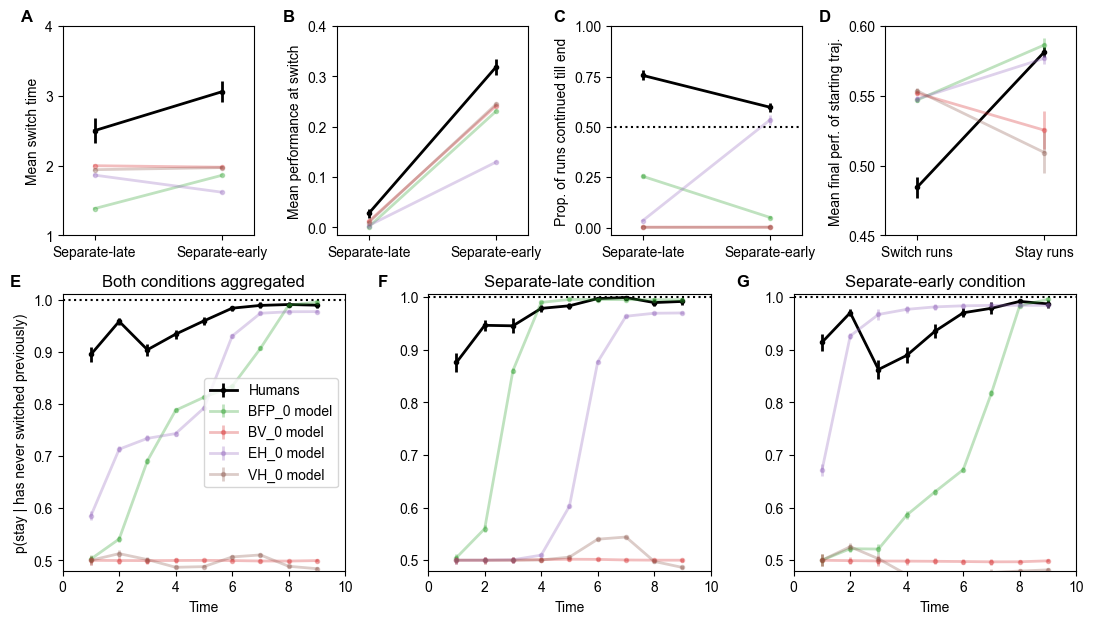

In [57]:
# Figure 7: Experiment 3 results, models fitted without logistic offset

# Load the human dataset
filename = "exp3_data"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
data = b['data']
traj_params = b["traj_params"]
traj_finalheights = b["counterfactual_traj_finalheights"]
(n_conds,n_subj,n_runs,n_timesteps,_) = data.shape

# Load the fake datasets
filename = os.path.join(data_path, "exp3_fits_fakedata_allmodels")
with open(filename+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
models_true_gen_params = b['true_gen_params']
models_fakedata = b['models_fakedata']

model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
#model_names = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic","Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic"]
model_names = ["BFP model","BV model", "EH model","VH model","BFP_0 model","BV_0 model", "EH_0 model","VH_0 model"]
cond_names = ["Separate-late","Separate-early"]


# Visualization
linewidth=2
alpha_val = 0.3

(last_free_timesteps_allsubjmean, subjs_didswitch_bothconds) = visualize_switchtimes(data, is_plot=False, is_save=False)
(last_free_trajheights_allsubjmean, subjs_didswitch_bothconds) = visualize_switchheights(data, is_plot=False, is_save=False)
p_continuetillends_subjmean = prop_runs_continuedtillend(data)
(stayswitched_trials_trajfinalheight_allsubjmean, subjs_didswitch_eithercond) = startingtraj_finalheights(data, is_plot=False, is_save=False)



# Visualize all
layout = [
    ["A", "A","A", "B", "B","B", "C", "C","C", "D","D","D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["A", "A","A", "B", "B","B", "C", "C","C", "D","D","D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["A", "A","A", "B", "B","B", "C", "C","C", "D","D","D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["A", "A","A", "B", "B","B", "C", "C","C", "D","D","D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
    ["E","E","E","E", "F","F","F","F", "G","G","G","G"],  # Row 2: C, D, and E are independent, "." leaves blank space
]

fig, ax = plt.subplot_mosaic(layout, figsize=(11, 8.5/15*11))
plot_idx_raw = -1
for include_offset_params_target in [False]:
    
    # Switch height
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1),  np.std(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1)/np.sqrt(n_subj), color="k", fmt=".-", linewidth=linewidth, label="Human")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        (last_free_timesteps_allsubjmean_fakedata, subjs_didswitch_bothconds_fakedata) = visualize_switchtimes(fake_data, is_plot=False, is_save=False)
        ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_timesteps_allsubjmean_fakedata[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1),  np.std(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-", linewidth=linewidth, alpha=alpha_val, label=model_names[color_count])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_xlim([-0.25,1.25])
    ax[plot_idx].set_yticks([1,2,3,4])
    ax[plot_idx].set_xticklabels(cond_names)
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel("Mean switch time")
#     ax[plot_idx].set_title("include_logistic_offset="+str(include_offset_params_target))
#     p_val = scipy.stats.ttest_rel(np.squeeze(last_free_timesteps_allsubjmean[0,np.where(subjs_didswitch_bothconds)]), np.squeeze(last_free_timesteps_allsubjmean[1,np.where(subjs_didswitch_bothconds)])).pvalue
#     ax[plot_idx].set_title("Diff in mean switch time btw. conds,  \n N_human={0}, Human paired t-test p={1}".format(np.sum(subjs_didswitch_bothconds), np.round(p_val, 6)))
    
    
    # Switch time
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_trajheights_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1),  np.std(np.squeeze(last_free_trajheights_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1)/np.sqrt(n_subj), color="k", fmt=".-", linewidth=linewidth, label="Human")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        (last_free_trajheights_allsubjmean_fakedata, subjs_didswitch_bothconds_fakedata) = visualize_switchheights(fake_data, is_plot=False, is_save=False)
        ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_trajheights_allsubjmean_fakedata[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1),  np.std(np.squeeze(last_free_trajheights_allsubjmean[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-",  linewidth=linewidth, alpha=alpha_val, label=model_names[color_count])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_xlim([-0.25,1.25])
    ax[plot_idx].set_yticks([0,0.1,0.2,0.3,0.4])
    ax[plot_idx].set_xticklabels(cond_names)
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel("Mean performance at switch")
#     ax[plot_idx].set_title("include_logistic_offset="+str(include_offset_params_target))
#     p_val = scipy.stats.ttest_rel(np.squeeze(last_free_trajheights_allsubjmean[0,np.where(subjs_didswitch_bothconds)]), np.squeeze(last_free_trajheights_allsubjmean[1,np.where(subjs_didswitch_bothconds)])).pvalue
#     ax[plot_idx].set_title("Diff in mean switch height btw. conds,  \n N_human={0}, Human paired t-test p={1}".format(np.sum(subjs_didswitch_bothconds), np.round(p_val, 6)))

    # P(continue till end)
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1],np.nanmean(p_continuetillends_subjmean,axis=1), yerr=np.nanstd(p_continuetillends_subjmean, ddof=1, axis=1)/np.sqrt(n_subj), color="k", fmt=".-", linewidth=linewidth, label="Human")
    ax[plot_idx].plot([-1,2],[0.5,0.5],"k:")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        p_continuetillends_subjmean_fakedata = prop_runs_continuedtillend(fake_data)
        ax[plot_idx].errorbar([0,1],np.nanmean(p_continuetillends_subjmean_fakedata,axis=1), yerr=np.nanstd(p_continuetillends_subjmean_fakedata, ddof=1, axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-",  linewidth=linewidth, alpha=alpha_val, label=model_names[color_count])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_yticks([0,0.25,0.5,0.75,1])
    ax[plot_idx].set_xlim([-0.25,1.25])
    ax[plot_idx].set_xticklabels(cond_names)
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel("Prop. of runs continued till end")
    
    
    # Sensitivity to final traj height
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean[:,np.where(subjs_didswitch_eithercond)]), axis=1),  np.std(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean[:,np.where(subjs_didswitch_eithercond)]), axis=1)/np.sqrt(n_subj), color="k", fmt=".-",  linewidth=linewidth, label="Human")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        (stayswitched_trials_trajfinalheight_allsubjmean_fakedata, subjs_didswitch_eithercond_fakedata) = startingtraj_finalheights(fake_data, is_plot=False, is_save=False)
        ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean_fakedata[:,np.where(subjs_didswitch_eithercond_fakedata)]), axis=1),  np.std(np.squeeze(stayswitched_trials_trajfinalheight_allsubjmean_fakedata[:,np.where(subjs_didswitch_eithercond_fakedata)]), axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-",  linewidth=linewidth, alpha=alpha_val, label=model_names[color_count])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_yticks([0.45,0.5,0.55,0.6])
    ax[plot_idx].set_xlim([-0.25,1.25])
    ax[plot_idx].set_xticklabels(["Switch runs","Stay runs"])
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel("Mean final perf. of starting traj.")
    
    
    
    
    # P(stay | stayed so far plots)
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    color_count=-1
    ax[plot_idx].errorbar(range(n_timesteps), np.squeeze(responses_meanoverrunssubjcond), yerr=np.squeeze(responses_semoverrunssubjcond), fmt="k.-", linewidth=linewidth, label="Humans")
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        include_offset_param = "_offset" in model_fullname
        model = model_fullname.rpartition('_')[0]
        if(include_offset_param!=include_offset_params_target):
            continue;
        print(model_fullname)
        color_count = color_count+1
        ax[plot_idx].errorbar(range(n_timesteps), p_stay_models_meanoverrunssubjcond[model_idx,:], yerr=p_stay_models_semoverrunssubjcond[0,:], fmt="C"+str(color_count+2)+".-", linewidth=linewidth, label=model_names[model_idx], alpha=alpha_val)

    ax[plot_idx].plot([0,n_timesteps],[1,1], "k:", alpha=1, label=None)
    ax[plot_idx].set_ylabel("p(stay | has never switched previously)")
    ax[plot_idx].set_xlabel("Time")
    ax[plot_idx].set_title("Both conditions aggregated")
    if(not include_offset_params_target):
        ax[plot_idx].set_ylim([0.48,1.01])
    else:
        ax[plot_idx].set_ylim([0.79,1.01])
        ax[plot_idx].set_yticks(np.arange(0.8,1.05,0.05))
    ax[plot_idx].set_xlim([0,10])

    for cond in range(n_conds):
        # Human p(stay) at every timestep, across conds
        plot_idx_raw = plot_idx_raw+1
        plot_idx = chr(plot_idx_raw + 65)
        color_count = -1
        ax[plot_idx].errorbar(range(n_timesteps), np.squeeze(responses_meanoverrunssubj[0,cond,:]), yerr=np.squeeze(responses_semoverrunssubj[0,cond,:]), fmt="k.-", linewidth=linewidth, label="Humans")
        for model_idx in range(len(model_fullnames)):
            model_fullname = model_fullnames[model_idx]
            include_offset_param = "_offset" in model_fullname
            model = model_fullname.rpartition('_')[0]
            if(include_offset_param!=include_offset_params_target):
                continue;
            color_count = color_count+1
            ax[plot_idx].errorbar(range(n_timesteps), p_stay_models_meanoverrunssubj[model_idx,cond,:], yerr=p_stay_models_semoverrunssubj[0,cond,:], fmt="C"+str(color_count+2)+".-", linewidth=linewidth, label=model_names[model_idx], alpha=alpha_val)

        ax[plot_idx].plot([0,n_timesteps],[1,1], "k:", alpha=1, label=None)
        if(not include_offset_params_target):
            ax[plot_idx].set_ylim([0.48,1.005])
        else:
            ax[plot_idx].set_ylim([0.79,1.01])
            ax[plot_idx].set_yticks(np.arange(0.8,1.05,0.05))
        #ax[cond+1].set_ylabel("p(stay)")
        ax[plot_idx].set_xlabel("Time")
        ax[plot_idx].set_xlim([0,10])
        ax[plot_idx].set_title(cond_names[cond]+ " condition")
    
fig.text(0.02,0.975, "A", fontsize=12, weight="bold")
fig.text(0.258,0.975, "B", fontsize=12, weight="bold")
fig.text(0.504,0.975, "C", fontsize=12, weight="bold")
fig.text(0.745,0.975, "D", fontsize=12, weight="bold")
fig.text(0.01,0.55, "E", fontsize=12, weight="bold")
fig.text(0.344,0.55, "F", fontsize=12, weight="bold")
fig.text(0.670,0.55, "G", fontsize=12, weight="bold")
ax["E"].legend()
fig.tight_layout()
plt.savefig(os.path.join(figpath,"Fig7.pdf"), format="pdf")
plt.show()

Paired t-test, bayesian_postmean vs velocity_offset: p=0.0, 95% CI=[-5.37873,-2.2984]
Paired t-test, bayesian_postmean vs exploitation_heuristic_offset: p=1e-05, 95% CI=[-5.06515,-2.07253]
Paired t-test, bayesian_postmean vs velocity_heuristic_offset: p=0.0, 95% CI=[-5.41738,-2.31256]
Paired t-test, bayesian_postmean vs bayesian_postmean_nooffset: p=0.0, 95% CI=[-32.02972,-25.85769]
Paired t-test, bayesian_postmean vs velocity_nooffset: p=0.0, 95% CI=[-83.16558,-71.83741]
Paired t-test, bayesian_postmean vs exploitation_heuristic_nooffset: p=0.0, 95% CI=[-29.16864,-23.19585]
Paired t-test, bayesian_postmean vs velocity_heuristic_nooffset: p=0.0, 95% CI=[-82.94811,-71.56791]


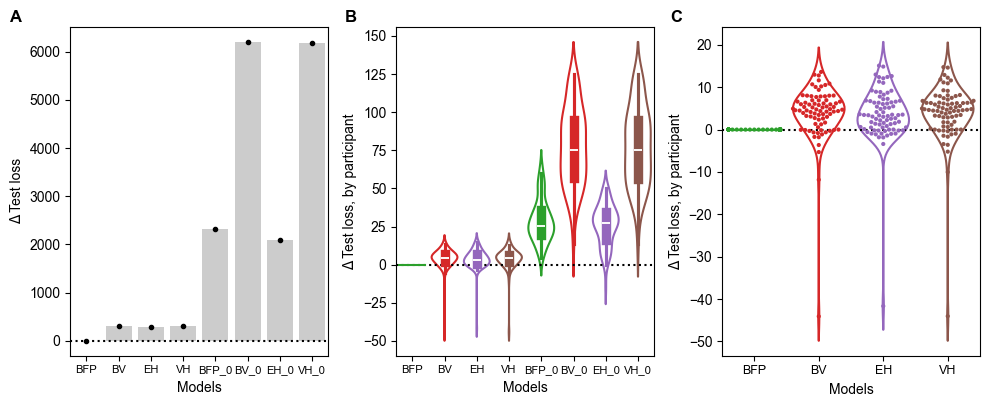

In [58]:
model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
#model_names_full = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic","Bayesian final height 0","Bayesian velocity 0", "Exploitation heuristic 0","Velocity heuristic 0"]
model_names_full = ["BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]

#colors = {"Bayesian final height":"C2","Bayesian velocity":"C3", "Exploitation heuristic":"C4","Velocity heuristic":"C5","Bayesian final height 0":"C2","Bayesian velocity 0":"C3", "Exploitation heuristic 0":"C4","Velocity heuristic 0":"C5"}
colors = {"BFP":"C2","BV":"C3", "EH":"C4","VH":"C5","BFP_0":"C2","BV_0":"C3", "EH_0":"C4","VH_0":"C5"}


#df = pd.DataFrame(crossentropy_cv_bysubj, columns=model_names_full)
# fig,ax = plt.subplots(1,2,figsize=(8,5))
fig,ax = plt.subplots(1,3,figsize=(10,4))

# Experiment 3
# 1) Load CV results
filename = "exp3_cv_testlosses"
with open(os.path.join(fits_path,filename) + '.pickle', 'rb') as handle:
    b = pickle.load(handle)
    crossentropy_cv_test = b["crossentropy_cv_test"]
    model_fullnames = b["model_fullnames"]
# 2) Average over folds for each subject, then sum over subjects.
crossentropy_cv_bysubj = np.nanmean(crossentropy_cv_test, axis=2)
crossentropy_cv = np.nansum(crossentropy_cv_bysubj, axis=0)
crossentropy_cv_sem = np.nanstd(crossentropy_cv_bysubj, ddof=1, axis=0) / np.sqrt(n_subj) # Errorbars are subject SEM
# 3) Paired t-test
for model_idx in range(1,len(model_fullnames)):
    result = scipy.stats.ttest_rel(crossentropy_cv_bysubj[:,0], crossentropy_cv_bysubj[:,model_idx], alternative="two-sided")
    print("Paired t-test, bayesian_postmean vs "+model_fullnames[model_idx]+": p={0}, 95% CI=[{1},{2}]".format(np.round(result.pvalue,5), np.round(result.confidence_interval()[0],5), np.round(result.confidence_interval()[1],5)))
#     t_stat, p_value = scipy.stats.wilcoxon(crossentropy_cv_bysubj[:,0], crossentropy_cv_bysubj[:,model_idx], alternative="two-sided")
#     print("Wilcoxon signed-rank test, bayesian_postmean vs "+model_fullnames[model_idx]+": p={0}".format(p_value))
# 4) Visualize
ax[0].bar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), color="k", alpha=0.2)
yerr = crossentropy_cv_sem
ax[0].errorbar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), yerr=yerr, fmt='k.')
ax[0].plot([-0.5,len(model_fullnames)-1+0.5],[0,0],"k:")
ax[0].set_xlim([-0.5,len(model_fullnames)-1+0.5])
#ax[0].set_ylabel("Δ Cross entropy on test dataset, fold-averaged")
ax[0].set_xlabel("Models")
ax[0].set_xticks(range(len(model_fullnames)))
ax[0].set_xticklabels(model_names_full, fontsize=8)
ax[0].tick_params(axis='x', labelrotation=0) 
ax[0].set_ylabel("Δ Test loss")
#ax.set_title(str(n_folds)+"-fold cross validation: test loss")


df = pd.DataFrame(crossentropy_cv_bysubj-crossentropy_cv_bysubj[:,0:1], columns=model_names_full)
ax[1].plot([-0.5,8.5],[0,0],"k:",alpha=1)
#sns.swarmplot(ax=ax[0], data=df, s=3)
sns.violinplot(ax=ax[1], data=df, fill=False, palette=colors)
ax[1].tick_params(axis='x', labelrotation=0) 
ax[1].tick_params(axis='x', labelsize=8)
ax[1].set_ylabel("Δ Test loss, by participant")
ax[1].set_xlabel("Models")

ax[2].plot([-0.5,4.5],[0,0],"k:",alpha=1)
sns.swarmplot(ax=ax[2], data=df.iloc[:,0:4], s=3, palette=colors)
sns.violinplot(ax=ax[2], data=df.iloc[:,0:4], fill=False, inner=None, palette=colors)
ax[2].tick_params(axis='x', labelrotation=0) 
ax[2].tick_params(axis='x', labelsize=9)
ax[2].set_ylabel("Δ Test loss, by participant")
ax[2].set_xlabel("Models")


fig.text(0.015,0.975, "A", fontsize=12, weight="bold")
fig.text(0.35,0.975, "B", fontsize=12, weight="bold")
fig.text(0.675,0.975, "C", fontsize=12, weight="bold")

fig.tight_layout()
plt.savefig(os.path.join(figpath,"Fig8.pdf"), format="pdf")
plt.show()

dict_keys(['true_gen_params', 'models_fakedata_probstay', 'mturk_IDs', 'data_dims', 'models_fakedata'])
humans
bayesian_postmean_offset
velocity_offset
exploitation_heuristic_offset
velocity_heuristic_offset


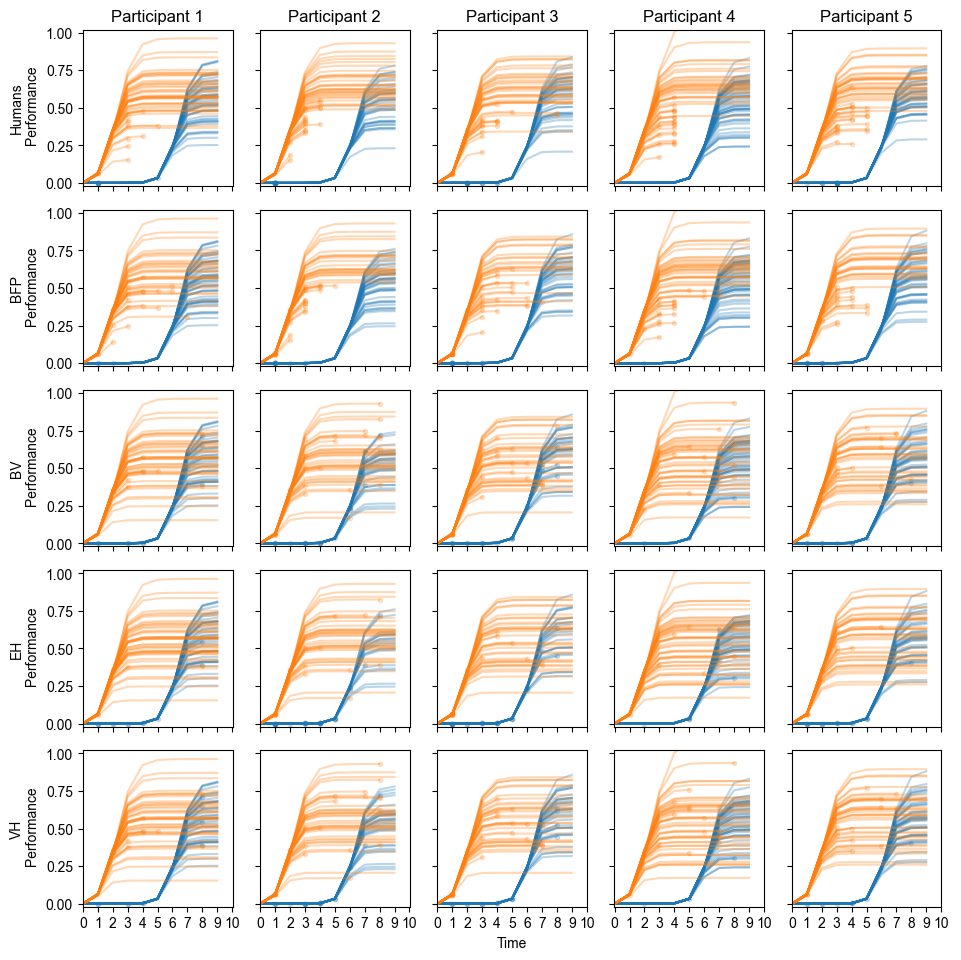

In [59]:
# Figure 10: visualize fake datasets

# Load the human dataset
filename = "exp3_data"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
data = b['data']

# Load the fake datasets for all models
filename = "exp3_fits_fakedata_allmodels"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
print(b.keys())  
models_true_gen_params = b['true_gen_params']
models_fakedata = b['models_fakedata']
models_fakedata["humans"] = data


# Visualization of trajectories seen.
#model_fullnames = ["humans", "bayesian_postmean_offset","bayesian_postmean_nooffset"]
#model_fullnames = ["humans", "bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
model_fullnames = ["humans", "bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset"]
n_subj_visualized = 5

n_rows=len(model_fullnames)
n_cols=n_subj_visualized
fig, ax = plt.subplots(n_rows, n_cols,figsize=(10,10))

# model_names = ["Humans", "Bayesian final height","Bayesian final height 0"]
model_names = ["Humans","BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]
row_count = -1
for model_fullname in model_fullnames:
    print(model_fullname)
    row_count = row_count+1
    
    include_offset_param_vals = "_offset" in model_fullname
    models = model_fullname.rpartition('_')[0]
    
    p_continuetillends_subjmean = np.zeros((n_conds, n_subj))
    fake_data = models_fakedata[model_fullname]
    for subj in range(n_subj_visualized):
        hasswitched_subj_conds = np.zeros((n_conds, n_runs))
        for cond in range(n_conds):
            traj_heights = fake_data[cond,subj,:,:,0]
            last_free_timestep = np.isnan(traj_heights).argmax(axis=1)-1
            for run in range(n_runs):
                ax[row_count, subj%n_cols].plot(range(T_end), traj_heights[run,:], "-", color="C"+str(cond), alpha=0.3)
                ax[row_count, subj%n_cols].plot(last_free_timestep[run], np.transpose(traj_heights[run, last_free_timestep[run]]), ".", color="C"+str(cond), alpha=0.2)


        ax[0, subj%n_cols].set_title("Participant "+str(subj+1))
        ax[row_count,0].set_ylabel(model_names[row_count]+"\n Performance")
        ax[row_count, subj%n_cols].set_xticks(range(0,T_end+1))

        if(subj%n_cols!=0):
            ax[row_count, subj%n_cols].set_yticklabels([])
        if(subj<n_cols*(n_rows-1)):
            ax[row_count, subj%n_cols].set_xticklabels([])
        if(row_count==n_rows-1):
            ax[row_count, subj%n_cols].set_xticklabels(range(0,T_end+1))
        ax[row_count, subj%n_cols].set_ylim([-0.02,1.02])
        ax[row_count, subj%n_cols].set_xlim([-0.02,10.02])

# add a big axis, hide frame
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Time")
fig.tight_layout()
plt.savefig(os.path.join(figpath,"Fig_exp3_indvdata.pdf"), format="pdf")
plt.show()

dict_keys(['true_gen_params', 'models_fakedata_probstay', 'mturk_IDs', 'data_dims', 'models_fakedata'])
humans
bayesian_postmean_nooffset
velocity_nooffset
exploitation_heuristic_nooffset
velocity_heuristic_nooffset


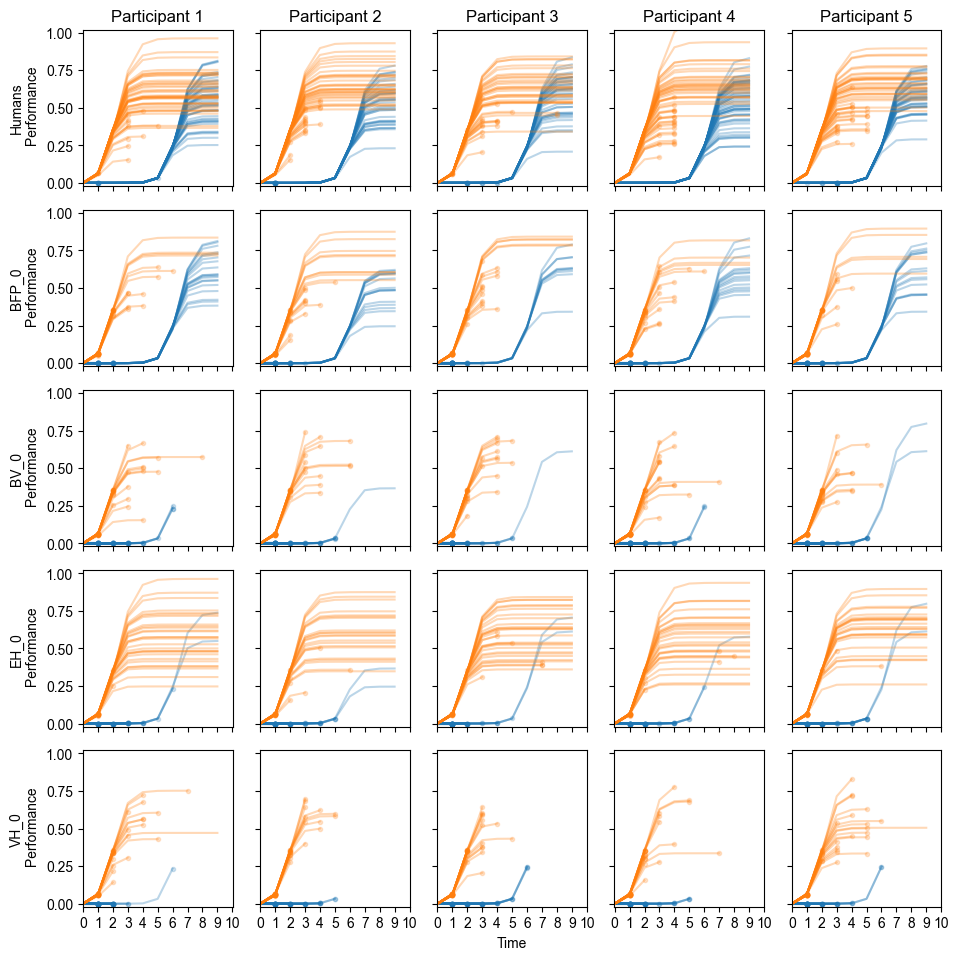

In [60]:
# Figure 10: visualize fake datasets

# Load the human dataset
filename = "exp3_data"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
data = b['data']

# Load the fake datasets for all models
filename = "exp3_fits_fakedata_allmodels"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
print(b.keys())  
models_true_gen_params = b['true_gen_params']
models_fakedata = b['models_fakedata']
models_fakedata["humans"] = data


# Visualization of trajectories seen.
#model_fullnames = ["humans", "bayesian_postmean_offset","bayesian_postmean_nooffset"]
#model_fullnames = ["humans", "bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
model_fullnames = ["humans", "bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
n_subj_visualized = 5

n_rows=len(model_fullnames)
n_cols=n_subj_visualized
fig, ax = plt.subplots(n_rows, n_cols,figsize=(10,10))

# model_names = ["Humans", "Bayesian final height","Bayesian final height 0"]
model_names = ["Humans","BFP_0","BV_0", "EH_0","VH_0"]
row_count = -1
for model_fullname in model_fullnames:
    print(model_fullname)
    row_count = row_count+1
    
    include_offset_param_vals = "_offset" in model_fullname
    models = model_fullname.rpartition('_')[0]
    
    p_continuetillends_subjmean = np.zeros((n_conds, n_subj))
    fake_data = models_fakedata[model_fullname]
    for subj in range(n_subj_visualized):
        hasswitched_subj_conds = np.zeros((n_conds, n_runs))
        for cond in range(n_conds):
            traj_heights = fake_data[cond,subj,:,:,0]
            last_free_timestep = np.isnan(traj_heights).argmax(axis=1)-1
            for run in range(n_runs):
                ax[row_count, subj%n_cols].plot(range(T_end), traj_heights[run,:], "-", color="C"+str(cond), alpha=0.3)
                ax[row_count, subj%n_cols].plot(last_free_timestep[run], np.transpose(traj_heights[run, last_free_timestep[run]]), ".", color="C"+str(cond), alpha=0.2)


        ax[0, subj%n_cols].set_title("Participant "+str(subj+1))
        ax[row_count,0].set_ylabel(model_names[row_count]+"\n Performance")
        ax[row_count, subj%n_cols].set_xticks(range(0,T_end+1))

        if(subj%n_cols!=0):
            ax[row_count, subj%n_cols].set_yticklabels([])
        if(subj<n_cols*(n_rows-1)):
            ax[row_count, subj%n_cols].set_xticklabels([])
        if(row_count==n_rows-1):
            ax[row_count, subj%n_cols].set_xticklabels(range(0,T_end+1))
        ax[row_count, subj%n_cols].set_ylim([-0.02,1.02])
        ax[row_count, subj%n_cols].set_xlim([-0.02,10.02])

# add a big axis, hide frame
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Time")
fig.tight_layout()
plt.savefig(os.path.join(figpath,"Fig_exp3_indvdata_2.pdf"), format="pdf")
plt.show()

# Experiment 4

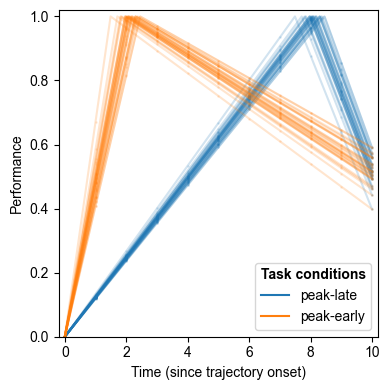

In [61]:
# Experiment 3
dt=0.01  #1
ts = np.arange(0,10+dt,dt)[:,None]
ts_integer = np.arange(0,10+dt,1)[:,None]
piecewise_curve = lambda t, theta: (theta[:,0] + theta[:,1]*t)*(t<=(1/theta[:,1])) + ((1-theta[:,2])/(1/theta[:,1]-10)*t + (1/theta[:,1]*theta[:,2]-10)/(1/theta[:,1]-10) )*(t>(1/theta[:,1]))

def piecewise_group(ts, traj_assymtotes, left_offset):
    '''Here, theta is a num_thetas x 1 vector, 
    corresponding to theta[:,1] required by the lambda function logistic_growth().'''
    num_thetas,_ = traj_assymtotes.shape
    new_theta = np.zeros((num_thetas,4))
    new_theta[:,0] = 0 # Starting height
    new_theta[:,1] = 1/(left_offset+np.squeeze(traj_assymtotes)) # Increasing portion slope
    new_theta[:,2] = 0.5+0.2*np.squeeze(traj_assymtotes)  # Slope
    return piecewise_curve(ts, new_theta)

# Group-level parameters for each family
theta_mean = 0
theta_nu = 0.2
condition_left_offsets = np.array([8, 2]) # Offsets for the seplate and sepearly conditions.


# 2) Actual data
num_thetas = 30
theta_dims = 4
np.random.seed(0)
thetas = np.random.normal(loc=theta_mean, scale=theta_nu, size=(num_thetas,1))
trajs_0 = piecewise_group(ts, thetas, condition_left_offsets[0])
trajs_1 = piecewise_group(ts, thetas, condition_left_offsets[1])
trajs_0_integer = piecewise_group(ts_integer, thetas, condition_left_offsets[0])
trajs_1_integer = piecewise_group(ts_integer, thetas, condition_left_offsets[1])
trajs = np.array([trajs_0, trajs_1])
trajs_integer = np.array([trajs_0_integer, trajs_1_integer])

fig, ax = plt.subplots(1,1, figsize=(4,4))
plt.plot(ts,trajs_0,"C0-", alpha=0.2)
plt.plot(ts,trajs_1,"C1-", alpha=0.2)
plt.plot(ts_integer,trajs_0_integer,"C0.", markersize=2, alpha=0.1)
plt.plot(ts_integer,trajs_1_integer,"C1.", markersize=2, alpha=0.1)
ax.set_xlabel("Time (since trajectory onset)")
ax.set_ylabel("Performance")
ax.set_ylim([0,1.02])
ax.set_xlim([-0.2,10.2])

from matplotlib.lines import Line2D
legend_line0 = Line2D([0], [0], color='C0')  # Use the color of your choice
legend_line1 = Line2D([0], [0], color='C1')  # Use the color of your choice
plt.legend([legend_line0,legend_line1], ["peak-late","peak-early"],title="Task conditions", title_fontproperties={'weight': 'bold'}, frameon=True)  # Single entry for the legend


plt.tight_layout()
plt.savefig(os.path.join(figpath,"Fig9_partial.pdf"), format="pdf")
plt.show()

thetas_support = thetas
num_thetas = len(thetas_support)

In [68]:
# load the files, given that it is so slow.
model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]


filename = "exp4_modelfits_logisticpredprobs"
with open(os.path.join(fits_path,filename) + '.pickle', 'rb') as handle:
    a = pickle.load(handle)
responses_allsubj = a["responses_allsubj"]
model_prob_preds_allsubj = a["model_prob_preds_allsubj"]
stayswitchdiff_allsubj = a["stayswitchdiff_allsubj"]
accuracy_subjs = a["accuracy_subjs"]
_, n_conds, n_subj, n_runs, n_timesteps = responses_allsubj.shape

responses_subjs_meanoverruns = np.zeros((n_subj, n_conds, n_timesteps)) # [subj, cond, n_timesteps]
responses_semoverrunssubj = np.zeros((1, n_conds, n_timesteps)) # [subj, n_timesteps]
for subj in range(n_subj):
    responses_subj = responses_allsubj[0,:,subj,:,:] # [cond, n_runs, n_timesteps]
    responses_subjs_meanoverruns[subj,:,:] = np.nanmean(responses_subj, axis=1) # [subj, cond, n_timesteps]; avg over runs
responses_meanoverrunscond = np.nanmean(responses_subjs_meanoverruns, axis=1) # [subj,n_timesteps]; avg over conds; allowed because each cond has same n_runs
responses_meanoverrunssubjcond = np.nanmean(responses_meanoverrunscond, axis=0)[None,:] # [1,n_timesteps]; avg over subjs
#responses_semoverrunssubjcond = np.nanstd(responses_meanoverrunscond, axis=0, ddof=1)[None,:]/np.sqrt(n_subj) # [1,n_timesteps]; sem over subjs
responses_semoverrunssubjcond = np.nanstd(responses_meanoverrunscond, axis=0, ddof=1)[None,:]/np.sqrt(np.sum(np.max(1-np.isnan(responses_subjs_meanoverruns),axis=1), axis=0)) # [1,n_timesteps]; sem over subjs

responses_meanoverrunssubj = np.nanmean(responses_subjs_meanoverruns, axis=0)[None,:] # [1,cond,n_timesteps]; avg over subjs
#responses_semoverrunssubj[0,0,:] = np.nanstd(responses_subjs_meanoverruns[:,0,:], axis=0, ddof=1)[None,:]/np.sqrt(n_subj) #[1,cond,timestep]; avg over subjs for seplate
responses_semoverrunssubj[0,0,:] = np.nanstd(responses_subjs_meanoverruns[:,0,:], axis=0, ddof=1)[None,:] / np.sqrt(np.sum(1-np.isnan(responses_subjs_meanoverruns[:,0,:]), axis=0)) #/np.sqrt(n_subj) #[1,cond,timestep]; avg over subjs for sepearly

#responses_semoverrunssubj[0,1,:] = np.nanstd(responses_subjs_meanoverruns[:,1,:], axis=0, ddof=1)[None,:] /np.sqrt(n_subj) #[1,cond,timestep]; avg over subjs for sepearly
responses_semoverrunssubj[0,1,:] = np.nanstd(responses_subjs_meanoverruns[:,1,:], axis=0, ddof=1)[None,:] / np.sqrt(np.sum(1-np.isnan(responses_subjs_meanoverruns[:,1,:]), axis=0)) #/np.sqrt(n_subj) #[1,cond,timestep]; avg over subjs for sepearly


p_stay_models_meanoverruns = np.zeros((len(model_fullnames), n_subj, n_conds, n_timesteps)) # [model, subj, cond, n_timesteps]
p_stay_models_meanoverrunssubj = np.zeros((len(model_fullnames), n_conds, n_timesteps))
p_stay_models_semoverrunssubj = np.zeros((len(model_fullnames), n_conds, n_timesteps))
p_stay_models_meanoverrunssubjcond = np.zeros((len(model_fullnames),n_timesteps))
p_stay_models_semoverrunssubjcond = np.zeros((len(model_fullnames), n_timesteps)) # [subj, n_timesteps]
for model_idx in range(len(model_fullnames)):
    model_fullname = model_fullnames[model_idx]
    print(model_fullname)
    include_offset_param = "_offset" in model_fullname
    model = model_fullname.rpartition('_')[0]
    p_stay_model = model_prob_preds_allsubj[model_idx,:,:,:,:] # [cond, subj, runs, timesteps]
    
    for subj in range(n_subj):
        p_stay_model_subj = p_stay_model[:,subj,:,:] # [cond, n_runs, n_timesteps]
        p_stay_models_meanoverruns[model_idx, subj,:,:] = np.nanmean(p_stay_model_subj, axis=1) # [model, subj, cond, n_timesteps]
        #p_stay_models_semoverrunssubj[model_idx,:] = np.std(p_stay_models_meanoverruns[model_idx,:,:,:], axis=0, ddof=1)[None,:]/np.sqrt(n_subj) # [1,cond,n_timesteps]
    p_stay_models_meanoverrunscond = np.nanmean(p_stay_models_meanoverruns[model_idx,:,:,:], axis=1) # [n_subj, n_timesteps]; avg over cond; allowed because each cond has same n_runs
    p_stay_models_meanoverrunssubjcond[model_idx,:] = np.nanmean(p_stay_models_meanoverrunscond, axis=0) # [model, n_timesteps]; avg over conds
    p_stay_models_semoverrunssubjcond[model_idx,:] = np.nanstd(p_stay_models_meanoverrunscond, axis=0, ddof=1)[None,:]/np.sqrt(n_subj) # [1,n_timesteps]

    p_stay_models_meanoverrunssubj[model_idx,:] = np.nanmean(p_stay_models_meanoverruns[model_idx,:,:,:], axis=0) # [model, cond, n_timesteps]; avg over subjs
    p_stay_models_semoverrunssubj[model_idx,0,:] = np.nanstd(p_stay_models_meanoverruns[model_idx,:,0,:], axis=0, ddof=1)[None,:]/np.sqrt(n_subj) #[1,subj,cond,timestep]; avg over subjs for seplate
    p_stay_models_semoverrunssubj[model_idx,1,:] = np.nanstd(p_stay_models_meanoverruns[model_idx,:,1,:], axis=0, ddof=1)[None,:]/np.sqrt(n_subj) #[1,subj,cond,timestep]; avg over subjs for sepearly
#print(p_stay_models_meanoverrunssubjcond)

print("\n#Subjects in each timepoint's errorbar:")
print(np.sum(np.max(1-np.isnan(responses_subjs_meanoverruns),axis=1), axis=0))
print()
print(np.sum(1-np.isnan(responses_subjs_meanoverruns), axis=0))

bayesian_postmean_offset
velocity_offset
exploitation_heuristic_offset
velocity_heuristic_offset
bayesian_postmean_nooffset
velocity_nooffset
exploitation_heuristic_nooffset
velocity_heuristic_nooffset

#Subjects in each timepoint's errorbar:
[ 0 80 79 79 78 77 76 75 74 37]

[[ 0 80 79 60 44 33 27 26 25 23]
 [ 0 80 79 79 78 77 76 74 73 26]]


Paired t-test, mean switch time: p=9.06701281910896e-21, 95% CI=[-4.57629,-3.35408]
Number of participants who have switched in both task conditions:  76

bayesian_postmean_offset
velocity_offset
exploitation_heuristic_offset
velocity_heuristic_offset
bayesian_postmean_nooffset
velocity_nooffset
exploitation_heuristic_nooffset
velocity_heuristic_nooffset


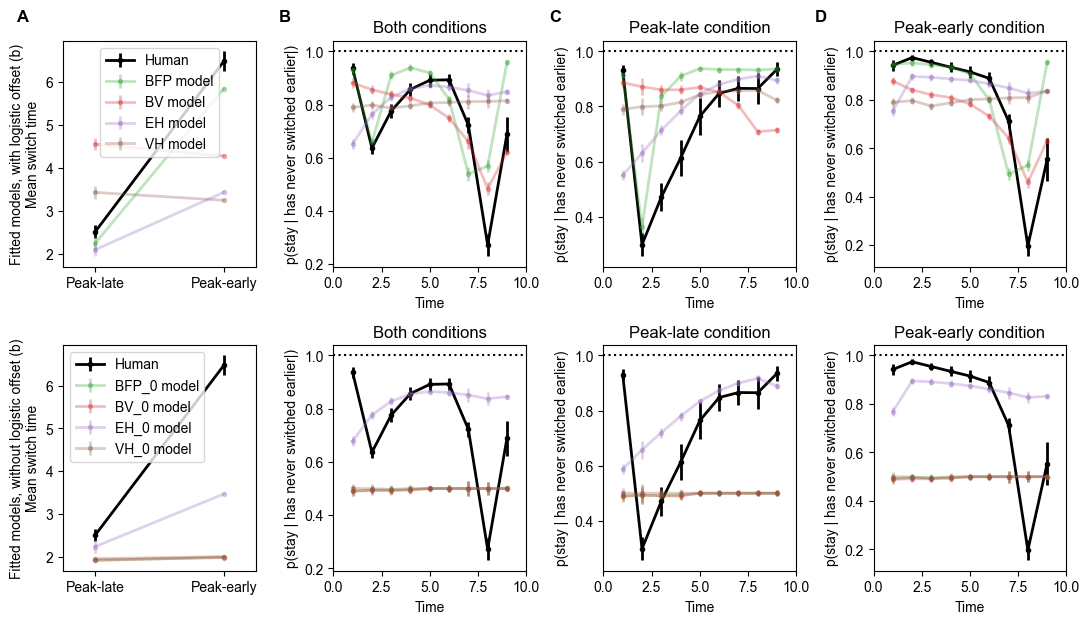

In [69]:
# Figure 6: Experiment 4 results, models fitted with logistic offset
linewidth=1.5
alpha_val = 0.3
model_names_full = ["BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]
model_types = ["Fitted models, with logistic offset (b)","Fitted models, without logistic offset (b)"]

# Load the human dataset
filename = "exp4_data"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
data = b['data']
traj_params = b["traj_params"]
traj_finalheights = b["counterfactual_traj_finalheights"]

# Load the fake datasets
filename = os.path.join(data_path, "exp4_fits_fakedata_allmodels")
with open(filename+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
models_true_gen_params = b['true_gen_params']
models_fakedata = b['models_fakedata']


(n_conds,n_subj,n_runs,n_timesteps,_) = data.shape


model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
#model_names = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic","Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic"]
model_names = ["BFP model","BV model", "EH model","VH model","BFP_0 model","BV_0 model", "EH_0 model","VH_0 model"]
cond_names = ["Peak-late","Peak-early"]


# Visualization
linewidth=2
alpha_val = 0.3

(last_free_timesteps_allsubjmean, subjs_didswitch_bothconds) = visualize_switchtimes(data, is_plot=False, is_save=False)
result = ttest_rel(last_free_timesteps_allsubjmean[0,:], last_free_timesteps_allsubjmean[1,:], nan_policy="omit")
print("Paired t-test, mean switch time: p={0}, 95% CI=[{1},{2}]".format(result.pvalue, np.round(result.confidence_interval()[0],5), np.round(result.confidence_interval()[1],5)))

print("Number of participants who have switched in both task conditions: ", np.sum(subjs_didswitch_bothconds))

print()


# Visualize all
layout = [
    ["A", "B", "C", "D"],  # Row 1: subplot A spans 2 columns, B spans 3
    ["E", "F", "G", "H"]

]

fig, ax = plt.subplot_mosaic(layout, figsize=(11, 8.5/15*11))
plot_idx_raw = -1
for include_offset_params_target in [True, False]:
    
    # Switch height
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1),  np.std(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds)]), axis=1)/np.sqrt(n_subj), color="k", fmt=".-", linewidth=linewidth, label="Human")
    color_count = -1;
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        (model, include_offset_param) = decompose_model_fullname(model_fullname)
        if(include_offset_param != include_offset_params_target):
            continue;
        color_count = color_count+1
        fake_data = models_fakedata[model_fullname]
        (last_free_timesteps_allsubjmean_fakedata, subjs_didswitch_bothconds_fakedata) = visualize_switchtimes(fake_data, is_plot=False, is_save=False)
        ax[plot_idx].errorbar([0,1], np.mean(np.squeeze(last_free_timesteps_allsubjmean_fakedata[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1),  np.std(np.squeeze(last_free_timesteps_allsubjmean[:,np.where(subjs_didswitch_bothconds_fakedata)]), axis=1)/np.sqrt(n_subj), color="C"+str(color_count+2), fmt=".-", linewidth=linewidth, alpha=alpha_val, label=model_names[color_count + (1-include_offset_params_target)*4])
    ax[plot_idx].set_xticks([0,1])
    ax[plot_idx].set_xlim([-0.25,1.25])
#     ax[plot_idx].set_yticks([2,3,4,5])
    ax[plot_idx].set_xticklabels(cond_names)
#     ax[plot_idx].set_xlabel("Condition")
    ax[plot_idx].set_ylabel(model_types[1-include_offset_params_target]+"\nMean switch time")
#     ax[plot_idx].set_title("include_logistic_offset="+str(include_offset_params_target))
#     ax[plot_idx].set_title("Diff in mean switch time btw. conds,  \n N_human={0}, Human paired t-test p={1}".format(np.sum(subjs_didswitch_bothconds), np.round(p_val, 6))
    
    
    
    # P(stay | stayed so far plots)
    plot_idx_raw = plot_idx_raw+1
    plot_idx = chr(plot_idx_raw + 65)
    color_count=-1
    ax[plot_idx].errorbar(range(n_timesteps), np.squeeze(responses_meanoverrunssubjcond), yerr=np.squeeze(responses_semoverrunssubjcond), fmt="k.-", linewidth=linewidth, label="Humans")
    for model_idx in range(len(model_fullnames)):
        model_fullname = model_fullnames[model_idx]
        include_offset_param = "_offset" in model_fullname
        model = model_fullname.rpartition('_')[0]
        if(include_offset_param!=include_offset_params_target):
            continue;
        print(model_fullname)
        color_count = color_count+1
        ax[plot_idx].errorbar(range(n_timesteps), p_stay_models_meanoverrunssubjcond[model_idx,:], yerr=p_stay_models_semoverrunssubjcond[0,:], fmt="C"+str(color_count+2)+".-", linewidth=linewidth, label=model_names[model_idx], alpha=alpha_val)

    ax[plot_idx].plot([0,n_timesteps],[1,1], "k:", alpha=1, label=None)
    ax[plot_idx].set_ylabel("p(stay | has never switched earlier|)")
    ax[plot_idx].set_xlabel("Time")
    ax[plot_idx].set_title("Both conditions")
#     if(not include_offset_params_target):
#         ax[plot_idx].set_ylim([0.48,1.01])
#     else:
#         ax[plot_idx].set_ylim([0.79,1.01])
#         ax[plot_idx].set_yticks(np.arange(0.8,1.05,0.05))
    ax[plot_idx].set_xlim([0,10])

    for cond in range(n_conds):
        # Human p(stay) at every timestep, across conds
        plot_idx_raw = plot_idx_raw+1
        plot_idx = chr(plot_idx_raw + 65)
        color_count = -1
        ax[plot_idx].errorbar(range(n_timesteps), np.squeeze(responses_meanoverrunssubj[0,cond,:]), yerr=np.squeeze(responses_semoverrunssubj[0,cond,:]), fmt="k.-", linewidth=linewidth, label="Humans")
        for model_idx in range(len(model_fullnames)):
            model_fullname = model_fullnames[model_idx]
            include_offset_param = "_offset" in model_fullname
            model = model_fullname.rpartition('_')[0]
            if(include_offset_param!=include_offset_params_target):
                continue;
            color_count = color_count+1
            ax[plot_idx].errorbar(range(n_timesteps), p_stay_models_meanoverrunssubj[model_idx,cond,:], yerr=p_stay_models_semoverrunssubj[0,cond,:], fmt="C"+str(color_count+2)+".-", linewidth=linewidth, label=model_names[model_idx], alpha=alpha_val)

        ax[plot_idx].plot([0,n_timesteps],[1,1], "k:", alpha=1, label=None)
#         if(not include_offset_params_target):
#             ax[plot_idx].set_ylim([0.48,1.005])
#         else:
#             ax[plot_idx].set_ylim([0.79,1.01])
#             ax[plot_idx].set_yticks(np.arange(0.8,1.05,0.05))
        #ax[cond+1].set_ylabel("p(stay)")
        ax[plot_idx].set_xlabel("Time")
        ax[plot_idx].set_xlim([0,10])
        ax[plot_idx].set_ylabel("p(stay | has never switched earlier)")
        ax[plot_idx].set_title(cond_names[cond]+ " condition")
    
fig.text(0.02,0.975, "A", fontsize=12, weight="bold")
fig.text(0.258,0.975, "B", fontsize=12, weight="bold")
fig.text(0.504,0.975, "C", fontsize=12, weight="bold")
fig.text(0.745,0.975, "D", fontsize=12, weight="bold")

# fig.text(0.02,0.475, "E", fontsize=12, weight="bold")
# fig.text(0.258,0.475, "F", fontsize=12, weight="bold")
# fig.text(0.504,0.475, "G", fontsize=12, weight="bold")
# fig.text(0.745,0.475, "H", fontsize=12, weight="bold")
ax["A"].legend()
ax["E"].legend()
fig.tight_layout()
#plt.savefig(os.path.join(figpath,"exp4_behavstats"), dpi=200)
plt.savefig(os.path.join(figpath,"Fig10.pdf"), format="pdf")
plt.show()

Paired t-test, bayesian_postmean vs velocity_offset: p=0.0, 95% CI=[-10.06562,-6.68964]
Paired t-test, bayesian_postmean vs exploitation_heuristic_offset: p=0.0, 95% CI=[-9.73163,-6.86037]
Paired t-test, bayesian_postmean vs velocity_heuristic_offset: p=0.0, 95% CI=[-12.51199,-9.08801]
Paired t-test, bayesian_postmean vs bayesian_postmean_nooffset: p=0.0, 95% CI=[-28.5696,-22.31142]
Paired t-test, bayesian_postmean vs velocity_nooffset: p=0.0, 95% CI=[-28.56224,-22.2942]
Paired t-test, bayesian_postmean vs exploitation_heuristic_nooffset: p=0.0, 95% CI=[-10.48447,-7.96689]
Paired t-test, bayesian_postmean vs velocity_heuristic_nooffset: p=0.0, 95% CI=[-28.67253,-22.52774]


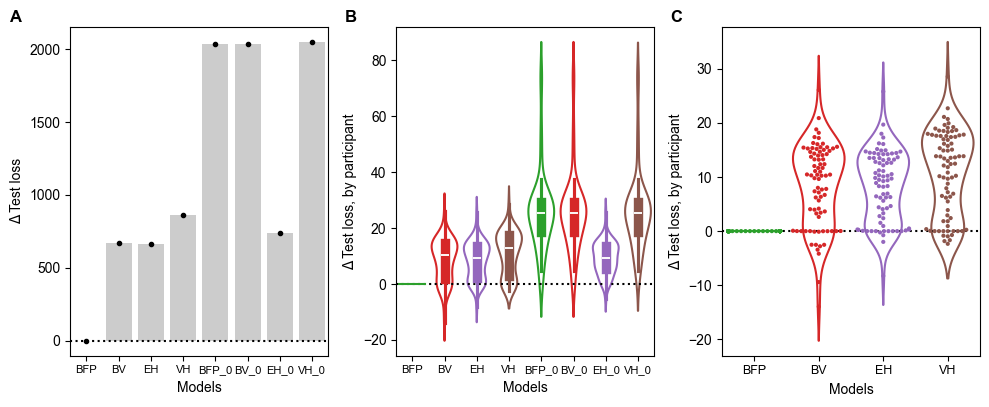

In [70]:
model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
model_names_full = ["BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]

colors = {"BFP":"C2","BV":"C3", "EH":"C4","VH":"C5","BFP_0":"C2","BV_0":"C3", "EH_0":"C4","VH_0":"C5"}
fig,ax = plt.subplots(1,3,figsize=(10,4))

# Experiment 4
# 1) Load CV results
filename = "exp4_cv_testlosses"
with open(os.path.join(fits_path,filename) + '.pickle', 'rb') as handle:
    b = pickle.load(handle)
    crossentropy_cv_test = b["crossentropy_cv_test"]
    model_fullnames = b["model_fullnames"]
# 2) Average over folds for each subject, then sum over subjects.
crossentropy_cv_bysubj = np.nanmean(crossentropy_cv_test, axis=2)
crossentropy_cv = np.nansum(crossentropy_cv_bysubj, axis=0)
crossentropy_cv_sem = np.nanstd(crossentropy_cv_bysubj, ddof=1, axis=0) / np.sqrt(n_subj) # Errorbars are subject SEM
# 3) Paired t-test
for model_idx in range(1,len(model_fullnames)):
    result = scipy.stats.ttest_rel(crossentropy_cv_bysubj[:,0], crossentropy_cv_bysubj[:,model_idx], alternative="two-sided")
    print("Paired t-test, bayesian_postmean vs "+model_fullnames[model_idx]+": p={0}, 95% CI=[{1},{2}]".format(np.round(result.pvalue,5), np.round(result.confidence_interval()[0],5), np.round(result.confidence_interval()[1],5)))
# 4) Visualize
ax[0].bar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), color="k", alpha=0.2)
yerr = crossentropy_cv_sem
ax[0].errorbar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), yerr=yerr, fmt='k.')
ax[0].plot([-0.5,len(model_fullnames)-1+0.5],[0,0],"k:")
ax[0].set_xlim([-0.5,len(model_fullnames)-1+0.5])
#ax[0].set_ylabel("Δ Cross entropy on test dataset, fold-averaged")
ax[0].set_xlabel("Models")
ax[0].set_xticks(range(len(model_fullnames)))
ax[0].set_xticklabels(model_names_full, fontsize=8)
ax[0].tick_params(axis='x', labelrotation=0) 
ax[0].set_ylabel("Δ Test loss")


df = pd.DataFrame(crossentropy_cv_bysubj-crossentropy_cv_bysubj[:,0:1], columns=model_names_full)
ax[1].plot([-0.5,8.5],[0,0],"k:",alpha=1)
sns.violinplot(ax=ax[1], data=df, fill=False, palette=colors)
ax[1].tick_params(axis='x', labelrotation=0) 
ax[1].tick_params(axis='x', labelsize=8)
ax[1].set_ylabel("Δ Test loss, by participant")
ax[1].set_xlabel("Models")

ax[2].plot([-0.5,4.5],[0,0],"k:",alpha=1)
sns.swarmplot(ax=ax[2], data=df.iloc[:,0:4], s=3, palette=colors)
sns.violinplot(ax=ax[2], data=df.iloc[:,0:4], fill=False, inner=None, palette=colors)
ax[2].tick_params(axis='x', labelrotation=0) 
ax[2].tick_params(axis='x', labelsize=9)
ax[2].set_ylabel("Δ Test loss, by participant")
ax[2].set_xlabel("Models")


fig.text(0.015,0.975, "A", fontsize=12, weight="bold")
fig.text(0.35,0.975, "B", fontsize=12, weight="bold")
fig.text(0.675,0.975, "C", fontsize=12, weight="bold")

fig.tight_layout()
#plt.savefig(os.path.join(figpath,"exp4_modelcomp"), dpi=200)
plt.savefig(os.path.join(figpath,"Fig11.pdf"), format="pdf")
plt.show()

dict_keys(['true_gen_params', 'models_fakedata_probstay', 'mturk_IDs', 'data_dims', 'models_fakedata'])
humans
bayesian_postmean_offset
velocity_offset
exploitation_heuristic_offset
velocity_heuristic_offset


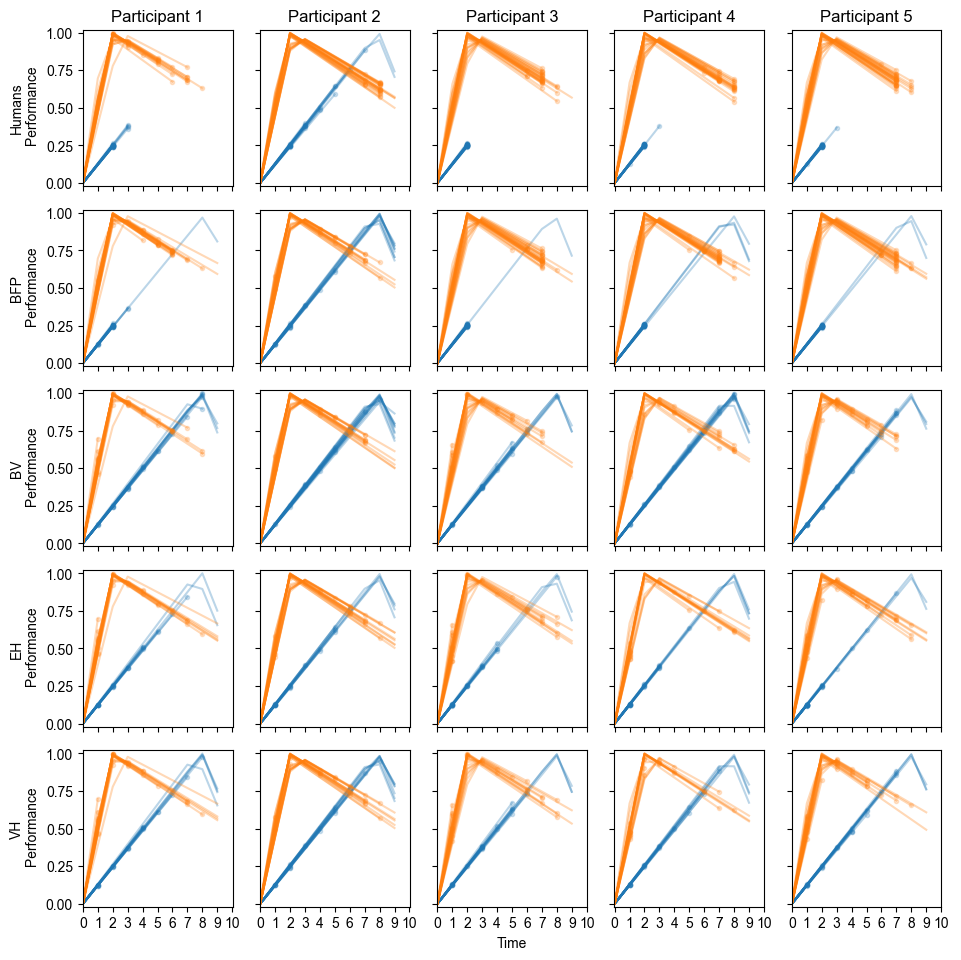

In [71]:
# Figure 10: visualize fake datasets

# Load the human dataset
filename = "exp4_data"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
data = b['data']

# Load the fake datasets for all models
filename = "exp4_fits_fakedata_allmodels"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
print(b.keys())  
models_true_gen_params = b['true_gen_params']
models_fakedata = b['models_fakedata']
models_fakedata["humans"] = data


# Visualization of trajectories seen.
n_rows=5
n_cols=5
fig, ax = plt.subplots(n_rows, n_cols,figsize=(10,10))
n_subj_visualized = 5
model_fullnames = ["humans", "bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset"]

model_names = ["Humans","BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]
row_count = -1
for model_fullname in model_fullnames:
    print(model_fullname)
    row_count = row_count+1
    
    include_offset_param_vals = "_offset" in model_fullname
    models = model_fullname.rpartition('_')[0]
    
    p_continuetillends_subjmean = np.zeros((n_conds, n_subj))
    fake_data = models_fakedata[model_fullname]
    for subj_idx, subj in enumerate(range(n_subj_visualized)):
        hasswitched_subj_conds = np.zeros((n_conds, n_runs))
        for cond in range(n_conds):
            traj_heights = fake_data[cond,subj,:,:,0]
            last_free_timestep = np.isnan(traj_heights).argmax(axis=1)-1
            for run in range(n_runs):
                ax[row_count, subj_idx%n_cols].plot(range(T_end), traj_heights[run,:], "-", color="C"+str(cond), alpha=0.3)
                ax[row_count, subj_idx%n_cols].plot(last_free_timestep[run], np.transpose(traj_heights[run, last_free_timestep[run]]), ".", color="C"+str(cond), alpha=0.2)


        ax[0, subj_idx%n_cols].set_title("Participant "+str(subj_idx+1))
        ax[row_count,0].set_ylabel(model_names[row_count]+"\n Performance")
        ax[row_count, subj_idx%n_cols].set_xticks(range(0,T_end+1))

        if(subj_idx%n_cols!=0):
            ax[row_count, subj_idx%n_cols].set_yticklabels([])
        if(subj_idx<n_cols*(n_rows-1)):
            ax[row_count, subj_idx%n_cols].set_xticklabels([])
        if(row_count==n_rows-1):
            ax[row_count, subj_idx%n_cols].set_xticklabels(range(0,T_end+1))
        ax[row_count, subj_idx%n_cols].set_ylim([-0.02,1.02])
        ax[row_count, subj_idx%n_cols].set_xlim([-0.02,10.02])

# add a big axis, hide frame
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Time")
fig.tight_layout()
#plt.savefig(os.path.join(figpath,"exp4_human_and_fakedata"), dpi=200)
plt.savefig(os.path.join(figpath,"Fig_exp4_indvdata.pdf"), format="pdf")
plt.show()

dict_keys(['true_gen_params', 'models_fakedata_probstay', 'mturk_IDs', 'data_dims', 'models_fakedata'])
humans
bayesian_postmean_nooffset
velocity_nooffset
exploitation_heuristic_nooffset
velocity_heuristic_nooffset


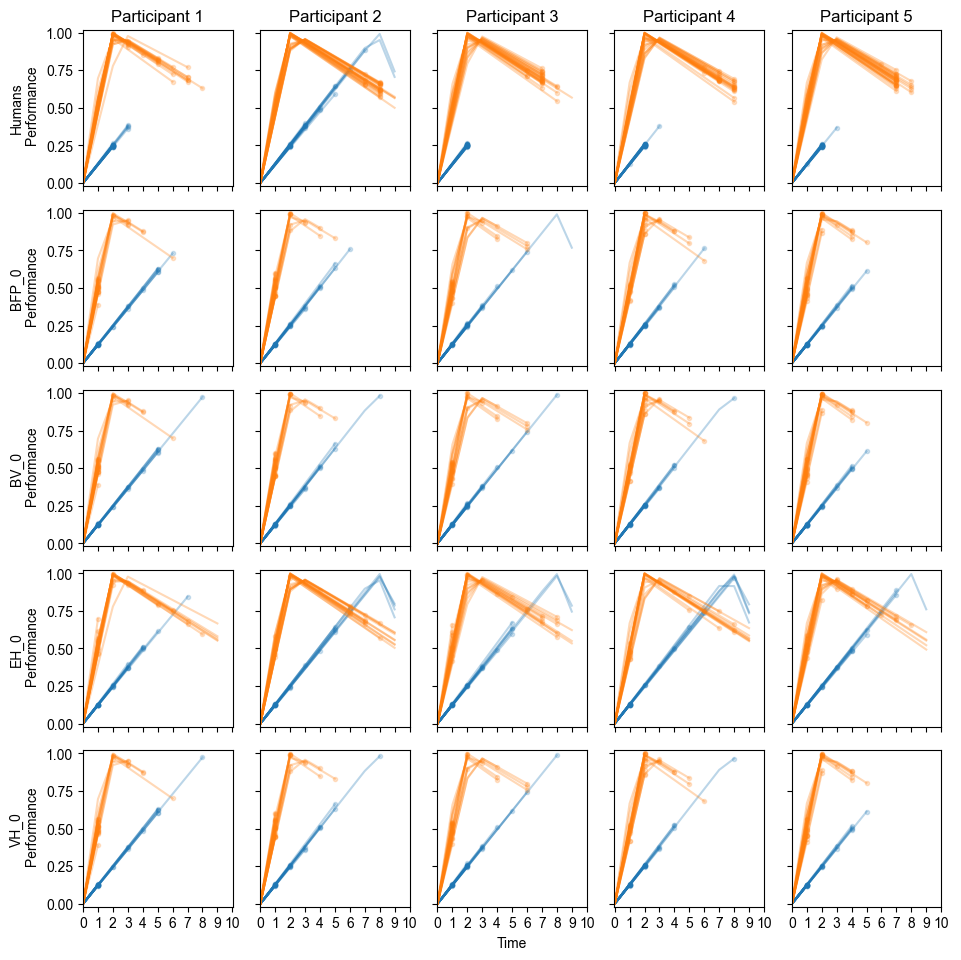

In [66]:
# Figure 10: visualize fake datasets

# Load the human dataset
filename = "exp4_data"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
data = b['data']

# Load the fake datasets for all models
filename = "exp4_fits_fakedata_allmodels"
with open(os.path.join(data_path, filename)+'.pickle', 'rb') as handle:
    b = pickle.load(handle)
print(b.keys())  
models_true_gen_params = b['true_gen_params']
models_fakedata = b['models_fakedata']
models_fakedata["humans"] = data


# Visualization of trajectories seen.
n_rows=5
n_cols=5
fig, ax = plt.subplots(n_rows, n_cols,figsize=(10,10))
n_subj_visualized = 5
model_fullnames = ["humans","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]

model_names = ["Humans","BFP_0","BV_0", "EH_0","VH_0"]
row_count = -1
for model_fullname in model_fullnames:
    print(model_fullname)
    row_count = row_count+1
    
    include_offset_param_vals = "_offset" in model_fullname
    models = model_fullname.rpartition('_')[0]
    
    p_continuetillends_subjmean = np.zeros((n_conds, n_subj))
    fake_data = models_fakedata[model_fullname]
    for subj_idx, subj in enumerate(range(n_subj_visualized)):
        hasswitched_subj_conds = np.zeros((n_conds, n_runs))
        for cond in range(n_conds):
            traj_heights = fake_data[cond,subj,:,:,0]
            last_free_timestep = np.isnan(traj_heights).argmax(axis=1)-1
            for run in range(n_runs):
                ax[row_count, subj_idx%n_cols].plot(range(T_end), traj_heights[run,:], "-", color="C"+str(cond), alpha=0.3)
                ax[row_count, subj_idx%n_cols].plot(last_free_timestep[run], np.transpose(traj_heights[run, last_free_timestep[run]]), ".", color="C"+str(cond), alpha=0.2)


        ax[0, subj_idx%n_cols].set_title("Participant "+str(subj_idx+1))
        ax[row_count,0].set_ylabel(model_names[row_count]+"\n Performance")
        ax[row_count, subj_idx%n_cols].set_xticks(range(0,T_end+1))

        if(subj_idx%n_cols!=0):
            ax[row_count, subj_idx%n_cols].set_yticklabels([])
        if(subj_idx<n_cols*(n_rows-1)):
            ax[row_count, subj_idx%n_cols].set_xticklabels([])
        if(row_count==n_rows-1):
            ax[row_count, subj_idx%n_cols].set_xticklabels(range(0,T_end+1))
        ax[row_count, subj_idx%n_cols].set_ylim([-0.02,1.02])
        ax[row_count, subj_idx%n_cols].set_xlim([-0.02,10.02])

# add a big axis, hide frame
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Time")
fig.tight_layout()
#plt.savefig(os.path.join(figpath,"exp4_human_and_fakedata"), dpi=200)
plt.savefig(os.path.join(figpath,"Fig_exp4_indvdata_2.pdf"), format="pdf")
plt.show()

# Model comparison and recovery, all experiments

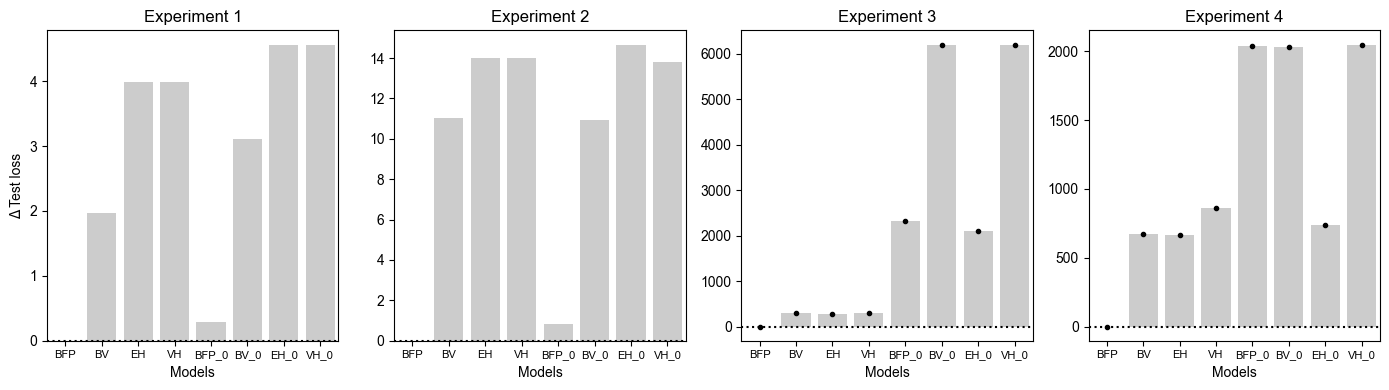

In [24]:
n_folds = 5
model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
# model_names_full = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic","Bayesian final height 0","Bayesian velocity 0", "Exploitation heuristic 0","Velocity heuristic 0"]
model_names_full = ["BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]

# fig,ax = plt.subplots(1,3,figsize=(10,5.5/12*10))
fig,ax = plt.subplots(1,4,figsize=(14,4))

# Experiment 1
filename = "exp1_fits_logistic_heuristics_cv"
with open(os.path.join(fits_path,filename+'.pickle'), 'rb') as handle:
    b = pickle.load(handle)
crossentropy_testloss = b["crossentropy_testloss"]
# 2) Average over folds for each subject, then sum over subjects.
crossentropy_cv = np.mean(crossentropy_testloss,axis=1)
crossentropy_cv_sem = np.nanstd(crossentropy_testloss-np.min(crossentropy_testloss,axis=0)[None,:], ddof=1, axis=1) / np.sqrt(n_folds) # Errorbars are SEM over 
# 3) Visualize
ax[0].bar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), color="k", alpha=0.2)
yerr = crossentropy_cv_sem
ax[0].plot([-0.5,len(model_fullnames)-1+0.5],[0,0],"k:")
ax[0].set_xlim([-0.5,len(model_fullnames)-1+0.5])
# ax[0].set_ylabel("Δ Cross entropy on test dataset, fold-averaged")
ax[0].set_ylabel("Δ Test loss")
ax[0].set_xlabel("Models")
ax[0].set_xticks(range(len(model_fullnames)))
ax[0].set_xticklabels(model_names_full, fontsize=8)
ax[0].tick_params(axis='x', labelrotation=0) 
ax[0].set_title("Experiment 1")





# Experiment 2
print()
filename = "exp2_fits_logistic_heuristics_cv"
with open(os.path.join(fits_path,filename+'.pickle'), 'rb') as handle:
    b = pickle.load(handle)
crossentropy_testloss = b["crossentropy_testloss"]
# 2) Average over folds for each subject, then sum over subjects.
crossentropy_cv = np.mean(crossentropy_testloss,axis=1)
crossentropy_cv_sem = np.nanstd(crossentropy_testloss-np.min(crossentropy_testloss,axis=0)[None,:], ddof=1, axis=1) / np.sqrt(n_folds) # Errorbars are SEM over 
# 3) Visualize
ax[1].bar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), color="k", alpha=0.2)
yerr = crossentropy_cv_sem
ax[1].plot([-0.5,len(model_fullnames)-1+0.5],[0,0],"k:")
ax[1].set_xlim([-0.5,len(model_fullnames)-1+0.5])
ax[1].set_xlabel("Models")
ax[1].set_xticks(range(len(model_fullnames)))
ax[1].set_xticklabels(model_names_full, fontsize=8)
ax[1].set_title("Experiment 2")
ax[1].tick_params(axis='x', labelrotation=0) 




# Experiment 3
print()
# 1) Load CV results
filename = "exp3_cv_testlosses"
with open(os.path.join(fits_path,filename) + '.pickle', 'rb') as handle:
    b = pickle.load(handle)
    crossentropy_cv_test = b["crossentropy_cv_test"]
    model_fullnames = b["model_fullnames"]
# 2) Average over folds for each subject, then sum over subjects.
crossentropy_cv_bysubj = np.nanmean(crossentropy_cv_test, axis=2)
crossentropy_cv = np.nansum(crossentropy_cv_bysubj, axis=0)
crossentropy_cv_sem = np.nanstd(crossentropy_cv_bysubj, ddof=1, axis=0) / np.sqrt(n_subj) # Errorbars are subject SEM
# 3) Visualize
ax[2].bar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), color="k", alpha=0.2)
yerr = crossentropy_cv_sem
ax[2].errorbar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), yerr=yerr, fmt='k.')
ax[2].plot([-0.5,len(model_fullnames)-1+0.5],[0,0],"k:")
ax[2].set_xlim([-0.5,len(model_fullnames)-1+0.5])
#ax[2].set_ylabel("Δ Cross entropy on test dataset, fold-averaged")
ax[2].set_xlabel("Models")
ax[2].set_xticks(range(len(model_fullnames)))
ax[2].set_xticklabels(model_names_full, fontsize=8)
ax[2].tick_params(axis='x', labelrotation=0) 
ax[2].set_title("Experiment 3")
#ax.set_title(str(n_folds)+"-fold cross validation: test loss")


# Experiment 4
print()
# 1) Load CV results
filename = "exp4_cv_testlosses"
with open(os.path.join(fits_path,filename) + '.pickle', 'rb') as handle:
    b = pickle.load(handle)
    crossentropy_cv_test = b["crossentropy_cv_test"]
    model_fullnames = b["model_fullnames"]
# 2) Average over folds for each subject, then sum over subjects.
crossentropy_cv_bysubj = np.nanmean(crossentropy_cv_test, axis=2)
crossentropy_cv = np.nansum(crossentropy_cv_bysubj, axis=0)
crossentropy_cv_sem = np.nanstd(crossentropy_cv_bysubj, ddof=1, axis=0) / np.sqrt(n_subj) # Errorbars are subject SEM
# 3) Visualize
ax[3].bar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), color="k", alpha=0.2)
yerr = crossentropy_cv_sem
ax[3].errorbar(range(len(model_fullnames)), crossentropy_cv-np.min(crossentropy_cv), yerr=yerr, fmt='k.')
ax[3].plot([-0.5,len(model_fullnames)-1+0.5],[0,0],"k:")
ax[3].set_xlim([-0.5,len(model_fullnames)-1+0.5])
#ax[2].set_ylabel("Δ Cross entropy on test dataset, fold-averaged")
ax[3].set_xlabel("Models")
ax[3].set_xticks(range(len(model_fullnames)))
ax[3].set_xticklabels(model_names_full, fontsize=8)
ax[3].tick_params(axis='x', labelrotation=0) 
ax[3].set_title("Experiment 4")
#ax.set_title(str(n_folds)+"-fold cross validation: test loss")

fig.tight_layout()
plt.savefig(os.path.join(figpath,"allexps_modelcomp.pdf"), format="pdf")
plt.show()

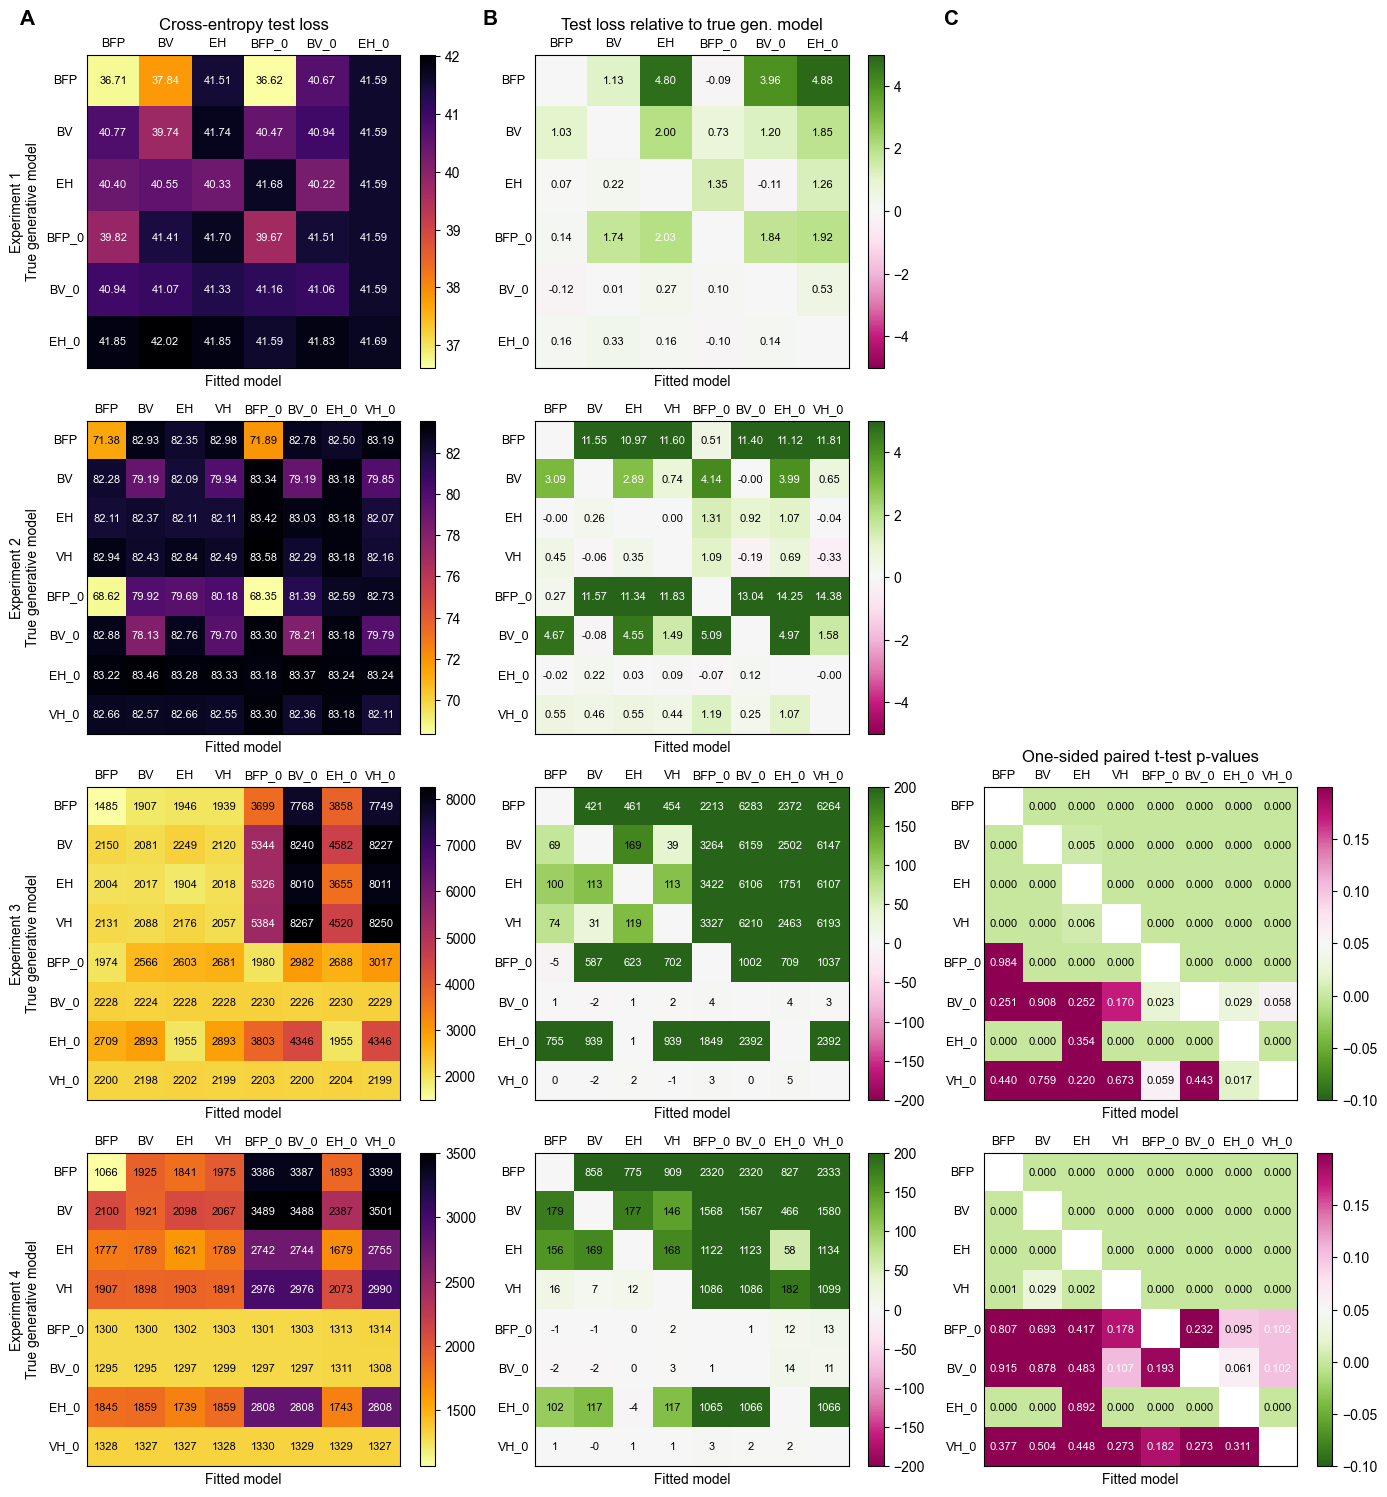

In [25]:
import matplotlib.colors as mcolors
model_fullnames = ["bayesian_postmean_offset","velocity_offset", "exploitation_heuristic_offset","velocity_heuristic_offset","bayesian_postmean_nooffset","velocity_nooffset", "exploitation_heuristic_nooffset","velocity_heuristic_nooffset"]
#model_names_full = ["Bayesian final height","Bayesian velocity", "Exploitation heuristic","Velocity heuristic","Bayesian final height 0","Bayesian velocity 0", "Exploitation heuristic 0","Velocity heuristic 0"]
model_names_full = ["BFP","BV", "EH","VH","BFP_0","BV_0", "EH_0","VH_0"]


mosaic = [['A', 'B', '.'], ['C', 'D', '.'], ['E','F','G'], ['H','I','J']] #'.' is an empty space
fig, ax = plt.subplot_mosaic(mosaic, figsize=(14,15))

plot_idx_raw = -2
for exp_idx, experiment in enumerate(["exp1","exp2"]):
    plot_idx_raw = plot_idx_raw+2
    plot_idx = chr(plot_idx_raw + 65)
    plot_idx_next = chr(plot_idx_raw + 66)
    
    filename = experiment+"_fits_logistic_heuristics_cv_modelrecov"
    with open(os.path.join(fits_path,filename+'.pickle'), 'rb') as handle:
        a = pickle.load(handle)
    crossentropy_testloss_modelrecov = a["crossentropy_testloss"]
            
    if(experiment=="exp1"):
        crossentropy_testloss_modelrecov = np.delete(crossentropy_testloss_modelrecov, [3,7], axis=1)
        crossentropy_testloss_modelrecov = np.delete(crossentropy_testloss_modelrecov, [3,7], axis=0)
        model_names_full_temp = np.array(model_names_full)[[0,1,2,4,5,6]]
    else:
        model_names_full_temp = np.array(model_names_full)
    n_models = crossentropy_testloss_modelrecov.shape[0]
    
    crossentropy_testlossmean_modelrecov = np.mean(crossentropy_testloss_modelrecov,axis=2)
    crossentropy_testlossmeandiff_modelrecov = np.zeros(crossentropy_testlossmean_modelrecov.shape)
    for dataset_idx in range(n_models):
        crossentropy_testlossmeandiff_modelrecov[dataset_idx,:] = crossentropy_testlossmean_modelrecov[dataset_idx,:] - crossentropy_testlossmean_modelrecov[dataset_idx,dataset_idx] 
    # # 4) Visualize
    # Define a custom colormap centered at 0.05, with "PiYG" color scheme
    losses_cmap = plt.get_cmap("inferno_r")
    diffs_norm = mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
    diffs_cmap = plt.get_cmap("PiYG")
    # Plot first matrix
    cax0 = ax[plot_idx].matshow(crossentropy_testlossmean_modelrecov, cmap=losses_cmap)
    cax1 = ax[plot_idx_next].matshow(crossentropy_testlossmeandiff_modelrecov, cmap=diffs_cmap, norm=diffs_norm)

    # Overlay text for each square with values rounded to the third decimal
    for i in range(n_models):
        for j in range(n_models):
            if(crossentropy_testlossmean_modelrecov[i,j]<37*(exp_idx+1)):
                loss_color = "black"
            else: 
                loss_color="white"
            if(crossentropy_testlossmeandiff_modelrecov[i,j]<2):
                lossdiff_color = "black"
            else: 
                lossdiff_color="white"
            ax[plot_idx].text(j, i, f"{crossentropy_testlossmean_modelrecov[i, j]:.2f}", 
               ha="center", va="center", color=loss_color, fontsize=8)
            if(i!=j):
                ax[plot_idx_next].text(j, i, f"{crossentropy_testlossmeandiff_modelrecov[i, j]:.2f}", 
                           ha="center", va="center", color=lossdiff_color, fontsize=8)
    # Shared colorbar
    fig.colorbar(cax0, ax=ax[plot_idx], orientation='vertical', fraction=0.045, pad=0.05)
    fig.colorbar(cax1, ax=ax[plot_idx_next], orientation='vertical', fraction=0.045, pad=0.05)
    for a in [ax[plot_idx],ax[plot_idx_next]]:
#         a.set_ylabel("True generative model")
        a.set_xlabel("Fitted model")
        a.set_xticks(range(len(model_names_full_temp)))
        a.set_yticks(range(len(model_names_full_temp)))
        a.tick_params('both', pad=7, length=1, width=0, which='major')
        a.tick_params('y', pad=15, length=1, width=0, which='major')
        a.set_xticklabels(model_names_full_temp, rotation=0, ha="center", va="center", fontsize=9)
        a.set_yticklabels(model_names_full_temp, rotation=0, ha="center", va="center", fontsize=9)
    ax[plot_idx].set_ylabel("Experiment "+str(exp_idx+1)+"\nTrue generative model")
        
        
plot_idx_raw = 1
for exp_idx, experiment in enumerate(["exp3","exp4"]):
    plot_idx_raw = plot_idx_raw+3
    plot_idx = chr(plot_idx_raw + 65)
    plot_idx_next = chr(plot_idx_raw + 66)
    plot_idx_next2 = chr(plot_idx_raw + 67)
    
        ## Figure 9 Model recovery
    filename = experiment+"_cv_modelrecov_testlosses"
    with open(os.path.join(fits_path,filename) + '.pickle', 'rb') as handle:
        b = pickle.load(handle)
        crossentropy_cv_test = b["crossentropy_cv_test"]
        model_fullnames = b["model_fullnames"]
    # 2) Average over folds for each subject, then sum over subjects.
    crossentropy_cv_bysubj = np.nanmean(crossentropy_cv_test, axis=3)
    crossentropy_cv = np.nansum(crossentropy_cv_bysubj, axis=0)
    crossentropy_cv_diffs = crossentropy_cv.copy()
    for fakedataset_idx in range(len(model_fullnames)):
        crossentropy_cv_diffs[fakedataset_idx,:] = crossentropy_cv_diffs[fakedataset_idx,:] - crossentropy_cv_diffs[fakedataset_idx,fakedataset_idx] 
    # 3) Paired t-test and Wilcoxon test
    cv_modelrecov_pairedt_tvalues = np.zeros((len(model_fullnames),len(model_fullnames)))
    cv_modelrecov_pairedt_tvalues[:] = np.nan
    cv_modelrecov_pairedt_pvalues = np.zeros((len(model_fullnames),len(model_fullnames)))
    cv_modelrecov_pairedt_pvalues[:] = np.nan
    cv_modelrecov_wilcoxon_pvalues = np.zeros((len(model_fullnames),len(model_fullnames)))
    cv_modelrecov_wilcoxon_pvalues[:] = np.nan
    for fakedataset_idx in range(len(model_fullnames)):
        for model_idx in range(len(model_fullnames)):
            if(fakedataset_idx==model_idx):
                continue;
            if(np.mean(np.isnan(crossentropy_cv_bysubj[:,fakedataset_idx,fakedataset_idx]))>0):
                # Model fit not yet completed
                continue;
            # Note: t-tests and wilcoxon signed-rank tests here are one-sided!
            t_stat, p_value = scipy.stats.ttest_rel(crossentropy_cv_bysubj[:,fakedataset_idx,fakedataset_idx], crossentropy_cv_bysubj[:,fakedataset_idx,model_idx], alternative="less")
            cv_modelrecov_pairedt_tvalues[fakedataset_idx,model_idx] = t_stat
            cv_modelrecov_pairedt_pvalues[fakedataset_idx,model_idx] = p_value
            #print("Paired t-test, true "+model_fullnames[fakedataset_idx]+" vs "+model_fullnames[model_idx]+": p={0}".format(p_value))
            t_stat, p_value = scipy.stats.wilcoxon(crossentropy_cv_bysubj[:,fakedataset_idx,fakedataset_idx], crossentropy_cv_bysubj[:,fakedataset_idx,model_idx], alternative="less")
            cv_modelrecov_wilcoxon_pvalues[fakedataset_idx,model_idx] = p_value
            #print("Wilcoxon signed-rank test, true "+model_fullnames[fakedataset_idx]+" vs "+model_fullnames[model_idx]+": p={0}".format(p_value))

    #cv_modelrecov_pairedt_pvalues = cv_modelrecov_pairedt_pvalues*2 # One-sided to two-sided (but still retain direction)
    # # 4) Visualize
    # Define a custom colormap centered at 0.05, with "PiYG" color scheme
    losses_cmap = plt.get_cmap("inferno_r")
    diffs_norm = mcolors.TwoSlopeNorm(vmin=-200, vcenter=0, vmax=200)
    diffs_cmap = plt.get_cmap("PiYG")
    # Plot first matrix
    cax0 = ax[plot_idx].matshow(crossentropy_cv, cmap=losses_cmap)
    cax1 = ax[plot_idx_next].matshow(crossentropy_cv_diffs, cmap=diffs_cmap, norm=diffs_norm)

    pvalues_norm = mcolors.TwoSlopeNorm(vmin=-0.1, vcenter=0.05, vmax=0.2)
    pvalues_cmap = plt.get_cmap("PiYG_r")
    # Plot first matrix
    cax2 = ax[plot_idx_next2].matshow(cv_modelrecov_pairedt_pvalues, cmap=pvalues_cmap, norm=pvalues_norm)

    # Overlay text for each square with values rounded to the third decimal
    for i in range(len(model_fullnames)):
        for j in range(len(model_fullnames)):
            if(crossentropy_cv[i,j]<5000/(exp_idx+1)):
                loss_color = "black"
            else: 
                loss_color="white"
            if(crossentropy_cv_diffs[i,j]<200):
                lossdiff_color = "black"
            else: 
                lossdiff_color="white"
            if(cv_modelrecov_pairedt_pvalues[i,j]<0.1):
                pval_color = "black"
            else: 
                pval_color="white"
            ax[plot_idx].text(j, i, f"{crossentropy_cv[i, j]:.0f}", 
               ha="center", va="center", color=loss_color, fontsize=8)
            if(i!=j):
                ax[plot_idx_next].text(j, i, f"{crossentropy_cv_diffs[i, j]:.0f}", 
                           ha="center", va="center", color=lossdiff_color, fontsize=8)
            if(not np.isnan(cv_modelrecov_pairedt_pvalues[i, j])):
                ax[plot_idx_next2].text(j, i, f"{cv_modelrecov_pairedt_pvalues[i, j]:.3f}", 
                           ha="center", va="center", color=pval_color, fontsize=8)

    # Shared colorbar
    fig.colorbar(cax0, ax=ax[plot_idx], orientation='vertical', fraction=0.045, pad=0.05)
    fig.colorbar(cax1, ax=ax[plot_idx_next], orientation='vertical', fraction=0.045, pad=0.05)
    fig.colorbar(cax2, ax=ax[plot_idx_next2], orientation='vertical', fraction=0.045, pad=0.05)
    for a in [ax[plot_idx], ax[plot_idx_next], ax[plot_idx_next2]]:
        #a.set_ylabel("True generative model")
        #if(experiment=="exp4"):
        a.set_xlabel("Fitted model")
        a.set_xticks(range(len(model_fullnames)))
        a.set_yticks(range(len(model_fullnames)))
        a.tick_params('both', pad=7, length=1, width=0, which='major')
        a.tick_params('y', pad=15, length=1, width=0, which='major')
        a.set_xticklabels(model_names_full, rotation=0, ha="center", va="center", fontsize=9)
        a.set_yticklabels(model_names_full, rotation=0, ha="center", va="center", fontsize=9)
    ax[plot_idx].set_ylabel("Experiment "+str(exp_idx+3)+"\nTrue generative model")

# Titles for subplots
ax["A"].set_title("Cross-entropy test loss")
ax["B"].set_title("Test loss relative to true gen. model")
ax["G"].set_title("One-sided paired t-test p-values")

fig.text(0.02,0.985, "A", fontsize=15, weight="bold")
fig.text(0.35,0.985, "B", fontsize=15, weight="bold")
fig.text(0.68,0.985, "C", fontsize=15, weight="bold")
    
    # Display the plot
fig.tight_layout()
#plt.savefig(os.path.join(figpath,"allexps_modelrecov"), dpi=200)
plt.savefig(os.path.join(figpath,"allexps_modelrecov.pdf"), format="pdf")
plt.show()